In [1]:
import pandas as pd
import numpy as np
import re

#!pip install matplotlib
import matplotlib.pyplot as plt
#!pip install scikit-learn
from sklearn.linear_model import LinearRegression

import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
PATH = r"C://Users/zrj-desktop/Dropbox/CAS/CAS Hackathon 2025/data/"

In [3]:
%%markdown
## Data Preparation

## Data Preparation


In [4]:
%%markdown
### Load Primary Data

### Load Primary Data


In [5]:
primary = pd.read_csv(PATH+"Hackathon Primary Spreadsheet.csv", encoding="cp1252")
primary.shape
#primary.tail(3)

(40351, 16)

In [6]:
%%markdown
### Create Member, Speaker

### Create Member, Speaker


In [7]:
primary.registrant_type_code.dtype

dtype('O')

In [8]:
#primary.registrant_type_code.value_counts(normalize=False)

In [9]:
#member_map = pd.read_csv(PATH+"registrant_type_code_mapping.csv")
#member_map["registrant_type_code"] = member_map["registrant_type_code"].str.strip()

In [10]:
def clean_member(col):
    text = str(col).lower() 

    if re.search(r'non|not', text):  
        return 'Other'
    elif re.search(r'iaa', text):
        return 'Other'
    elif re.search(r'acad', text):
        return 'Other'
    elif re.search(r'affilia', text):
        return 'Member'
    elif re.search(r'ember|embr|mem|fcas', text):
        return 'Member'
    else:
        return 'Other'

primary['Member'] = primary['registrant_type_code'].map(clean_member)
    

In [11]:
#primary[['registrant_type_code','Member']].drop_duplicates()

In [12]:
#primary = primary.merge(member_map, how='left', on='registrant_type_code')

In [13]:
#primary.tail(10)

In [14]:
def clean_speaker(col):
    text = str(col).lower() 

    if re.search(r'peak', text):   
        return 'Speaker'
    else:
        return 'Other'

primary['Speaker'] = primary['registrant_type_code'].map(clean_speaker)
    

In [15]:
primary[['registrant_type_code','Speaker']].drop_duplicates()

,registrant_type_code,Speaker
0,Member,Other
4,Member Speaker,Speaker
6,Member Government,Other
42,Subscriber,Other
45,Candidate,Other
46,Non-Member,Other
71,Non-Member Speaker,Speaker
90,Non-Member Government,Other
133,Academic Correspondent,Other
148,Press,Other


In [16]:
primary_1 = primary[['Customer_ID','Event_Title','Event_Code','Start_Date','Delivery','Location_City','Location_State','State','Country','Member','Speaker']].drop_duplicates()
#primary_1.tail(3)

In [17]:
primary_1.shape

(38454, 11)

In [18]:
#secondary = pd.read_csv(PATH+"Hackathon Secondary Data.csv", encoding="cp1252")
#secondary = secondary[['Customer_Number','Meeting','Begin_Date','Meeting_Registration_Type']].drop_duplicates()

In [19]:
#secondary['year'] = secondary['Begin_Date'].str.extract(r'(\d{4})').astype(int)

In [20]:
# def get_meeting(meeting):
#     text = str(meeting).lower() 

#     if re.search(r'boot|csaf', text):   
#         return 'Other'
#     elif re.search(r'clrs', text):
#         return 'CLRS'
#     elif re.search(r'annu', text):
#         return 'Annual Meeting'
#     elif re.search(r'spri', text):
#         return 'Spring Meeting'
#     elif re.search(r'rpm|rate', text):
#         return 'RPM'   
#     elif re.search(r'rein', text):
#         return 'Reins Seminar'
#     else:
#         return 'Other'

# secondary['Event_desc'] = secondary['Meeting'].map(get_meeting)

In [21]:
#chk.to_csv('chk_meeting_mapping.csv',index=False)
#chk = secondary[['Meeting','Event_desc']].drop_duplicates()

In [22]:
#secondary[['Customer_Number','year','Event_desc']].drop_duplicates()

In [23]:
# def get_details(meeting):
    
#     text = str(meeting).lower() 

#     if re.search(r'table', text):   
#         return 'Roundtable'
#     elif re.search(r'studen', text):
#         return 'Student Program'
#     elif re.search(r'virtual', text) and re.search(r'group', text):
#         return 'Virtual (Group)'
#     elif re.search(r'virtual', text) and (not re.search(r'group', text)):
#         return 'Virtual'
#     elif re.search(r'stream', text) and re.search(r'group', text):
#         return 'Livestream (Group)'
#     elif re.search(r'stream', text) and (not re.search(r'group', text)):
#         return 'Livestream'
#     elif re.search(r'story', text):
#         return 'Business Storytelling'
#     elif re.search(r'novation', text):
#         return 'Innovation Council Workshop'
#     elif re.search(r'boot|csaf', text):   
#         return 'Exclude'
#     else:
#         return 'Traditional'
  

# secondary['Event_details'] = secondary['Meeting'].map(get_details)

In [24]:
#secondary.columns
#secondary.to_csv("chk_event_mapping.csv", index=False)

In [25]:
%%markdown
### Fix Event Start Date

### Fix Event Start Date


In [26]:
primary_2 = primary_1

In [27]:
primary_2.Start_Date.dtype

dtype('O')

In [28]:
primary_2['Start_Date'].tail(3)

40348    2024/05/06
40349    2024/05/06
40350    2024/03/17
Name: Start_Date, dtype: object

In [29]:
# Extract year, month and day
primary_2[['y1', 'm1', 'd1', 'm2', 'd2', 'y2']] = primary_2['Start_Date'].str.extract(
    r'(?:(\d{4})[/-](\d{1,2})[/-](\d{1,2})|(\d{1,2})[/-](\d{1,2})[/-](\d{4}))'
)

In [30]:
# Combine year, month, day 
primary_2['year'] = primary_2['y1'].combine_first(primary_2['y2'])
primary_1['month'] = primary_2['m1'].combine_first(primary_2['m2'])
primary_2['day'] = primary_2['d1'].combine_first(primary_2['d2'])

primary_2 = primary_2.drop(columns=['y1', 'm1', 'd1', 'm2', 'd2', 'y2'])

In [31]:
# Create Event_Data based on the Start_Date 
primary_2[['year', 'month', 'day']] = primary_2[['year', 'month', 'day']].astype(int)
primary_2['Event_date'] = pd.to_datetime(primary_2[['year', 'month', 'day']])

In [32]:
# Spot check
#primary_2.drop_duplicates(keep='last')

In [33]:
#primary_2.tail(3)

In [34]:
%%markdown
### Create Season, Quarter

### Create Season, Quarter


In [35]:
primary_3 = primary_2

In [36]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

primary_3['Event_season'] = primary_3['month'].map(get_season)

In [37]:
#primary_3.tail(3)

In [38]:
%%markdown
### Load Secondary Data

### Load Secondary Data


In [39]:
secondary = pd.read_csv(PATH+"Hackathon Secondary Data.csv", encoding="cp1252")
#secondary.tail(3)

In [40]:
%%markdown
### Create Event Year

### Create Event Year


In [41]:
# Extract year, month and day 
secondary['Event_Year'] = secondary['Begin_Date'].str.extract(r'(\d{4})').astype(int)
#secondary['year'] = secondary['Event_Year'].astype(int)


In [42]:
%%markdown
### Create Age Group

### Create Age Group


In [43]:
#secondary[secondary['Birth_Year'].isna()].year.unique()

In [44]:
secondary['Age'] = secondary['Event_Year'] - secondary['Birth_Year']

In [45]:
secondary.Age.isna().sum()

np.int64(2660)

In [46]:
#secondary[['Customer_Number','Event_Year','Age']].drop_duplicates()

In [47]:
# full age data for all Customer
secondary['base_year'] = secondary['Event_Year'] - secondary['Age'] + 1

all_rows = []
for id_val, base_year in secondary[['Customer_Number', 'base_year']].drop_duplicates().values:
    ages = range(1, 101)  # 1 to 100
    years = [base_year + (age - 1) for age in ages]
    all_rows.extend([(id_val, y, a) for y, a in zip(years, ages)])

secondary_age = pd.DataFrame(all_rows, columns=['Customer_Number', 'Event_Year', 'Age'])

In [48]:
#secondary_age

In [49]:
# def get_age_group(age):
#     if age <= 25:
#         return '1. <=25'
#     elif age <= 40:
#         return '2. 26-40'
#     elif age <= 55:
#         return '3. 41-55'
#     elif age <= 70:
#         return '4. 56-70'
#     elif age > 70:
#         return '5. >70'     
#     else:
#         return 'Unknown'

# secondary['Age_group'] = secondary['Age'].map(get_age_group)

In [50]:
# secondary['Age_group'].value_counts()

In [51]:
%%markdown
### Clean Gender

### Clean Gender


In [52]:
def get_gender(gender):
    if gender == 'Man':
        return '1. Male'
    elif gender == 'Woman':
        return '2. Female'   
    elif gender == 'Non-Binary/Third Gender':
        return '3. Non-binary'
    elif gender == 'Not Listed':
        return '3. Non-binary'
    elif gender == 'I prefer not to answer':
        return '4. Prefer not to answer'
    else:
        return '5. Unknown'

secondary['gender_1'] = secondary['Gender'].map(get_gender)

In [53]:
secondary.gender_1.value_counts()

gender_1
1. Male                    20625
2. Female                  10648
5. Unknown                  6624
4. Prefer not to answer     3182
3. Non-binary                 30
Name: count, dtype: int64

In [54]:
secondary.Gender.value_counts()

Gender
Man                        20625
Woman                      10648
I prefer not to answer      3182
Not Listed                    16
Non-Binary/Third Gender       14
Name: count, dtype: int64

In [55]:
secondary_gender = secondary[['Customer_Number','gender_1']].drop_duplicates()

In [56]:
%%markdown
### Map Country to Continent

### Map Country to Continent


In [57]:
def assign_continent(country):
    north_america = [
        'United States', 'Canada', 'Bermuda', 'Cayman Islands (British Overseas Territory)',
        'Mexico', 'Trinidad and Tobago', 'Haiti', 'Barbados',
        'Saint Vincent and the Grenadines', 'Bahamas (The)'
    ]
    
    south_america = [
        'Peru', 'Brazil', 'Colombia', 'Argentina', 'Ecuador'
    ]
    
    europe = [
        'Netherlands', 'United Kingdom', 'Germany', 'Switzerland', 'Denmark', 'Ireland', 
        'France', 'Spain', 'Czechia', 'Italy', 'Greece', 'Belgium', 'Andorra', 'Luxembourg'
    ]
    
    asia = [
        'China (Hong Kong)', 'China', 'Japan', 'Israel', 'India', 'Singapore', 
        'United Arab Emirates', 'Malaysia', 'Philippines', 'Thailand', 'Taiwan',
        'South Korea', 'China (Macau)', 'Saudi Arabia', 'Nepal', 'Lebanon', 'Indonesia'
    ]
    
    africa = [
        'Nigeria', 'Kenya', 'South Africa', 'Ethiopia', 'Togo', 'Ghana', 
        'Senegal', 'Mauritius'
    ]
    
    oceania = [
        'Australia', 'New Zealand'
    ]

    if country in north_america:
        return 'North America'
    elif country in south_america:
        return 'South America'
    elif country in europe:
        return 'Europe and Africa'
    elif country in asia:
        return 'Asia and Oceania'
    elif country in africa:
        return 'Europe and Africa'
    elif country in oceania:
        return 'Asia and Oceania'
    else:
        return 'Unknown'

In [58]:
secondary['Home_Continent'] = secondary['Home_Country'].apply(assign_continent)
#secondary.tail(3)

In [59]:
%%markdown
### Create Membership

### Create Membership


In [60]:
def assign_membership(row):
    if row['FCAS'] == 'Yes':
        return 'FCAS'
    elif row['ACAS'] == 'Yes':
        return 'ACAS'
    else:
        return 'Unknown'

secondary['Membership'] = secondary.apply(assign_membership, axis=1)

In [61]:
secondary.Membership.value_counts()

Membership
FCAS       25245
Unknown     8217
ACAS        7647
Name: count, dtype: int64

In [62]:
#secondary[secondary.Customer_Number=='000000290I'].tail(5)

In [63]:
#secondary[secondary.Customer_Number=='000038191I']

In [64]:
df = secondary[['Customer_Number','Event_Year','Membership']].drop_duplicates()

In [65]:
# Find min/max year 
year_bounds = df.groupby('Customer_Number')['Event_Year'].agg(['min', 'max']).reset_index()
#year_bounds.head(5)

###### extend year range


In [66]:
all_years = []
for _, row in year_bounds.iterrows():
    all_years.extend([(row['Customer_Number'], y) for y in range(row['min'], row['max'] + 1)])
all_years_df = pd.DataFrame(all_years, columns=['Customer_Number', 'Event_Year'])

#all_years_df[all_years_df.Customer_Number=='000000244I']

In [67]:
# merge with original
merged = pd.merge(all_years_df, secondary[['Customer_Number', 'Event_Year', 'Membership']], on=['Customer_Number', 'Event_Year'], how='left')
#merged[merged.Customer_Number=='000000244I']

In [68]:
df = secondary[['Customer_Number', 'Event_Year', 'Membership']]
# first and last status for each ID 
status_bounds = (
    df.sort_values(['Customer_Number', 'Event_Year'])
      .groupby('Customer_Number')
      .agg(first_status=('Membership', 'first'),
           last_status=('Membership', 'last'))
      .reset_index()
)
# status bounds
merged = pd.merge(merged, status_bounds, on='Customer_Number', how='left')

#merged[merged.Customer_Number=='000000244I']

In [69]:
# to fill 
def fill_status(row):
    if pd.isna(row['Membership']) and row['first_status'] == row['last_status']:
        return row['first_status']
    return row['Membership']

merged['Membership'] = merged.apply(fill_status, axis=1)

In [70]:
merged = merged[['Customer_Number', 'Event_Year', 'Membership']].drop_duplicates()

In [71]:
#merged

In [72]:
merged = merged.sort_values(['Membership', 'Event_Year']).reset_index(drop=True)


In [73]:
#merged[merged.Customer_Number=='000038191I']
df = merged

In [74]:
# Fill in future years status if already FCAS

In [75]:
target_year = 2025

# latest year and status
latest_info = (
    df.sort_values(['Customer_Number', 'Event_Year'])
      .groupby('Customer_Number')
      .tail(1)[['Customer_Number', 'Event_Year', 'Membership']]
      .rename(columns={'Event_Year': 'latest_year', 'Membership': 'latest_status'})
)

# extend dataframe for FCAS 
rows_to_add = []
for _, row in latest_info.iterrows():
    if row['latest_status'] == 'FCAS' and row['latest_year'] < target_year:
        for y in range(row['latest_year'] + 1, target_year + 1):
            rows_to_add.append((row['Customer_Number'], y, 'FCAS'))

# union
df_extended = pd.concat([df, pd.DataFrame(rows_to_add, columns=['Customer_Number', 'Event_Year', 'Membership'])])
df_extended = df_extended.sort_values(['Customer_Number', 'Event_Year']).reset_index(drop=True)


In [76]:
secondary_membership = df_extended

In [77]:
%%markdown
### Create Career Stage

### Create Career Stage


In [78]:
def get_seniority(title):
    text = str(title).lower() 

    if re.search(r'rofessor|educat|phd|p.h.d|ph.d|lecturer|scholar|author|coordinator', text):
        return 'Academics'
    elif re.search(r'acas', text):
        return 'Junior Level'
    elif re.search(r'avp|vp|v. p|presiden|manag|manger|mgr|dir|ceo|cro|coo|cfo|cio|ciso|cto|cbo|cpgo|cuo|owner|appointed|chief|cheif|chair|deputy|xecutive|partn|found|head|lead|rincip|md|V\. P\. ', text):   #Ratemaking and Product Management
        return 'Senior Level'
    elif re.search(r'consultant', text) and not re.search(r'sr|senior|xecutive|actuary|manag|lead|snr', text):
        return 'Junior Level'
    elif re.search(r'student|associate|nalyst|ntern|assist|actuarial a|trainee', text) and not re.search(r'actuary', text):
        return 'Junior Level'
    else:
        return 'Mid-Level'
    

secondary['Seniority'] = secondary['Job_Title'].map(get_seniority)

In [79]:
#secondary.tail(2)

In [80]:
secondary[['Job_Title','Seniority']].drop_duplicates().to_csv(PATH+'\Check_title.csv', index=False)

In [81]:
# min/max year for each ID
year_bounds = df.groupby('Customer_Number')['Event_Year'].agg(['min', 'max']).reset_index()
#year_bounds.head(5)

In [82]:
# create year range 
all_years = []
for _, row in year_bounds.iterrows():
    all_years.extend([(row['Customer_Number'], y) for y in range(row['min'], row['max'] + 1)])
all_years_df = pd.DataFrame(all_years, columns=['Customer_Number', 'Event_Year'])

# all_years_df[all_years_df.Customer_Number=='000000244I']

In [83]:
# join with original
merged = pd.merge(all_years_df, secondary[['Customer_Number', 'Event_Year', 'Seniority']], on=['Customer_Number', 'Event_Year'], how='left')
#merged[merged.Customer_Number=='000000244I']

In [84]:
df = secondary[['Customer_Number', 'Event_Year', 'Seniority']]
# get first and last status 
status_bounds = (
    df.sort_values(['Customer_Number', 'Event_Year'])
      .groupby('Customer_Number')
      .agg(first_status=('Seniority', 'first'),
           last_status=('Seniority', 'last'))
      .reset_index()
)
# join status bounds
merged = pd.merge(merged, status_bounds, on='Customer_Number', how='left')

#merged[merged.Customer_Number=='000000244I']

In [85]:
def fill_status(row):
    if pd.isna(row['Seniority']) and row['first_status'] == row['last_status']:
        return row['first_status']
    return row['Seniority']

merged['Seniority'] = merged.apply(fill_status, axis=1)

In [86]:
merged = merged[['Customer_Number', 'Event_Year', 'Seniority']].drop_duplicates()

In [87]:
merged = merged.sort_values(['Seniority', 'Event_Year']).reset_index(drop=True)
#merged[merged.Customer_Number=='000000244I']

In [88]:
target_year = 2025
df = merged

# find latest year and status for each ID
latest_info = (
    df.sort_values(['Customer_Number', 'Event_Year'])
      .groupby('Customer_Number')
      .tail(1)[['Customer_Number', 'Event_Year', 'Seniority']]
      .rename(columns={'Event_Year': 'latest_year', 'Seniority': 'latest_status'})
)

# extend for FCAS IDs only
rows_to_add = []
for _, row in latest_info.iterrows():
    if row['latest_status'] == 'Senior Level' and row['latest_year'] < target_year:
        for y in range(row['latest_year'] + 1, target_year + 1):
            rows_to_add.append((row['Customer_Number'], y, 'Senior Level'))

df_extended = pd.concat([df, pd.DataFrame(rows_to_add, columns=['Customer_Number', 'Event_Year', 'Seniority'])])
df_extended = df_extended.sort_values(['Customer_Number', 'Event_Year']).reset_index(drop=True)

In [89]:
secondary_seniority = df_extended
#secondary_seniority[secondary_seniority.Customer_Number=='000000244I']

In [90]:
%%markdown
### Create Event details

### Create Event details


In [91]:
secondary_event_details = secondary[['Customer_Number','Meeting','Begin_Date','Meeting_Registration_Type']].drop_duplicates()

In [92]:
secondary_event_details['year'] = secondary_event_details['Begin_Date'].str.extract(r'(\d{4})').astype(int)

In [93]:
def get_meeting(meeting):
    text = str(meeting).lower() 

    if re.search(r'boot|csaf', text):  
        return 'Other'
    elif re.search(r'clrs', text):
        return 'CLRS'
    elif re.search(r'annu', text):
        return 'Annual Meeting'
    elif re.search(r'spri', text):
        return 'Spring Meeting'
    elif re.search(r'rpm|rate', text):
        return 'RPM'   
    elif re.search(r'rein', text):
        return 'Reins Seminar'
    else:
        return 'Other'


secondary_event_details['Event_desc'] = secondary_event_details['Meeting'].map(get_meeting)

In [94]:
def get_details(meeting):
    
    text = str(meeting).lower() 

    if re.search(r'table', text):   
        return 'Conventional (incl. Roundtable Discussions)'
    elif re.search(r'studen', text):
        return 'Student Program'
    elif re.search(r'virtual', text) and re.search(r'group', text):
        return 'Virtual (Group)'
    elif re.search(r'virtual', text) and (not re.search(r'group', text)):
        return 'Virtual'
    elif re.search(r'stream', text) and re.search(r'group', text):
        return 'Livestream (Group)'
    elif re.search(r'stream', text) and (not re.search(r'group', text)):
        return 'Livestream'
    elif re.search(r'story', text):
        return 'Conventional (incl. Business Storytelling)'
    elif re.search(r'novation', text):
        return 'Conventional (incl. Innovation Council Workshop)'
    elif re.search(r'boot|csaf', text):  
        return 'Exclude'
    else:
        return 'Conventional'
  

secondary_event_details['Event_details'] = secondary_event_details['Meeting'].map(get_details)

In [95]:
secondary_event_details = secondary_event_details[['Customer_Number','year','Event_desc','Event_details']].drop_duplicates()

In [96]:
secondary_event_details = secondary_event_details.rename({'Customer_Number': 'Customer_ID'}, axis=1)

In [97]:
#secondary_event_details.Event_details.unique()

In [98]:
%%markdown
### Clean Work State

### Clean Work State


In [99]:
#secondary.tail(3)

In [100]:
#secondary[['Work_State/Province','Home_State/Province']].drop_duplicates().to_csv('states.csv', index=False)

In [101]:
secondary['Work_Home_State'] = secondary['Work_State/Province'].combine_first(secondary['Home_State/Province'])

In [102]:
us_state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'District of Columbia': 'DC', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME',
    'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE',
    'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM',
    'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'Puerto Rico': 'PR'
}

secondary['Origin_State'] = secondary['Work_Home_State'].map(us_state_abbrev).fillna('Non-US')

In [103]:
secondary[['Work_Home_State','Work_State/Province','Home_State/Province','Origin_State']].drop_duplicates().to_csv('states.csv', index=False)

In [104]:
#secondary.tail(2)

In [105]:
col = ['Customer_Number','Event_Year','Age','Birth_Year','Home_Continent','Membership','Seniority','Origin_State','Job_Title','Meeting_Registration_Type']
secondary_1 = secondary[col].drop_duplicates()
secondary_1.shape

(41011, 10)

In [106]:
#Spot check
#secondary_1[secondary_1['Customer_Number']=='000220126I']

In [107]:
%%markdown
### Join Primary with Secondary

### Join Primary with Secondary


In [108]:
primary_3.tail(2)
primary_3.shape

(38454, 16)

In [109]:
primary_3['Customer_ID'] = primary_3['Customer_ID'].str.strip()
secondary_1['Customer_Number'] = secondary_1['Customer_Number'].str.strip()

In [110]:
secondary_1['Event_Year']=secondary_1['Event_Year'].astype(int)

In [111]:
primary_secondary = pd.merge(primary_3, secondary_1, how='left', left_on=['Customer_ID','year'], right_on=['Customer_Number','Event_Year'])

In [112]:
primary_3[primary_3.Customer_ID == '000000290I'].year.value_counts()

year
2015    1
Name: count, dtype: int64

In [113]:
#primary_3[primary_3.Customer_ID == '000000290I']

In [114]:
#secondary_1[secondary_1.Customer_Number == '000000290I']

In [115]:
#primary_secondary[primary_secondary.Customer_ID == '000000290I'].year.value_counts()

In [116]:
#primary_secondary[primary_secondary.Customer_ID == '000000544I'].head(3)

In [117]:
primary_secondary.shape

(47940, 26)

In [118]:
primary_secondary.isna().sum()

Customer_ID                      0
Event_Title                      0
Event_Code                       0
Start_Date                       0
Delivery                         0
Location_City                 9319
Location_State                9816
State                         2328
Country                         62
Member                           0
Speaker                          0
year                             0
month                            0
day                              0
Event_date                       0
Event_season                     0
Customer_Number               4303
Event_Year                    4303
Age                           8113
Birth_Year                    8113
Home_Continent                4303
Membership                    4303
Seniority                     4303
Origin_State                  4303
Job_Title                    12413
Meeting_Registration_Type     4934
dtype: int64

In [119]:
%%markdown
#### attach gender

#### attach gender


In [120]:
#secondary_gender.tail(2)

In [121]:
secondary_gender = secondary_gender.rename(columns={'Customer_Number': 'Customer_ID'})

In [122]:
primary_secondary = pd.merge(primary_secondary, secondary_gender, how='left', left_on=['Customer_ID'], right_on=['Customer_ID'])

In [123]:
primary_secondary.shape

(47940, 27)

In [124]:
#primary_secondary.tail(2)

In [125]:
%%markdown
#### attach age

#### attach age


In [126]:
primary_secondary = primary_secondary.drop(columns=['Age'], axis=1)

In [127]:
secondary_age = secondary_age.rename(columns={'Customer_Number': 'Customer_ID', 'Event_Year': 'year'})

In [128]:
primary_secondary = pd.merge(primary_secondary, secondary_age, how='left', left_on=['Customer_ID','year'], right_on=['Customer_ID','year'])

In [129]:
primary_secondary.shape

(47940, 27)

In [130]:
#primary_secondary.tail(2)

In [131]:
%%markdown
#### attach membership

#### attach membership


In [132]:
primary_secondary = primary_secondary.drop(columns=['Membership'], axis=1)

In [133]:
secondary_membership = secondary_membership.rename(columns={'Customer_Number': 'Customer_ID', 'Event_Year': 'year'})

In [134]:
#secondary_membership

In [135]:
primary_secondary = pd.merge(primary_secondary, secondary_membership, how='left', left_on=['Customer_ID','year'], right_on=['Customer_ID','year'])

In [136]:
primary_secondary.shape

(47940, 27)

In [137]:
%%markdown
#### attach career stage

#### attach career stage


In [138]:
primary_secondary = primary_secondary.drop(columns=['Seniority'], axis=1)

In [139]:
secondary_seniority = secondary_seniority.rename(columns={'Customer_Number': 'Customer_ID', 'Event_Year': 'year'})

In [140]:
#secondary_seniority

In [141]:
primary_secondary = pd.merge(primary_secondary, secondary_seniority, how='left', left_on=['Customer_ID','year'], right_on=['Customer_ID','year'])

In [142]:
primary_secondary.shape

(47940, 27)

In [143]:
%%markdown
#### attach event details

#### attach event details


In [144]:
def get_event_desc(Event_Code):
    text = str(Event_Code).lower() 
    
    if re.search(r'rpm', text):   #Ratemaking and Product Management
        return 'RPM'
    elif re.search(r'rei', text):
        return 'Reins Seminar'
    elif re.search(r'spr', text):
        return 'Spring Meeting'
    elif re.search(r'ann', text):
        return 'Annual Meeting'
    elif re.search(r'clr', text):  #Casualty Loss Reserve Seminar
        return 'CLRS'     
    else:
        return 'Check!'

primary_secondary['Event_desc'] = primary_secondary['Event_Code'].map(get_event_desc)

In [145]:
# force covid year to be virtual
target_combos = [(2020, "CLRS"), (2021, "CLRS"), (2020, 'Annual Meeting'), 
                 (2020, 'Spring Meeting'), (2021, 'Spring Meeting'), (2020, 'RPM'),
                 (2021, 'RPM'), (2022, 'RPM'), (2020, 'Reins Seminar'),
                 (2021, 'Reins Seminar'), (2022, 'Reins Seminar')]   

# Build mask for rows in target combos
mask = secondary_event_details[["year", "Event_desc"]].apply(tuple, axis=1).isin(target_combos)

# Update Event_details for those rows
secondary_event_details.loc[mask, "Event_details"] = 'Virtual'
secondary_event_details = secondary_event_details.drop_duplicates()
#print(secondary_event_details.shape)

In [146]:
print(secondary_event_details.shape)
#print(secondary_event_details[(secondary_event_details.Customer_ID=='000021413I')])#&(secondary_event_details.year.isin([2020,2021]))])

(40106, 4)


In [147]:
# assign virtual to the corresponding years for events
target_str = "Conventional (incl. Roundtable Discussions)"
event_list = ['Annual Meeting', 'CLRS', 'Spring Meeting', 'RPM']   

# mask for only target combos
mask = secondary_event_details["Event_desc"].isin(event_list)
#print(sum(mask))

subset = secondary_event_details.loc[mask].copy()
remainder = secondary_event_details.loc[~mask].copy()

# flag priority 
subset["priority"] = subset["Event_details"].str.strip().str.casefold() == target_str.strip().casefold()
#print(subset[subset.Event_details=='Conventional (incl. Roundtable Discussions)'])

# deduplicate only within target combos
reduced = (
    subset.sort_values("priority", ascending=False)
          .groupby(["year", "Event_desc",'Customer_ID'], as_index=False)
          .first()
          .drop(columns="priority")
)
#print(reduced)

secondary_event_details_trim = pd.concat([remainder, reduced], ignore_index=True)
print(secondary_event_details_trim.shape)

(39461, 4)


In [148]:
# assign virtual to the corresponding years for events
target_str = "Livestream (Group)"
event_list = ['Annual Meeting', 'CLRS', 'Spring Meeting', 'RPM', 'Reins Seminar']   

mask = secondary_event_details["Event_desc"].isin(event_list)
#print(sum(mask))

subset = secondary_event_details.loc[mask].copy()
remainder = secondary_event_details.loc[~mask].copy()

# flag priority
subset["priority"] = subset["Event_details"].str.strip().str.casefold() == target_str.strip().casefold()
#print(subset[subset.Event_details=='Conventional (incl. Roundtable Discussions)'])

# deduplicate only within target combos
reduced = (
    subset.sort_values("priority", ascending=False)
          .groupby(["year", "Event_desc",'Customer_ID'], as_index=False)
          .first()
          .drop(columns="priority")
)
#print(reduced)

secondary_event_details_trim = pd.concat([remainder, reduced], ignore_index=True)
print(secondary_event_details_trim.shape)

(39442, 4)


In [149]:
#print(secondary_event_details_trim[(secondary_event_details_trim.Customer_ID=='000221582I')])

In [150]:
# def clean_event_details(row):
    
#     text = str(row['Event_details']).lower() 

#     if re.search(r'table', text):   
#         return 'Roundtable'
#     elif re.search(r'boot|csaf', text):   
#         return 'Exclude'
#     else:
#         return 'Traditional'
  

# secondary['Event_details_1'] = secondary.apply(clean_event_details, axis=1)

In [151]:
#print(secondary_event_details_trim[(secondary_event_details_trim.Customer_ID=='000221582I')])

In [152]:
summary = (
    secondary_event_details_trim
    .groupby(['Customer_ID', 'year', 'Event_desc'])
    .agg(count=('Customer_ID', 'count'))
    .reset_index()
)

# Filter for count > 1
summary[summary['count'] > 1]

,Customer_ID,year,Event_desc,count


In [153]:
#secondary_event_details[(secondary_event_details.Customer_ID=='000000278I')]#&(secondary_event_details_trim.year.isin([2020,2021]))]

In [154]:
#primary_secondary.tail(2)

In [155]:
primary_secondary = pd.merge(primary_secondary, secondary_event_details_trim, how='left', left_on=['Customer_ID','year','Event_desc'], right_on=['Customer_ID','year','Event_desc'])

In [156]:
#primary_secondary.groupby(['Event_desc','Event_details']).agg(count=('Customer_ID', 'count'))

In [157]:
primary_secondary['Event_details'] = primary_secondary['Event_details'].fillna('Unknown')

In [158]:
primary_secondary.shape

(47940, 29)

In [159]:
primary_secondary[['Job_Title','Seniority']].drop_duplicates()

,Job_Title,Seniority
0,Chief Underwriting Officer,Senior Level
1,Actuary,Mid-Level
2,"Principal, Actuarial Consulting",Senior Level
4,Partner,Senior Level
5,Senior Actuary,Mid-Level
6,NaN,Mid-Level
12,Retired,Mid-Level
18,Consulting Actuary,Mid-Level
21,"Senior Managing Director, Global Insurance Ser...",Senior Level
22,AVP & Regulatory Actuary,Senior Level


In [160]:
%%markdown
#### fix speaker 
*  using Meeting_Registration_Type from secondary

#### fix speaker 
*  using Meeting_Registration_Type from secondary


In [161]:
secondary['Event_desc'] = secondary['Meeting'].map(get_meeting)

In [162]:
secondary['year'] = secondary['Begin_Date'].str.extract(r'(\d{4})').astype(int)

In [163]:
def clean_speaker_1(col):
    text = str(col).lower() 

    if re.search(r'peak', text):   
        return 'Speaker'
    else:
        return 'Other'

secondary['Speaker_1'] = secondary['Meeting_Registration_Type'].map(clean_speaker_1)

In [164]:
secondary_speaker = secondary[secondary['Speaker_1']=='Speaker']
secondary_speaker = secondary_speaker[['Customer_Number','year','Event_desc','Speaker_1']].drop_duplicates()
secondary_speaker = secondary_speaker.rename(columns={'Customer_Number': 'Customer_ID'})

In [165]:
secondary_speaker.shape

(2316, 4)

In [166]:
chk_duplicate = (
    secondary_speaker
    .groupby(['Customer_ID', 'year', 'Event_desc'])
    .agg(count=('Customer_ID', 'count'))
    .reset_index()
)

# Filter for count > 1
chk_duplicate[chk_duplicate['count'] > 1]

,Customer_ID,year,Event_desc,count


In [167]:
primary_secondary.shape

(47940, 29)

In [168]:
primary_secondary = pd.merge(primary_secondary, secondary_speaker, how='left', left_on=['Customer_ID','year','Event_desc'], right_on=['Customer_ID','year','Event_desc'])

In [169]:
primary_secondary.shape

(47940, 30)

In [170]:
#primary_secondary[(primary_secondary.Speaker!=primary_secondary.Speaker_1)&(primary_secondary['Speaker_1'].notna())] #000016310I
#primary_secondary[((primary_secondary.Customer_ID=='000016310I')&(primary_secondary['Speaker_1'].notna()))][['Customer_ID','year','Event_desc','Speaker_1','Speaker']].drop_duplicates()

In [171]:
primary_secondary['Speaker'].value_counts()

Speaker
Other      41030
Speaker     6910
Name: count, dtype: int64

In [172]:
primary_secondary["Speaker"] = primary_secondary.apply(
    lambda row: 'Speaker' if row['Speaker_1'] == 'Speaker' else row['Speaker'],
    axis=1
)

In [173]:
#primary_secondary[((primary_secondary.Customer_ID=='000016310I')&(primary_secondary['Speaker_1'].notna()))][['Customer_ID','year','Event_desc','Speaker_1','Speaker']].drop_duplicates()

In [174]:
primary_secondary['Speaker'].value_counts()

Speaker
Other      40896
Speaker     7044
Name: count, dtype: int64

In [175]:
%%markdown
### Check Primary with Secondary

### Check Primary with Secondary


In [176]:
#primary_secondary.tail(2)

In [177]:
def get_meeting(meeting):
    text = str(meeting).lower() 

    if re.search(r'boot|csaf', text):   
        return 'Other'
    elif re.search(r'clrs', text):
        return 'CLRS'
    elif re.search(r'annu', text):
        return 'Annual Meeting'
    elif re.search(r'spri', text):
        return 'Spring Meeting'
    elif re.search(r'rpm|rate', text):
        return 'RPM'   
    elif re.search(r'rein', text):
        return 'Reins Seminar'
    else:
        return 'Other'

secondary_1 = secondary
secondary_1['Event_desc'] = secondary_1['Meeting'].map(get_meeting)

In [178]:
secondary_1['year'] = secondary_1['Begin_Date'].str.extract(r'(\d{4})').astype(int)

In [179]:
secondary_1 = secondary.rename(columns={'Customer_Number': 'Customer_ID'})

In [180]:
#secondary_1.tail(2)

In [181]:
summary_primary = (
    primary_secondary.groupby(["year", "Event_desc"])["Customer_ID"]
      .nunique()
      .unstack(fill_value=0)  
      .sort_index()            
)

print(summary_primary)

Event_desc  Annual Meeting  CLRS  RPM  Reins Seminar  Spring Meeting
year                                                                
2015                  1024   722  588            318             850
2016                  1048   673  669            320            1020
2017                  1254   625  716            282             764
2018                  1339   612  611            357             924
2019                  1555   703  812            416             936
2020                   899   698  365            405             722
2021                  1172   818  602            460             655
2022                  1267   625  565            467             952
2023                  1609   668  654            466             954
2024                  1797   716  565            476             705


In [182]:
summary_secondary = (
    secondary_1[(secondary_1.Event_desc!='Other')&(secondary_1.year>=2015)&(secondary_1.year<=2024)]
      .groupby(["year", "Event_desc"])["Customer_ID"]
      .nunique()
      .unstack(fill_value=0)   
      .sort_index()            
)

print(summary_secondary)

Event_desc  Annual Meeting  CLRS  RPM  Reins Seminar  Spring Meeting
year                                                                
2015                  1067   661  616            339             878
2016                  1106   612  692            349            1028
2017                  1200   581  740            303             766
2018                  1214   475  735            376             886
2019                  1463   585  873            381             790
2020                   913   717   88            456             734
2021                   701   842  254            534             668
2022                   823   636  653            473             795
2023                  1233   672  219            469             759
2024                  1355   723  178            479             552


In [183]:
%%markdown
#### Primary more reliable after 2020

#### Primary more reliable after 2020


In [184]:
diff = summary_primary - summary_secondary

In [185]:
print(diff)

Event_desc  Annual Meeting  CLRS  RPM  Reins Seminar  Spring Meeting
year                                                                
2015                   -43    61  -28            -21             -28
2016                   -58    61  -23            -29              -8
2017                    54    44  -24            -21              -2
2018                   125   137 -124            -19              38
2019                    92   118  -61             35             146
2020                   -14   -19  277            -51             -12
2021                   471   -24  348            -74             -13
2022                   444   -11  -88             -6             157
2023                   376    -4  435             -3             195
2024                   442    -7  387             -3             153


In [186]:
diff_percentage = (summary_primary - summary_secondary)/summary_secondary

In [187]:
print(diff_percentage)

Event_desc  Annual Meeting      CLRS       RPM  Reins Seminar  Spring Meeting
year                                                                         
2015             -0.040300  0.092284 -0.045455      -0.061947       -0.031891
2016             -0.052441  0.099673 -0.033237      -0.083095       -0.007782
2017              0.045000  0.075731 -0.032432      -0.069307       -0.002611
2018              0.102965  0.288421 -0.168707      -0.050532        0.042889
2019              0.062884  0.201709 -0.069874       0.091864        0.184810
2020             -0.015334 -0.026499  3.147727      -0.111842       -0.016349
2021              0.671897 -0.028504  1.370079      -0.138577       -0.019461
2022              0.539490 -0.017296 -0.134763      -0.012685        0.197484
2023              0.304947 -0.005952  1.986301      -0.006397        0.256917
2024              0.326199 -0.009682  2.174157      -0.006263        0.277174


In [188]:
%%markdown
#### Create fix data for plots

#### Create fix data for plots


In [189]:
fix_Annual_Meeting = np.where(diff['Annual Meeting'] < 0, diff['Annual Meeting'].abs(), 0)
print('Annual Meeting missing:', fix_Annual_Meeting)

fix_CLRS = np.where(diff['CLRS'] < 0, diff['CLRS'].abs(), 0)
print('CLRS missing:', fix_CLRS)

fix_RPM_ = np.where(diff['RPM'] < 0, diff['RPM'].abs(), 0)
fix_RPM = np.append(fix_RPM_, 0)
print('RPM missing:', fix_RPM)

fix_Reins_Seminar_ = np.where(diff['Reins Seminar'] < 0, diff['Reins Seminar'].abs(), 0)
fix_Reins_Seminar = np.append(fix_Reins_Seminar_, 0)
print('Reins Seminar missing:', fix_Reins_Seminar)

fix_Spring_Meeting_ = np.where(diff['Spring Meeting'] < 0, diff['Spring Meeting'].abs(), 0)
fix_Spring_Meeting = np.append(fix_Spring_Meeting_, 0)
print('Spring Meeting missing:', fix_Spring_Meeting)

Annual Meeting missing: [43 58  0  0  0 14  0  0  0  0]
CLRS missing: [ 0  0  0  0  0 19 24 11  4  7]
RPM missing: [ 28  23  24 124  61   0   0  88   0   0   0]
Reins Seminar missing: [21 29 21 19  0 51 74  6  3  3  0]
Spring Meeting missing: [28  8  2  0  0 12 13  0  0  0  0]


In [190]:
%%markdown
#### Create 2025 
*  gender_1, Age, Membership, Speaker_1, Seniority

#### Create 2025 
*  gender_1, Age, Membership, Speaker_1, Seniority


In [191]:
secondary_1[secondary_1['year']==2025].groupby(['Event_desc'])['Customer_ID'].nunique()

Event_desc
RPM               578
Reins Seminar     427
Spring Meeting    883
Name: Customer_ID, dtype: int64

In [192]:
#secondary_1[secondary_1['year']==2025].tail(2)

In [193]:
secondary_2025 = secondary_1[secondary_1['year']==2025]
secondary_2025 = secondary_2025.copy()
#secondary_2025.tail(2)

In [194]:
#secondary_2025['Meeting'].unique()

In [195]:
def get_event_desc(meeting):
    text = str(meeting).lower() 

    if re.search(r'live|tream', text):  
        return 'Live Stream'
    else:
        return 'In Person'

secondary_2025['Delivery_desc'] = secondary_2025['Meeting'].map(get_event_desc)

In [196]:
secondary_2025 = secondary_2025.rename(columns={'Speaker_1': 'Speaker'})
#secondary_2025.tail(2)

In [197]:
%%markdown
## Analysis

## Analysis


In [198]:
%%markdown
### Attendance by Event Type

### Attendance by Event Type


In [199]:
#primary_secondary[['Event_Title','Event_Code']].drop_duplicates()

In [200]:
# def get_event_desc(Event_Code):
#     text = str(Event_Code).lower() 
    
#     if re.search(r'rpm', text):   #Ratemaking and Product Management
#         return 'RPM'
#     elif re.search(r'rei', text):
#         return 'Reins Seminar'
#     elif re.search(r'spr', text):
#         return 'Spring Meeting'
#     elif re.search(r'ann', text):
#         return 'Annual Meeting'
#     elif re.search(r'clr', text):  #Casualty Loss Reserve Seminar
#         return 'CLRS'     
#     else:
#         return 'Check!'

# primary_secondary['Event_desc'] = primary_secondary['Event_Code'].map(get_event_desc)

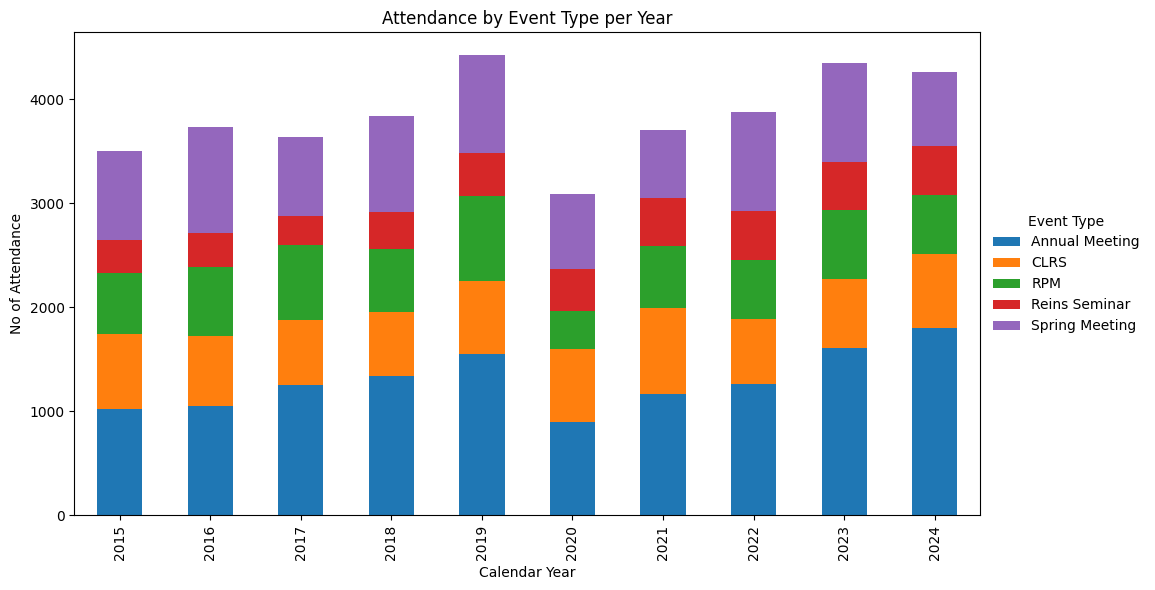

In [201]:
temp = primary_secondary.groupby(['year','Event_desc'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(10, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Event Type per Year')
plt.tight_layout()

plt.legend(title='Event Type', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

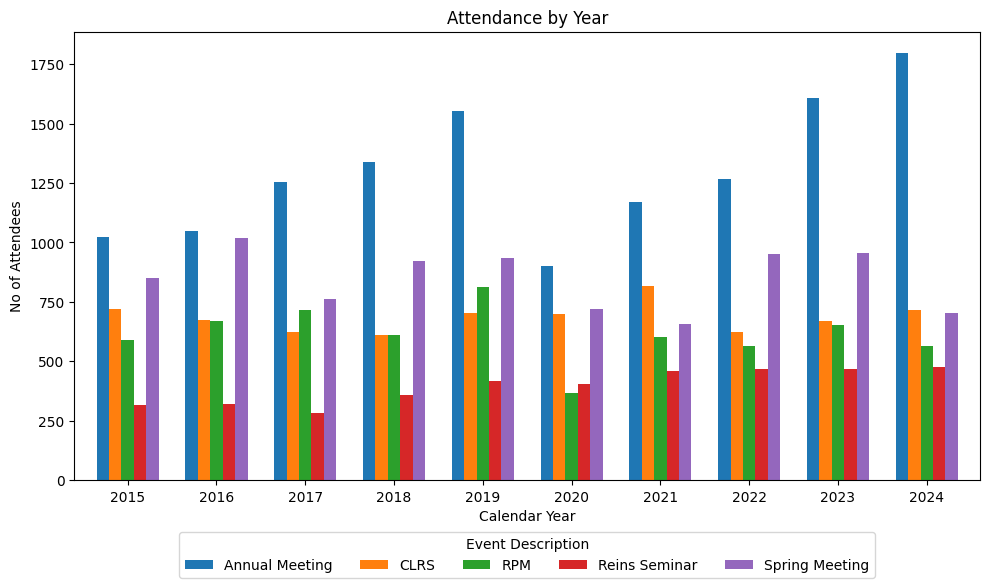

In [202]:
temp = primary_secondary.groupby(['year', 'Event_desc'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7) 


plt.ylabel('No of Attendees')
plt.title('Attendance by Year')
plt.xlabel('Calendar Year')


plt.legend(title='Event Description', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()


In [203]:
%%markdown
#### Annual Meeting

#### Annual Meeting


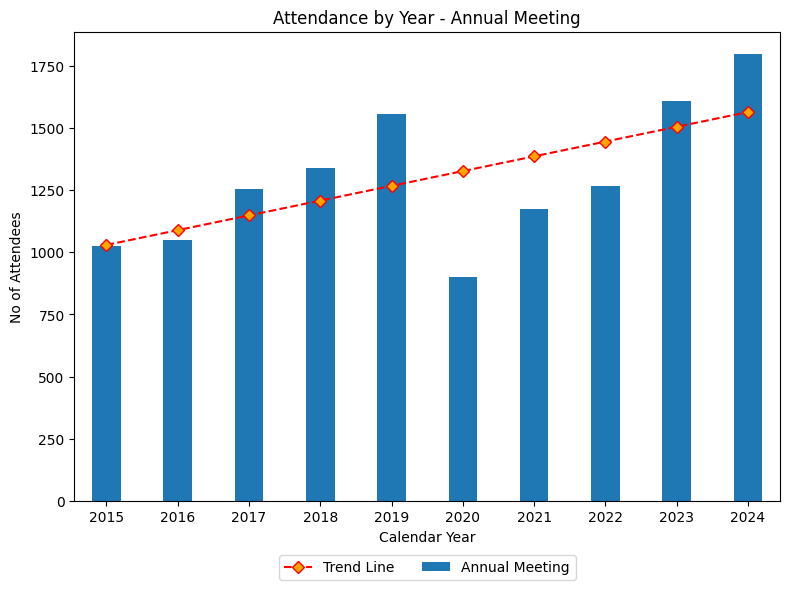

In [204]:
var = 'Annual Meeting'

temp = primary_secondary[primary_secondary.Event_desc == var].groupby(['year', 'Event_desc'])['Customer_ID'].nunique().unstack()

# regression
years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(kind='bar', figsize=(8, 6), width=0.4, legend=False)


x_pos = np.arange(len(years))


ax.plot(x_pos, trendline(years), color='red', linestyle='--', marker='D', label='Trend Line', markerfacecolor='orange', markeredgecolor='red')


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Year - Annual Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [205]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


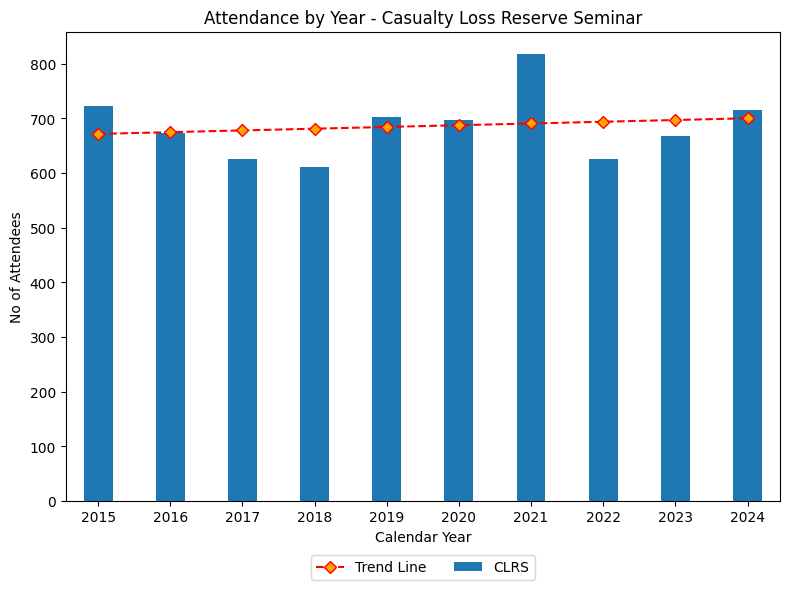

In [206]:
var = 'CLRS'

temp = primary_secondary[primary_secondary.Event_desc == var].groupby(['year', 'Event_desc'])['Customer_ID'].nunique().unstack()

# regression
years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(kind='bar', figsize=(8, 6), width=0.4, legend=False)


x_pos = np.arange(len(years))


ax.plot(x_pos, trendline(years), color='red', linestyle='--', marker='D', label='Trend Line', markerfacecolor='orange', markeredgecolor='red')


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Year - Casualty Loss Reserve Seminar')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [207]:
%%markdown
#### Spring Meeting

#### Spring Meeting


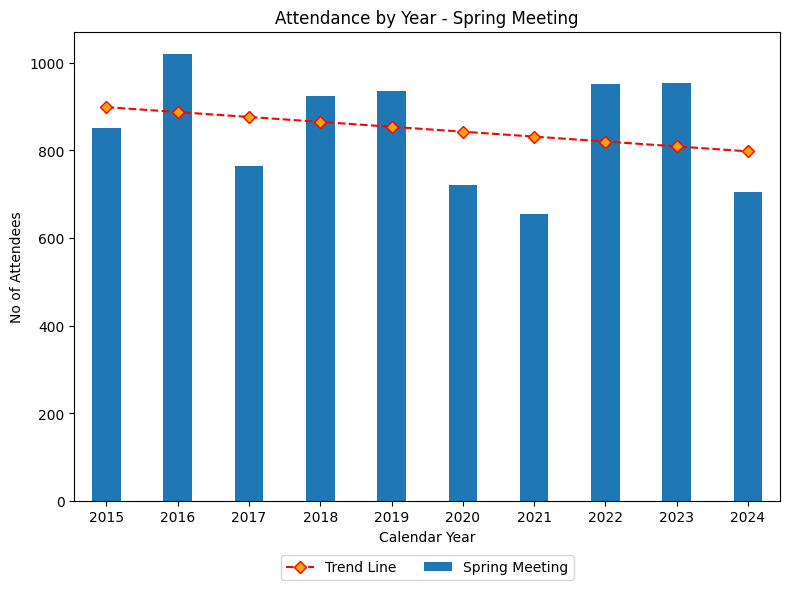

In [208]:
var = 'Spring Meeting'

temp = primary_secondary[primary_secondary.Event_desc == var].groupby(['year', 'Event_desc'])['Customer_ID'].nunique().unstack()

# regression
years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(kind='bar', figsize=(8, 6), width=0.4, legend=False)


x_pos = np.arange(len(years))


ax.plot(x_pos, trendline(years), color='red', linestyle='--', marker='D', label='Trend Line', markerfacecolor='orange', markeredgecolor='red')


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Year - Spring Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [209]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


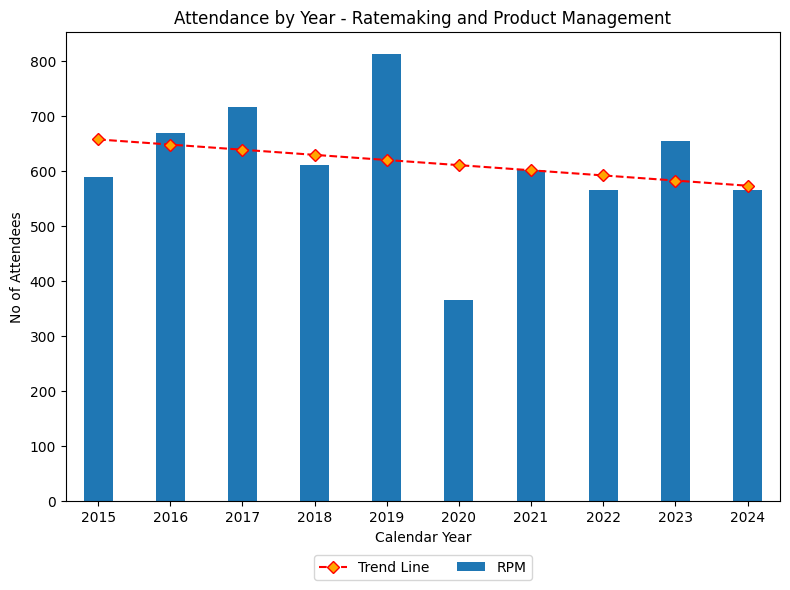

In [210]:
var = 'RPM'

temp = primary_secondary[primary_secondary.Event_desc == var].groupby(['year', 'Event_desc'])['Customer_ID'].nunique().unstack()

# regression
years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(kind='bar', figsize=(8, 6), width=0.4, legend=False)


x_pos = np.arange(len(years))


ax.plot(x_pos, trendline(years), color='red', linestyle='--', marker='D', label='Trend Line', markerfacecolor='orange', markeredgecolor='red')


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Year - Ratemaking and Product Management')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [211]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


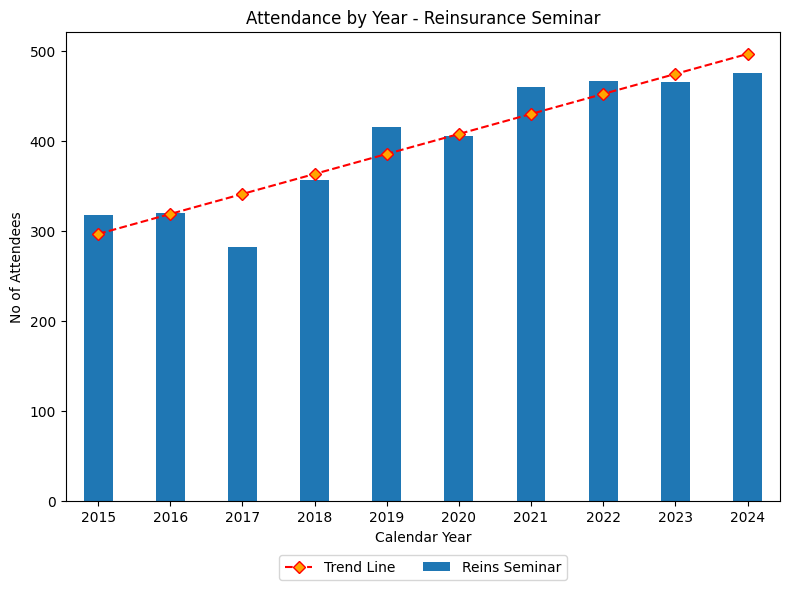

In [212]:
var = 'Reins Seminar'

temp = primary_secondary[primary_secondary.Event_desc == var].groupby(['year', 'Event_desc'])['Customer_ID'].nunique().unstack()

# regression
years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(kind='bar', figsize=(8, 6), width=0.4, legend=False)


x_pos = np.arange(len(years))


ax.plot(x_pos, trendline(years), color='red', linestyle='--', marker='D', label='Trend Line', markerfacecolor='orange', markeredgecolor='red')


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Year - Reinsurance Seminar')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [213]:
%%markdown
### Attendance by Delivery Type

### Attendance by Delivery Type


In [214]:
primary_secondary.Delivery.value_counts(normalize=True)

Delivery
IP    0.682812
V     0.194389
LS    0.122799
Name: proportion, dtype: float64

In [215]:
def get_delivery_desc(Delivery):
    if Delivery == 'IP':
        return 'In Person'
    elif Delivery == 'V':
        return 'Virtual'
    elif Delivery == 'LS':
        return 'Live Stream'
    else:
        return 'Check!'

primary_secondary['Delivery_desc'] = primary_secondary['Delivery'].map(get_delivery_desc)

In [216]:
primary_secondary.Delivery_desc.unique()

array(['In Person', 'Live Stream', 'Virtual'], dtype=object)

In [217]:
primary_secondary.groupby(['year','Delivery_desc'])['Customer_ID'].nunique().unstack()

Delivery_desc,In Person,Live Stream,Virtual
year,,,
2015,3118.0,94.0,NaN
2016,3277.0,136.0,NaN
2017,3189.0,182.0,NaN
2018,3200.0,313.0,NaN
2019,3495.0,519.0,NaN
2020,NaN,NaN,2696.0
2021,695.0,480.0,2272.0
2022,1754.0,929.0,1006.0
2023,2772.0,1231.0,NaN


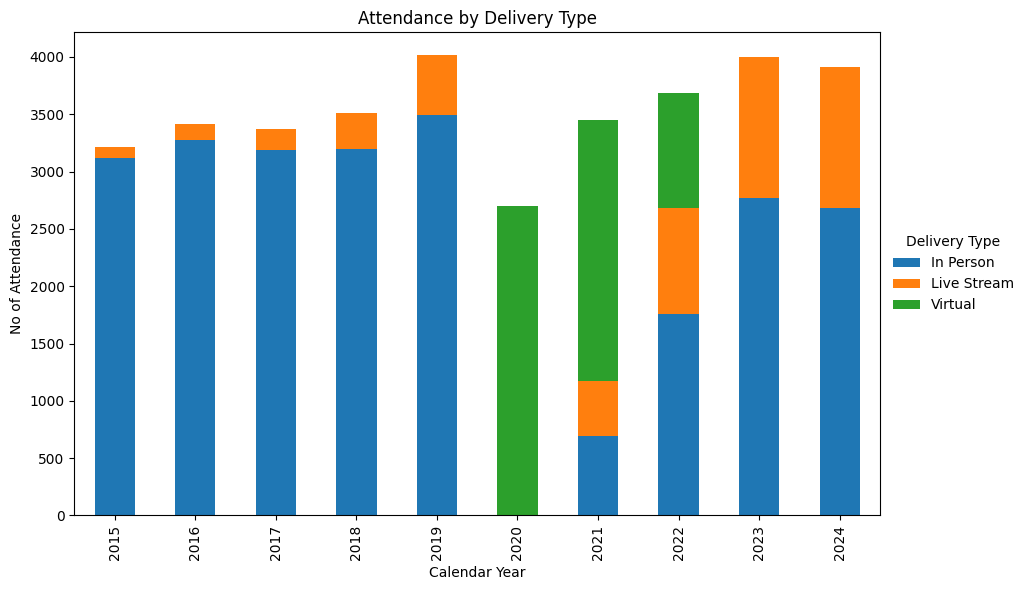

In [218]:
temp = primary_secondary.groupby(['year','Delivery_desc'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Delivery Type')
plt.tight_layout()

plt.legend(title='Delivery Type', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

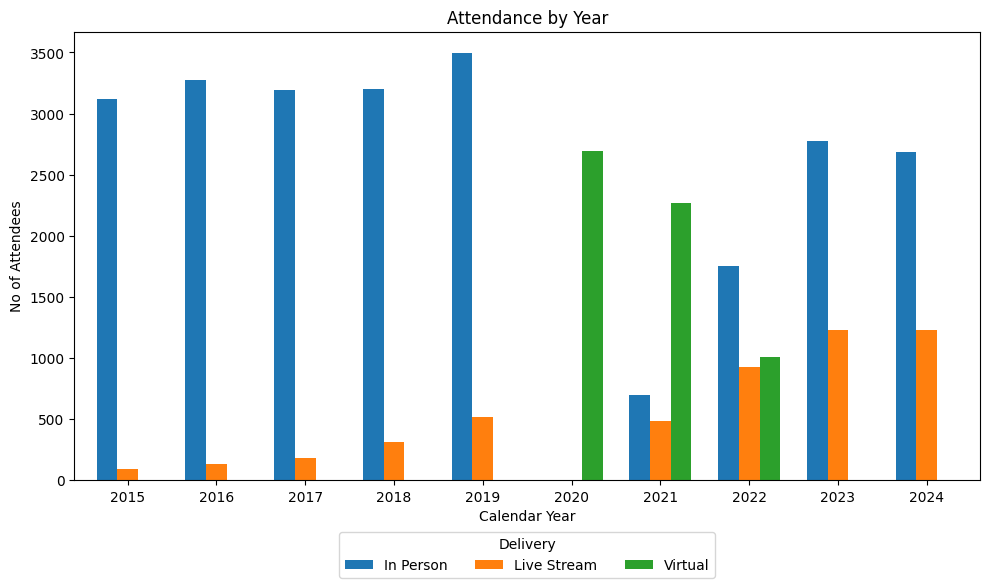

In [219]:
temp = primary_secondary.groupby(['year', 'Delivery_desc'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Year')
plt.xlabel('Calendar Year')


plt.legend(title='Delivery', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [220]:
%%markdown
#### Annual Meeting

#### Annual Meeting


In [221]:
#primary_secondary.tail(2)

In [222]:
temp = (
    primary_secondary[primary_secondary.Event_desc == 'Annual Meeting']
    .groupby(['year', 'Delivery_desc'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Annual_Meeting
temp[temp.index>=2021]

Delivery_desc,In Person,Live Stream,Virtual,Secondary Data
year,,,,
2021,695,480,0,0
2022,823,447,0,0
2023,1219,392,0,0
2024,1355,443,0,0


In [223]:
primary_secondary_1 = pd.concat([primary_secondary, secondary_2025], ignore_index=True).drop_duplicates()

In [224]:
primary_secondary_1[primary_secondary_1.year==2025]['Event_desc'].unique()

array(['Spring Meeting', 'Reins Seminar', 'RPM'], dtype=object)

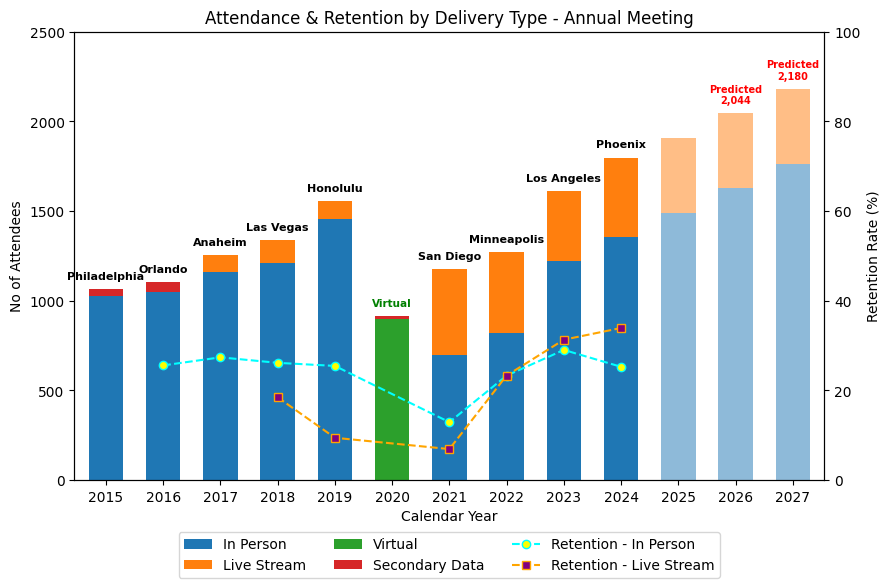

In [225]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Delivery_desc'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Annual_Meeting



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y = df["In Person"].values

model = LinearRegression()
model.fit(X, y)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds = model.predict(future_years)

temp_future = pd.DataFrame(
    {"In Person": future_preds.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2024, "Live Stream"].mean()
temp.loc[2025:2027, "Live Stream"] = avg_1




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Delivery_desc'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    elif yr == 2021 and (2019 in year_set):
        year_prev_map[yr] = 2019
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "In Person": "cyan",
    "Live Stream": "orange",
    "default": "black"
}

markerface_colors ={
    "In Person": "yellow",
    "Live Stream": "purple",
    "default": "black"
}

marker_style ={
    "In Person": "o",
    "Live Stream": "s",
    "default": "d"
}

ax2 = ax.twinx()
for col in retention_df.columns:
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020] = "Virtual"

for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0), 
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Delivery Type - Annual Meeting')

ymax = 2500
ax.set_ylim(top=ymax)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()


In [226]:
print(temp)
#print(retention_df)

      In Person  Live Stream  Virtual  Secondary Data
year                                                 
2015       1024          0.0      0.0            43.0
2016       1048          0.0      0.0            58.0
2017       1162         92.0      0.0             0.0
2018       1213        127.0      0.0             0.0
2019       1454        101.0      0.0             0.0
2020          0          0.0    899.0            14.0
2021        695        480.0      0.0             0.0
2022        823        447.0      0.0             0.0
2023       1219        392.0      0.0             0.0
2024       1355        443.0      0.0             0.0
2025       1491        417.5      NaN             NaN
2026       1627        417.5      NaN             NaN
2027       1763        417.5      NaN             NaN


In [227]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


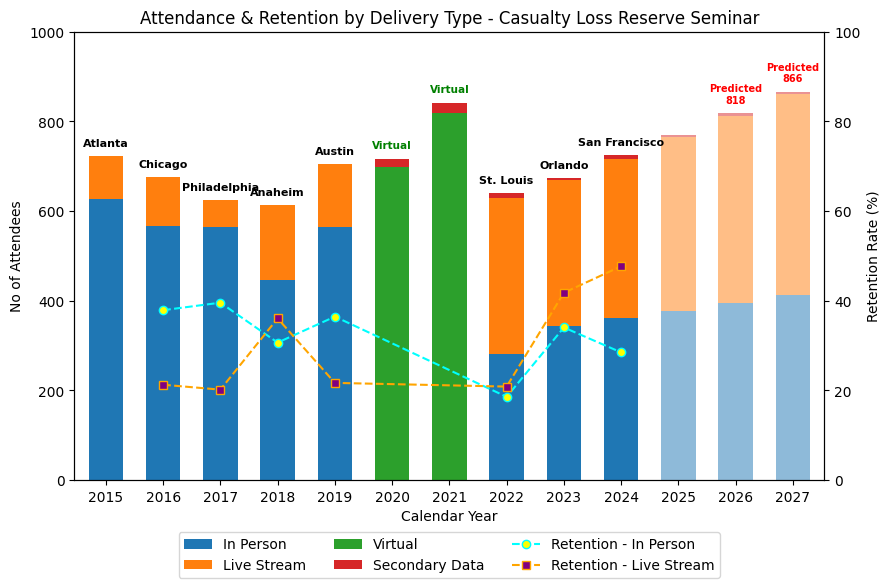

In [228]:
var = 'CLRS'



temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Delivery_desc'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_CLRS




# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["In Person"].values
y2 = df['Live Stream'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)

temp_future = pd.DataFrame(
    {"In Person": future_preds_1.astype(int),
    'Live Stream': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2024, "Secondary Data"].mean()
temp.loc[2025:2027, "Secondary Data"] = avg_1




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )



x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Delivery_desc'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    elif yr in (2020, 2021):
        year_prev_map[yr] = None   # skip retention
    elif yr == 2022 and (2019 in year_set):
        year_prev_map[yr] = 2019   
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        
        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "In Person": "cyan",
    "Live Stream": "orange",
    "default": "black"
}

markerface_colors ={
    "In Person": "yellow",
    "Live Stream": "purple",
    "default": "black"
}

marker_style ={
    "In Person": "o",
    "Live Stream": "s",
    "default": "d"
}

ax2 = ax.twinx()
for col in retention_df.columns:
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Delivery Type - Casualty Loss Reserve Seminar')


ymax = 1000
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [229]:
print(temp)
#print(retention_df)

      In Person  Live Stream  Virtual  Secondary Data
year                                                 
2015        628           94      0.0             0.0
2016        566          109      0.0             0.0
2017        564           61      0.0             0.0
2018        447          166      0.0             0.0
2019        565          139      0.0             0.0
2020          0            0    698.0            19.0
2021          0            0    818.0            24.0
2022        282          347      0.0            11.0
2023        344          325      0.0             4.0
2024        361          356      0.0             7.0
2025        378          387      NaN             5.5
2026        395          418      NaN             5.5
2027        412          449      NaN             5.5


In [230]:
%%markdown
#### Spring Meeting

#### Spring Meeting


In [231]:
#print(temp)

In [232]:
#primary_secondary_1[primary_secondary_1.Event_desc == 'Spring Meeting'].groupby(['year', 'Delivery_desc'])['Customer_ID'].nunique().unstack(fill_value=0).sort_index()

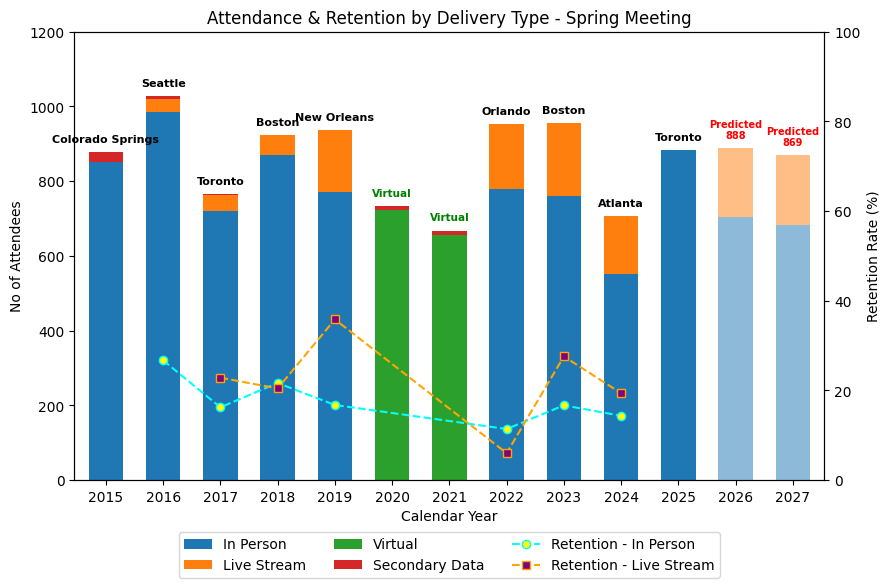

In [233]:
var = 'Spring Meeting'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Delivery_desc'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Spring_Meeting



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2023)]
X = df.index.values.reshape(-1, 1)   
y = df["In Person"].values

model = LinearRegression()
model.fit(X, y)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds = model.predict(future_years)

temp_future = pd.DataFrame(
    {"In Person": future_preds.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2023, "Live Stream"].mean()
temp.loc[2026:2027, "Live Stream"] = avg_1



years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()



for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Delivery_desc'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    elif yr in (2020, 2021):
        year_prev_map[yr] = None   # skip retention
    elif yr == 2022 and (2019 in year_set):
        year_prev_map[yr] = 2019   
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "In Person": "cyan",
    "Live Stream": "orange",
    "default": "black"
}

markerface_colors ={
    "In Person": "yellow",
    "Live Stream": "purple",
    "default": "black"
}

marker_style ={
    "In Person": "o",
    "Live Stream": "s",
    "default": "d"
}

ax2 = ax.twinx()
for col in retention_df.columns:
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Toronto"
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0), 
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Delivery Type - Spring Meeting')


ymax = 1200
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [234]:
temp

,In Person,Live Stream,Virtual,Secondary Data
year,,,,
2015,850,0.0,0.0,28.0
2016,985,35.0,0.0,8.0
2017,720,44.0,0.0,2.0
2018,871,53.0,0.0,0.0
2019,772,166.0,0.0,0.0
2020,0,0.0,722.0,12.0
2021,0,0.0,655.0,13.0
2022,779,174.0,0.0,0.0
2023,760,196.0,0.0,0.0


In [235]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


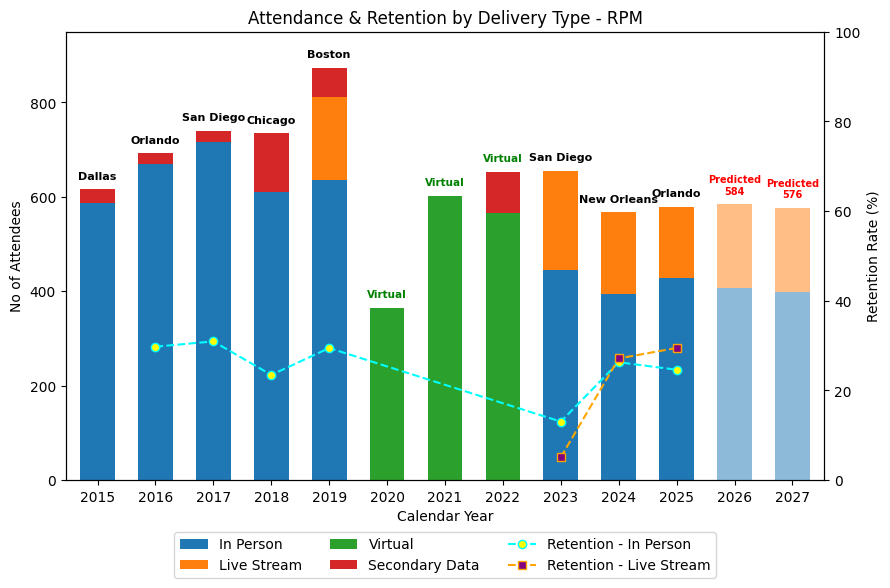

In [236]:
var = 'RPM'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Delivery_desc'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_RPM



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y = df["In Person"].values

model = LinearRegression()
model.fit(X, y)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds = model.predict(future_years)

temp_future = pd.DataFrame(
    {"In Person": future_preds.astype(float)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2025, "Live Stream"].mean()
#avg_2 = temp.loc[2023:2025, "In Person"].mean()
temp.loc[2026:2027, "Live Stream"] = avg_1
#temp.loc[2026:2027, "In Person"] = avg_2




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Delivery_desc'])['Customer_ID']
    .apply(set)
    .unstack() 
)


year_set = set(years)
year_prev_map = {}
for i, yr in enumerate(years):
    if i == 0:
        year_prev_map[yr] = None
    else:
        prev_candidates = [y for y in years[:i] if y not in (2020, 2021, 2022)]
        year_prev_map[yr] = prev_candidates[-1] if prev_candidates else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan


        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)
#retention_df.loc[[2020, 2021, 2022], :] = np.nan

retention_colors = {
    "In Person": "cyan",
    "Live Stream": "orange",
    "default": "black"
}

markerface_colors ={
    "In Person": "yellow",
    "Live Stream": "purple",
    "default": "black"
}

marker_style ={
    "In Person": "o",
    "Live Stream": "s",
    "default": "d"
}

ax2 = ax.twinx()
for col in retention_df.columns:
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Orlando"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Delivery Type - RPM')


ymax = 950
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [237]:
print(temp)

       In Person  Live Stream  Virtual  Secondary Data
year                                                  
2015  588.000000     0.000000      0.0            28.0
2016  669.000000     0.000000      0.0            23.0
2017  716.000000     0.000000      0.0            24.0
2018  611.000000     0.000000      0.0           124.0
2019  636.000000   176.000000      0.0            61.0
2020    0.000000     0.000000    365.0             0.0
2021    0.000000     0.000000    602.0             0.0
2022    0.000000     0.000000    565.0            88.0
2023  445.000000   210.000000      0.0             0.0
2024  394.000000   173.000000      0.0             0.0
2025  429.000000   150.000000      0.0             0.0
2026  406.666667   177.666667      NaN             NaN
2027  398.666667   177.666667      NaN             NaN


In [238]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


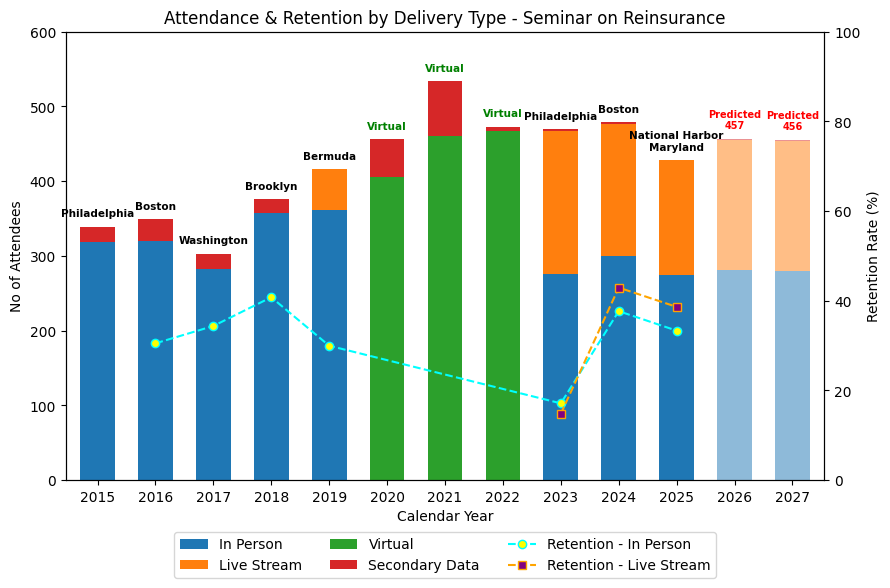

In [239]:
var = 'Reins Seminar'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Delivery_desc'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_Reins_Seminar



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["In Person"].values
y2 = df['Live Stream'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)

temp_future = pd.DataFrame(
    {"In Person": future_preds_1.astype(int),
    'Live Stream': future_preds_2.astype(float)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2025, "Secondary Data"].mean()
avg_2 = temp.loc[2023:2025, "Live Stream"].mean()
temp.loc[2026:2027, "Secondary Data"] = avg_1
temp.loc[2026:2027, "Live Stream"] = avg_2



years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Delivery_desc'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for i, yr in enumerate(years):
    if i == 0:
        year_prev_map[yr] = None
    else:
        prev_candidates = [y for y in years[:i] if y not in (2020, 2021, 2022)]
        year_prev_map[yr] = prev_candidates[-1] if prev_candidates else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue


        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

 
        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)
#retention_df.loc[[2020, 2021, 2022], :] = np.nan


retention_colors = {
    "In Person": "cyan",
    "Live Stream": "orange",
    "default": "black"
}

markerface_colors ={
    "In Person": "yellow",
    "Live Stream": "purple",
    "default": "black"
}

marker_style ={
    "In Person": "o",
    "Live Stream": "s",
    "default": "d"
}

ax2 = ax.twinx()
for col in retention_df.columns:
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "National Harbor\nMaryland"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=7.5,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0), 
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Delivery Type - Seminar on Reinsurance')


ymax = 600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [240]:
print(temp)

      In Person  Live Stream  Virtual  Secondary Data
year                                                 
2015        318     0.000000      0.0            21.0
2016        320     0.000000      0.0            29.0
2017        282     0.000000      0.0            21.0
2018        357     0.000000      0.0            19.0
2019        362    54.000000      0.0             0.0
2020          0     0.000000    405.0            51.0
2021          0     0.000000    460.0            74.0
2022          0     0.000000    467.0             6.0
2023        276   191.000000      0.0             3.0
2024        300   176.000000      0.0             3.0
2025        274   154.000000      0.0             0.0
2026        281   173.666667      NaN             2.0
2027        280   173.666667      NaN             2.0


In [241]:
%%markdown
### Attendance by Registrant Region
* State (different to Location_state)

### Attendance by Registrant Region
* State (different to Location_state)


In [242]:
def assign_region(state):
    northeast = {'ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA'}
    midwest = {'OH', 'IN', 'IL', 'MI', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS'}
    south = {'DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'FL', 'KY', 'TN', 'MS', 'AL', 'OK', 'TX', 'AR', 'LA'}
    west = {'MT', 'ID', 'WY', 'CO', 'NM', 'AZ', 'UT', 'NV', 'WA', 'OR', 'CA', 'AK', 'HI'}

    if state in northeast:
        return '4. Northeast'
    elif state in midwest:
        return '3. Midwest'
    elif state in south:
        return '1. South'
    elif state in west:
        return '2. West'
    else:
        return '5. Non-US'

In [243]:
primary_secondary['Region'] = primary_secondary['State'].apply(assign_region)

In [244]:
#primary_3[(primary_3.Region=='Unknown')].Country.unique()

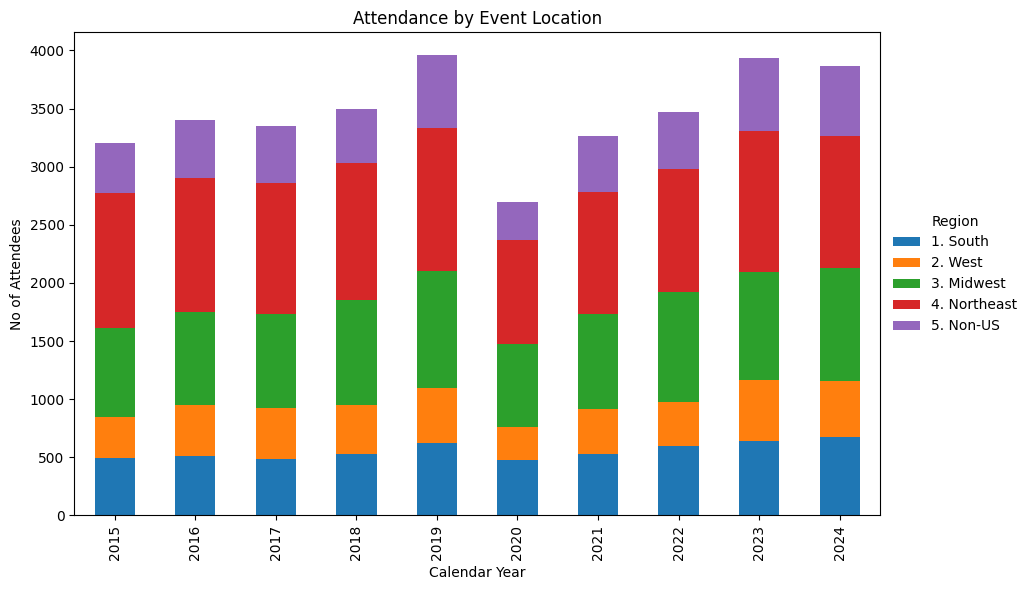

In [245]:
temp = primary_secondary.groupby(['year','Region'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Event Location')
plt.tight_layout()

plt.legend(title='Region', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

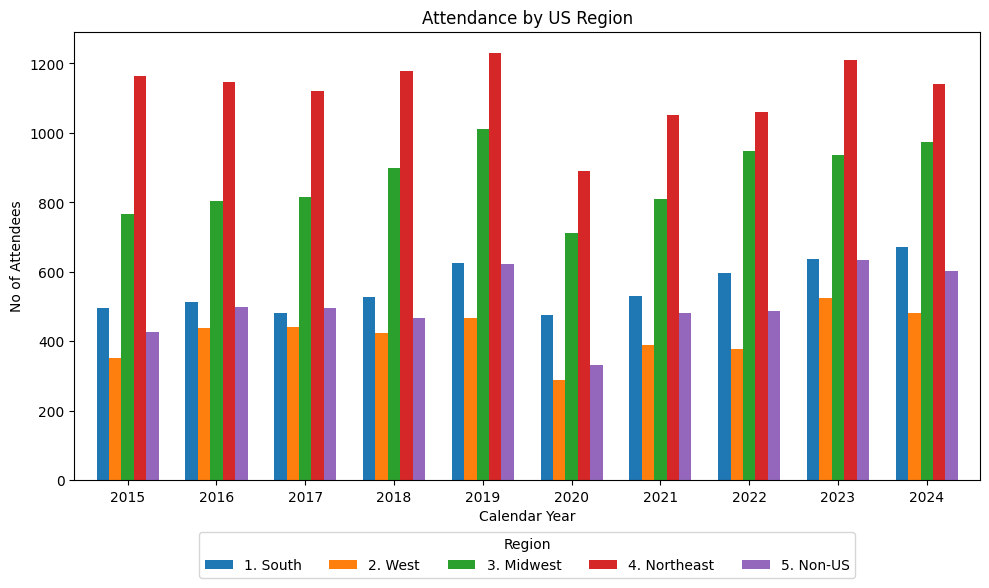

In [246]:
temp = primary_secondary.groupby(['year', 'Region'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7) 


plt.ylabel('No of Attendees')
plt.title('Attendance by US Region')
plt.xlabel('Calendar Year')


plt.legend(title='Region', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [247]:
%%markdown
#### Annual Meeting

#### Annual Meeting


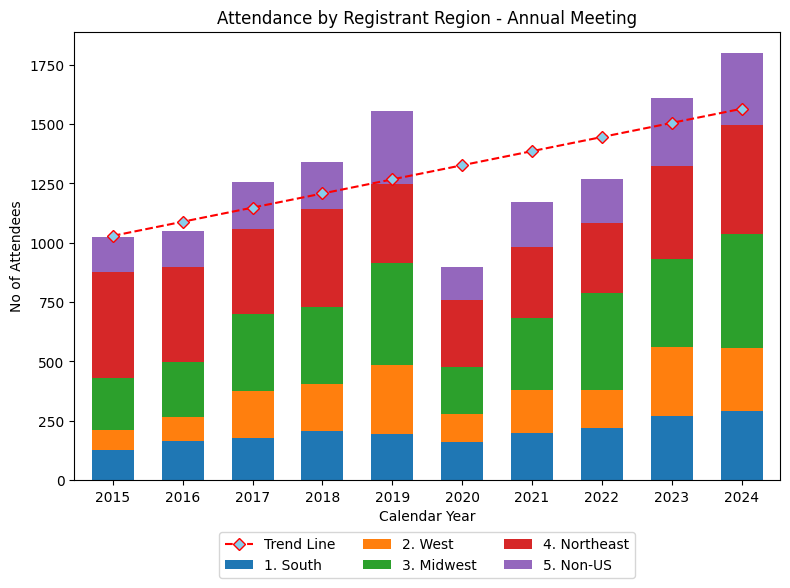

In [248]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Region'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0) 
)


years = temp.index.values
attendees = temp.sum(axis=1).values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registrant Region - Annual Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.tight_layout()
plt.show()

In [249]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


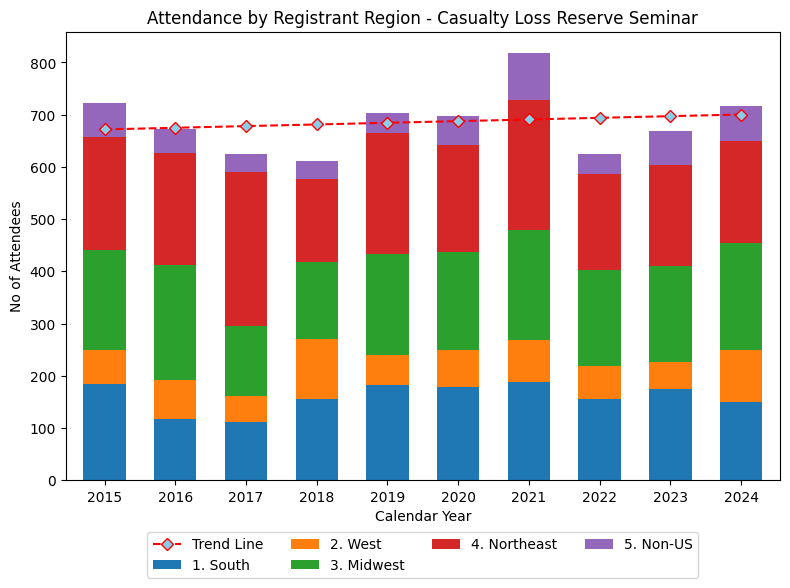

In [250]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Region'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0) 
)


years = temp.index.values
attendees = temp.sum(axis=1).values

# regression 
coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registrant Region - Casualty Loss Reserve Seminar')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [251]:
%%markdown
#### Spring Meeting

#### Spring Meeting


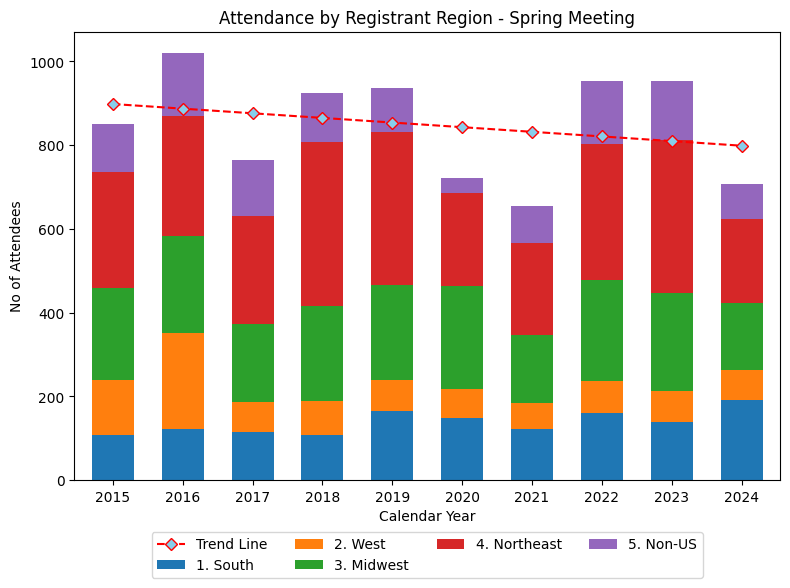

In [252]:
var = 'Spring Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Region'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0) 
)


years = temp.index.values
attendees = temp.sum(axis=1).values

# regression 
coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registrant Region - Spring Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [253]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


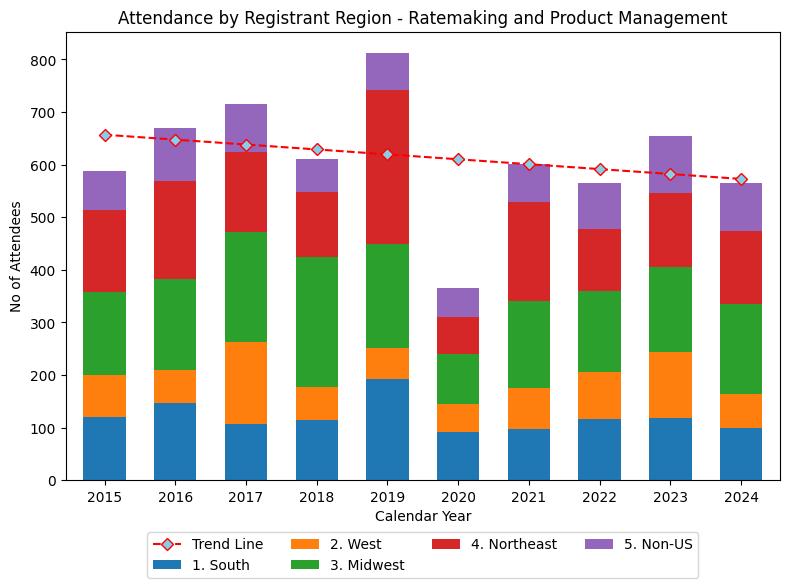

In [254]:
var = 'RPM'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Region'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0)  
)


years = temp.index.values
attendees = temp.sum(axis=1).values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registrant Region - Ratemaking and Product Management')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [255]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


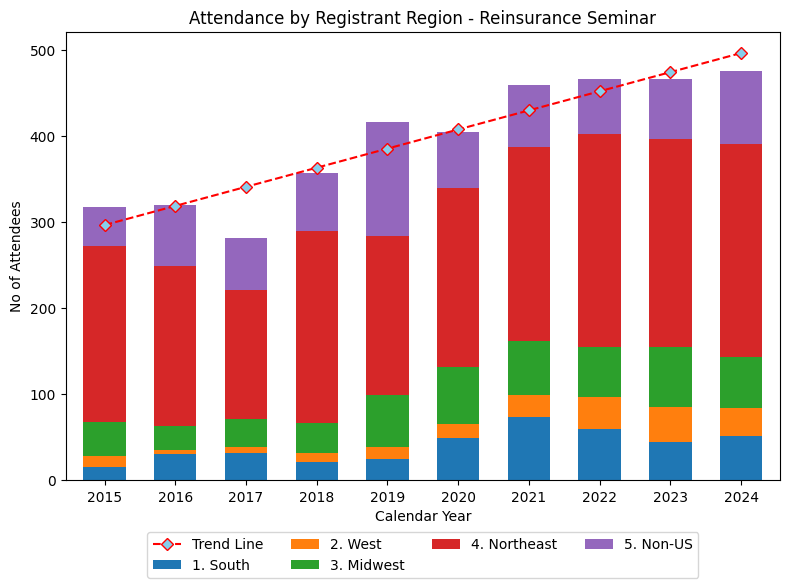

In [256]:
var = 'Reins Seminar'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Region'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0)  
)


years = temp.index.values
attendees = temp.sum(axis=1).values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registrant Region - Reinsurance Seminar')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [257]:
%%markdown
### Attendance by Speaker

### Attendance by Speaker


In [258]:
primary_secondary.loc[primary_secondary.Speaker=='Other', 'Speaker'] = 'Non-speaker'
primary_secondary_1.loc[primary_secondary_1.Speaker=='Other', 'Speaker'] = 'Non-speaker'

In [259]:
primary_secondary.Speaker.value_counts()

Speaker
Non-speaker    40896
Speaker         7044
Name: count, dtype: int64

In [260]:
#primary_secondary.tail(3)

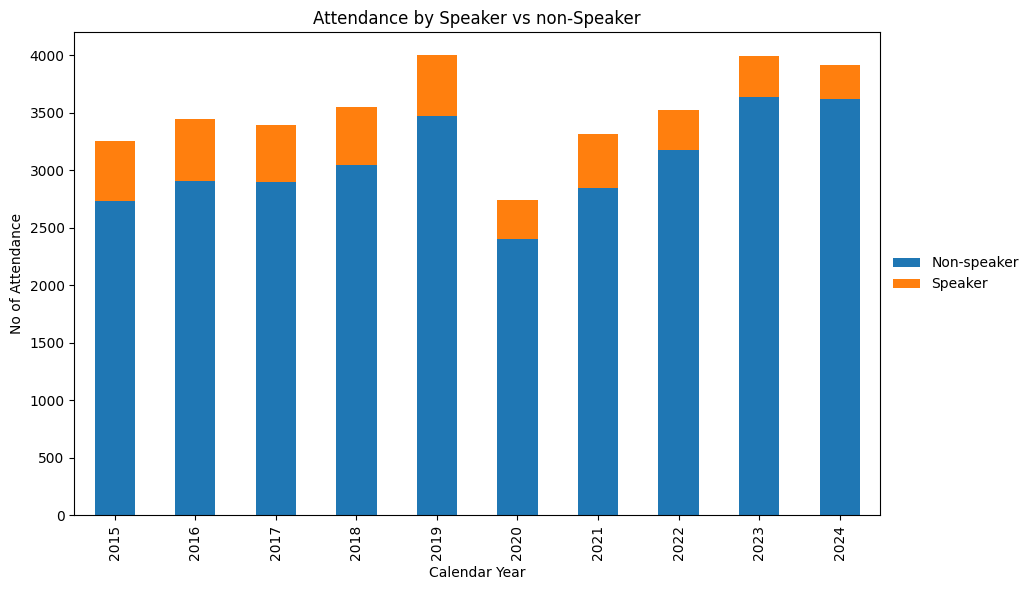

In [261]:
temp = primary_secondary.groupby(['year','Speaker'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Speaker vs non-Speaker')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

In [262]:
%%markdown
#### Annual Meeting

#### Annual Meeting


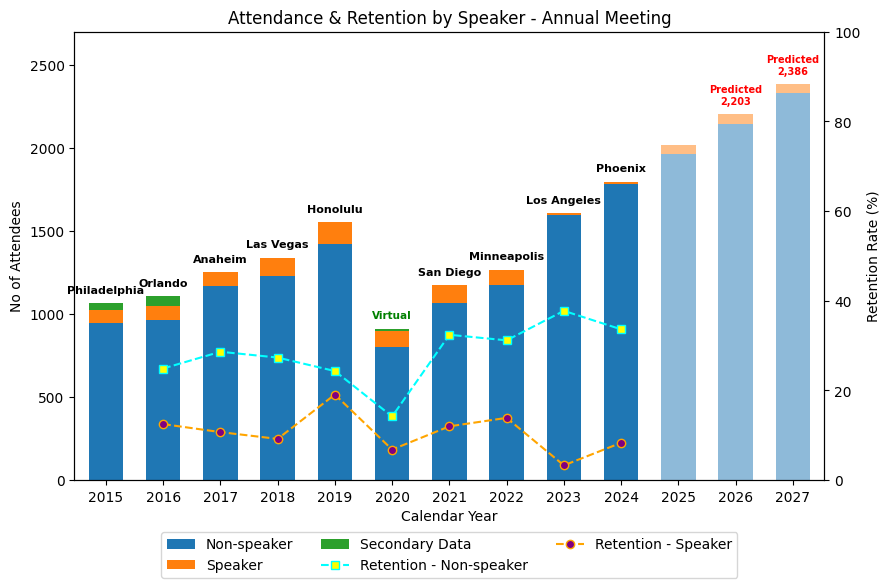

In [263]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Speaker'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Annual_Meeting



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["Non-speaker"].values

model1 = LinearRegression()
model1.fit(X, y1)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)


temp_future = pd.DataFrame(
    {"Non-speaker": future_preds_1.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2021:2024, "Speaker"].mean()
temp.loc[2025:2027, "Speaker"] = avg_1




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Speaker'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Speaker": "orange",
    "Non-speaker": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Speaker": "purple",
    "Non-speaker": "yellow",
    "default": "grey"
}

marker_style ={
    "Speaker": "o",
    "Non-speaker": "s",
    "default": "d"
}

skip_speaker_groups = ["Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_speaker_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Speaker - Annual Meeting')


ymax = 2700
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [264]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


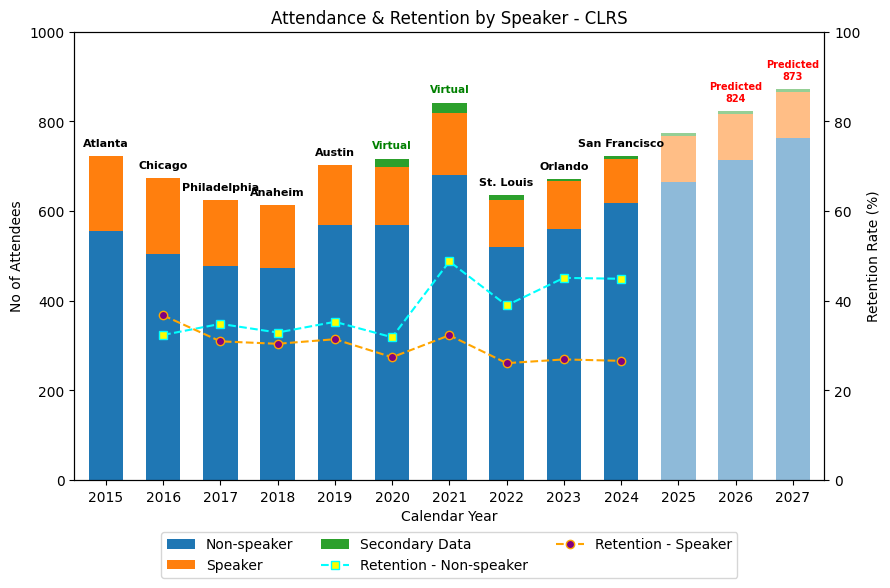

In [265]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Speaker'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  # ensure chronological order
)
temp['Secondary Data'] = fix_CLRS



# regression 
df = temp[temp.index>=2022]
X = df.index.values.reshape(-1, 1)   
y1 = df["Non-speaker"].values

model1 = LinearRegression()
model1.fit(X, y1)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)


temp_future = pd.DataFrame(
    {"Non-speaker": future_preds_1.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2024, "Speaker"].mean()
avg_2 = temp.loc[2022:2024, "Secondary Data"].mean()
temp.loc[2025:2027, "Speaker"] = avg_1
temp.loc[2025:2027, "Secondary Data"] = avg_2




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Speaker'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan


        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Speaker": "orange",
    "Non-speaker": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Speaker": "purple",
    "Non-speaker": "yellow",
    "default": "grey"
}

marker_style ={
    "Speaker": "o",
    "Non-speaker": "s",
    "default": "d"
}

skip_speaker_groups = ["Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_speaker_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Speaker - CLRS')


ymax = 1000
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [266]:
%%markdown
#### Spring Meeting

#### Spring Meeting


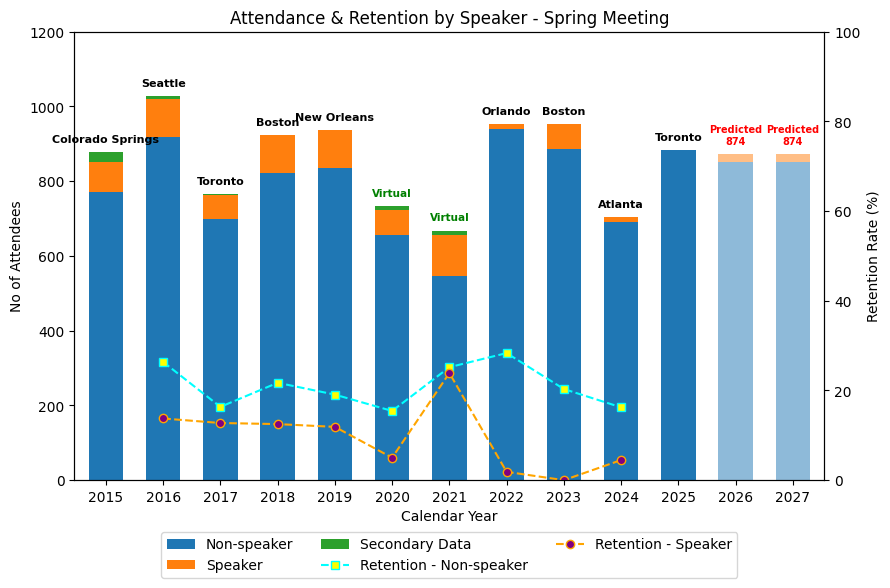

In [267]:
var = 'Spring Meeting'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Speaker'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Spring_Meeting



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2025)]
X = df.index.values.reshape(-1, 1)   
y1 = df["Non-speaker"].values

model1 = LinearRegression()
model1.fit(X, y1)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)


temp_future = pd.DataFrame(
    {"Non-speaker": future_preds_1.astype(float)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2025, "Speaker"].mean()
avg_2 = temp.loc[2022:2025, "Non-speaker"].mean()
temp.loc[2026:2027, "Speaker"] = avg_1
temp.loc[2026:2027, "Non-speaker"] = avg_2



years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Speaker'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue


        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Speaker": "orange",
    "Non-speaker": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Speaker": "purple",
    "Non-speaker": "yellow",
    "default": "grey"
}

marker_style ={
    "Speaker": "o",
    "Non-speaker": "s",
    "default": "d"
}

skip_speaker_groups = ["Unknown"]

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_speaker_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Toronto"
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0), 
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Speaker - Spring Meeting')


ymax = 1200
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [268]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


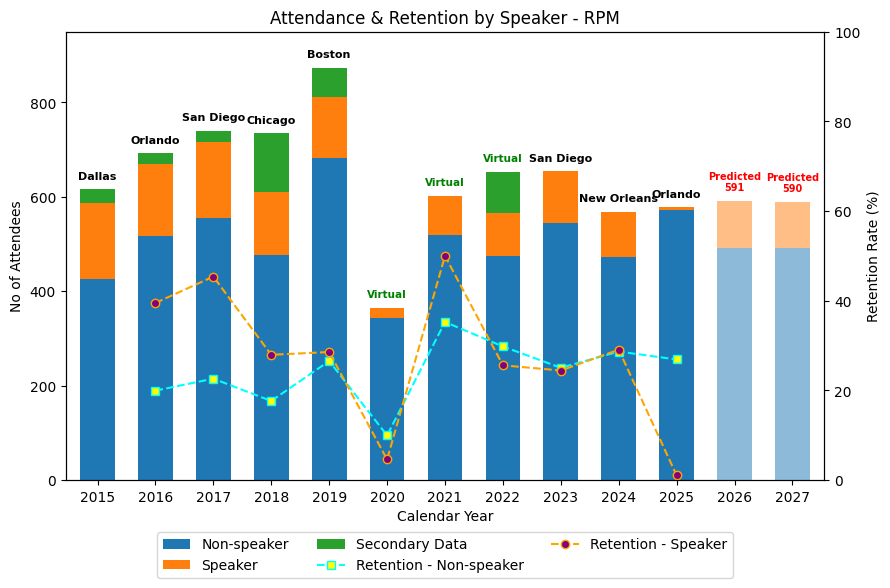

In [269]:
var = 'RPM'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Speaker'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)
temp['Secondary Data'] = fix_RPM



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2024)]
X = df.index.values.reshape(-1, 1)   
y1 = df["Non-speaker"].values

model1 = LinearRegression()
model1.fit(X, y1)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)


temp_future = pd.DataFrame(
    {"Non-speaker": future_preds_1.astype(float)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2024, "Speaker"].mean()
#avg_2 = temp.loc[2022:2024, "Other"].mean()
temp.loc[2026:2027, "Speaker"] = avg_1
#temp.loc[2026:2027, "Other"] = avg_2




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Speaker'])['Customer_ID']
    .apply(set)
    .unstack() 
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue


        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan


        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Speaker": "orange",
    "Non-speaker": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Speaker": "purple",
    "Non-speaker": "yellow",
    "default": "grey"
}

marker_style ={
    "Speaker": "o",
    "Non-speaker": "s",
    "default": "d"
}

skip_speaker_groups = ["Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_speaker_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Orlando"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Speaker - RPM')


ymax = 950
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [270]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


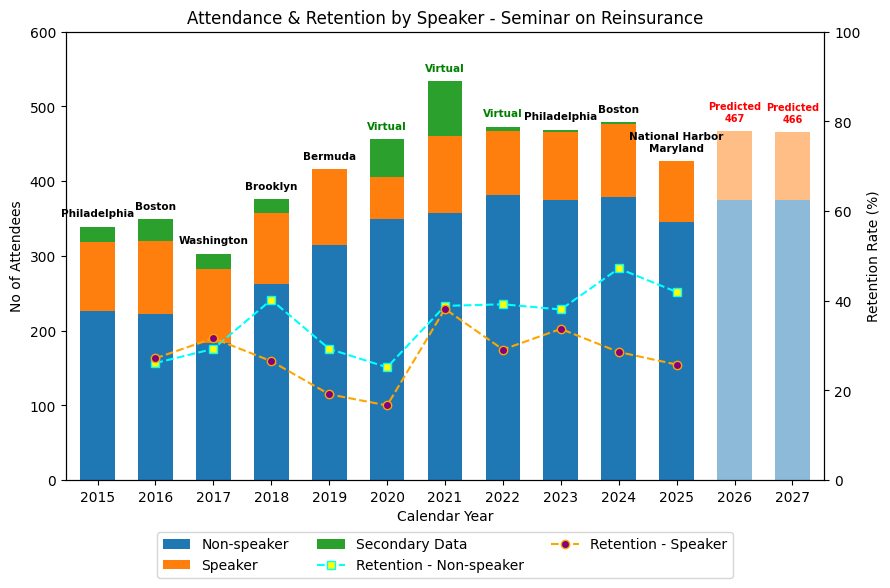

In [271]:
var = 'Reins Seminar'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Speaker'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_Reins_Seminar



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2024)]
X = df.index.values.reshape(-1, 1)   
y1 = df["Non-speaker"].values

model1 = LinearRegression()
model1.fit(X, y1)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)


temp_future = pd.DataFrame(
    {"Non-speaker": future_preds_1.astype(float)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2024, "Speaker"].mean()
#avg_2 = temp.loc[2022:2024, "Other"].mean()
temp.loc[2026:2027, "Speaker"] = avg_1
#temp.loc[2026:2027, "Other"] = avg_2




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))

cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Speaker'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

    
        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan


        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Speaker": "orange",
    "Non-speaker": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Speaker": "purple",
    "Non-speaker": "yellow",
    "default": "grey"
}

marker_style ={
    "Speaker": "o",
    "Non-speaker": "s",
    "default": "d"
}

skip_speaker_groups = ["Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_speaker_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "National Harbor\nMaryland"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=7.5,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0), 
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )

#
ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Speaker - Seminar on Reinsurance')


ymax = 600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [272]:
%%markdown
### Attendance by Registration

### Attendance by Registration


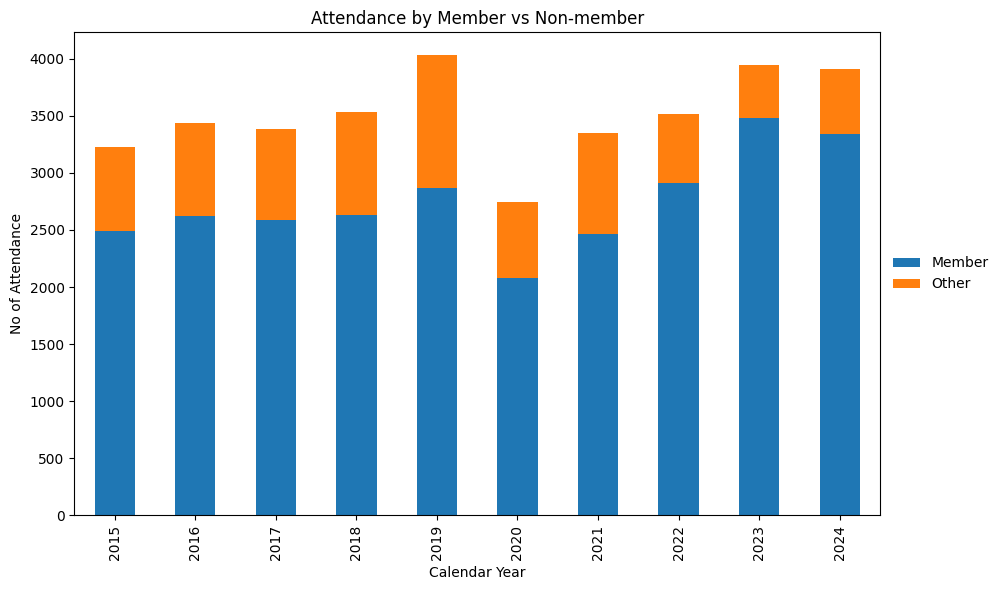

In [273]:
temp = primary_secondary.groupby(['year','Member'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Member vs Non-member')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

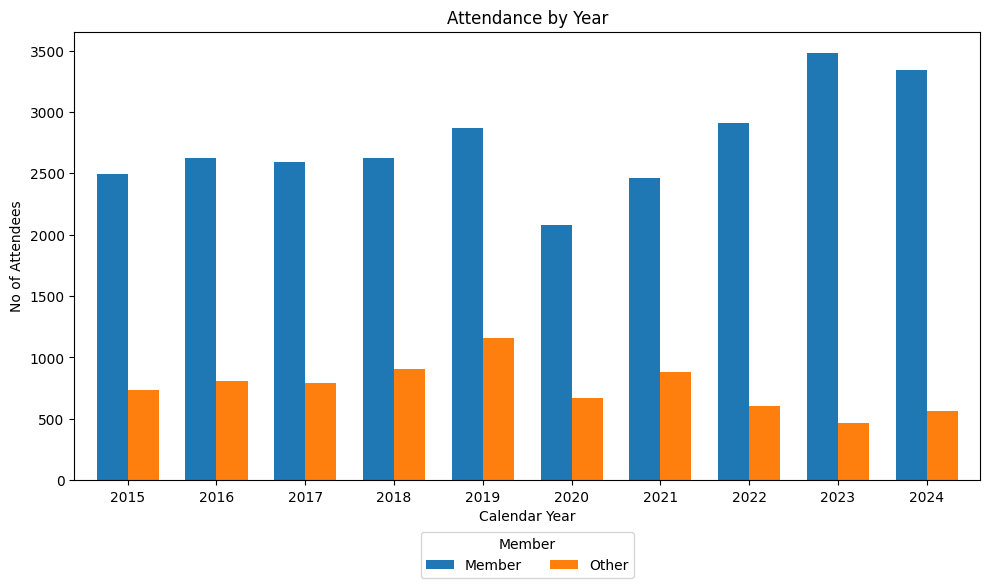

In [274]:
temp = primary_secondary.groupby(['year', 'Member'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Year')
plt.xlabel('Calendar Year')


plt.legend(title='Member', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [275]:
#%%markdown
#### Annual Meeting

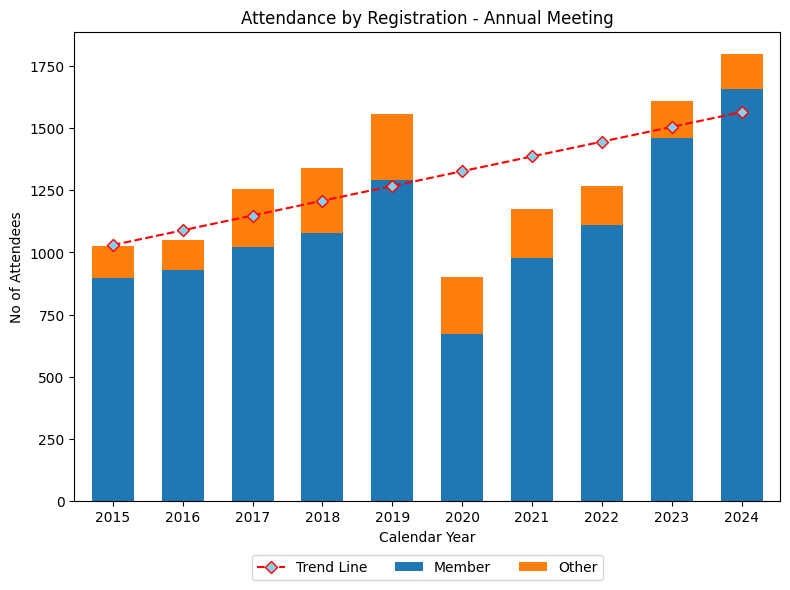

In [276]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Member'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0)  
)


years = temp.index.values
attendees = temp.sum(axis=1).values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)

# Plot stacked bar chart
ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registration - Annual Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [277]:
#%%markdown
#### Casualty Loss Reserve Seminar

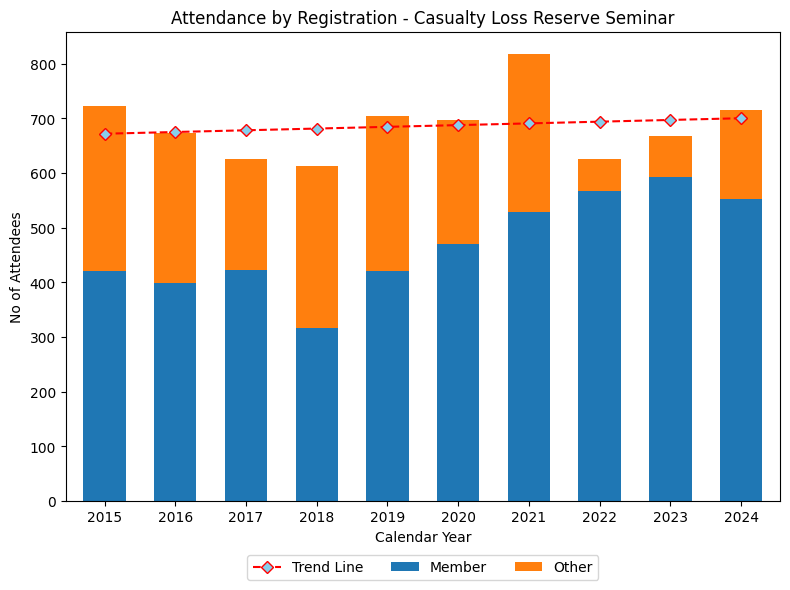

In [278]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Member'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
)


years = temp.index.values
attendees = temp.sum(axis=1).values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registration - Casualty Loss Reserve Seminar')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [279]:
#%%markdown
#### Spring Meeting

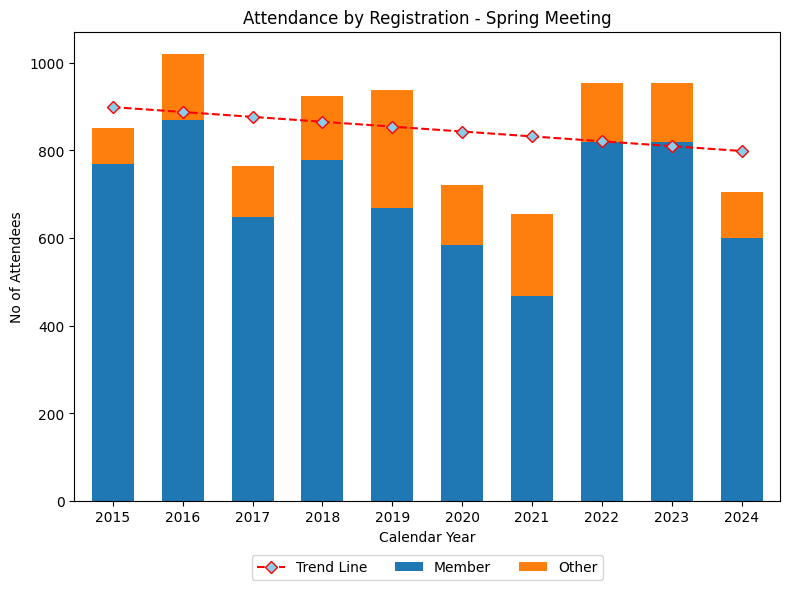

In [280]:
var = 'Spring Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Member'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0) 
)

years = temp.index.values
attendees = temp.sum(axis=1).values

# regression 
coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Registration - Spring Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [281]:
#%%markdown
#### Ratemaking and Product Management

In [282]:
#primary_secondary[(primary_secondary.Event_desc=='Reins Seminar')&(primary_secondary.Member).isna()]
#primary_secondary[(primary_secondary.Customer_ID=='000000544I')].head(3)

In [283]:
%%markdown
### Attendance by Continent

### Attendance by Continent


In [284]:
#secondary_2 = secondary[['Customer_Number','year','Age','Age_group','gender_1','Home_Continent','Membership']].drop_duplicates()

In [285]:
#secondary_2.tail(2)

In [286]:
#primary_secondary.head(2)

In [287]:
primary_secondary.shape
#primary_3.groupby('year').agg({'Customer_ID':'nunique'})

(47940, 32)

In [288]:
# combo = pd.merge(primary_3, secondary_2, how='left', left_on=['Customer_ID','year'], right_on=['Customer_Number','year'])
primary_secondary['Home_Continent'] = primary_secondary['Home_Continent'].fillna('Unknown')

In [289]:
#combo.shape
#combo[combo.year==2020].Home_Continent.isna().sum()

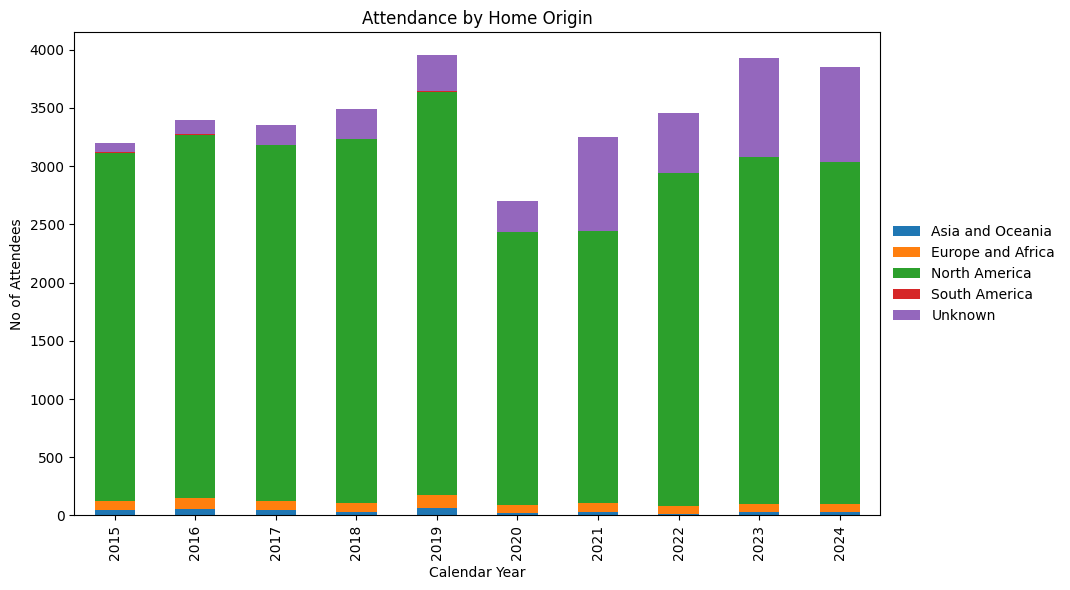

In [290]:
temp = primary_secondary.groupby(['year','Home_Continent'])['Customer_ID'].nunique().unstack()
#print(combo.groupby('year').agg({'Customer_ID':'nunique'}))
#print(temp)

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Home Origin')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

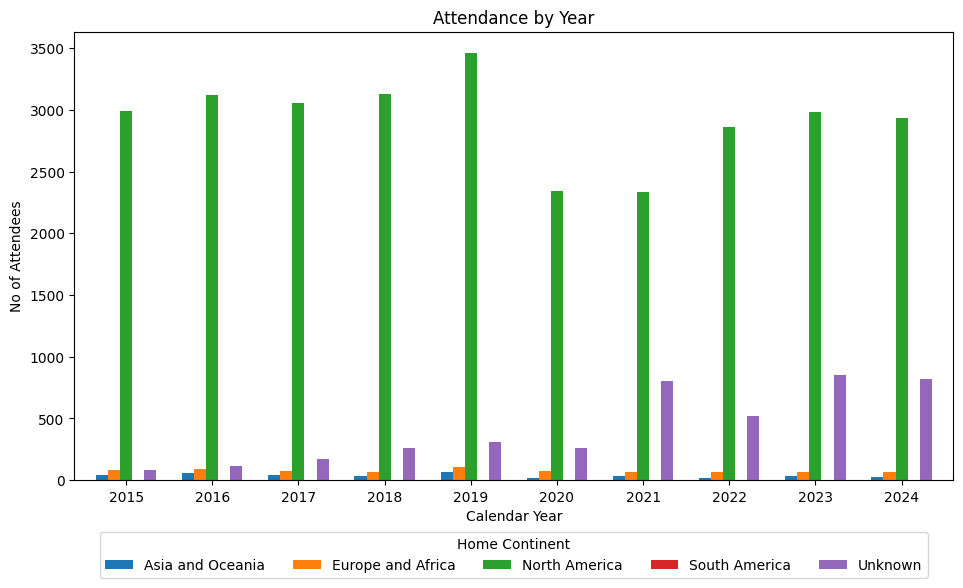

In [291]:
temp = primary_secondary.groupby(['year', 'Home_Continent'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Year')
plt.xlabel('Calendar Year')


plt.legend(title='Home Continent', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [292]:
%%markdown
### Attendance by Gender

### Attendance by Gender


In [293]:
primary_secondary['gender_1'] = primary_secondary['gender_1'].fillna('5. Unknown')
primary_secondary_1['gender_1'] = primary_secondary_1['gender_1'].fillna('5. Unknown')

In [294]:
#primary_secondary[primary_secondary.gender_1=='5. Unknown'].head(3)

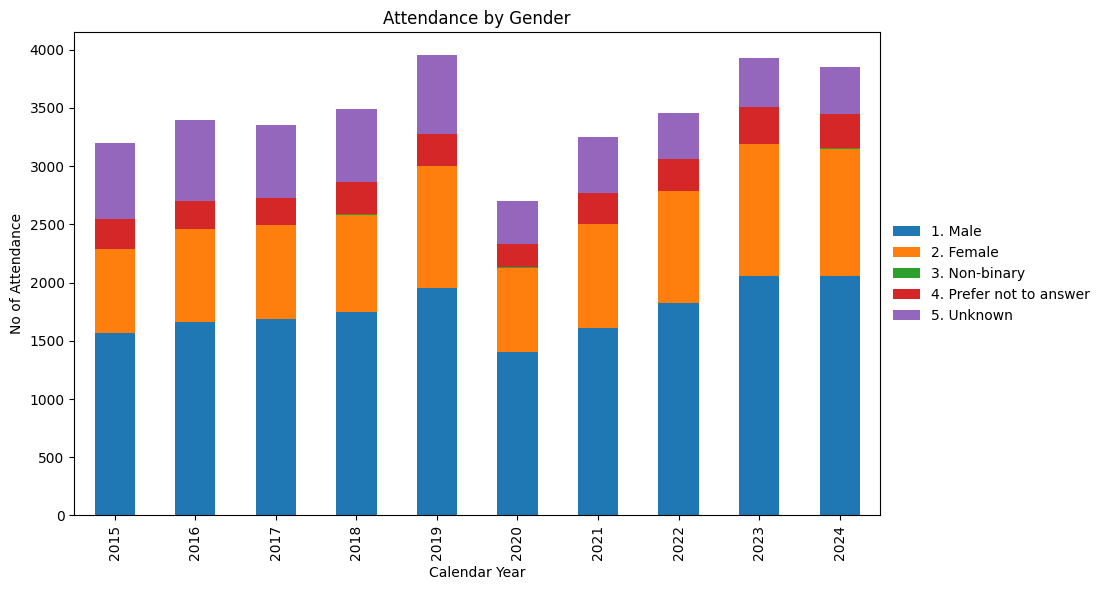

In [295]:
temp = primary_secondary.groupby(['year','gender_1'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Gender')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

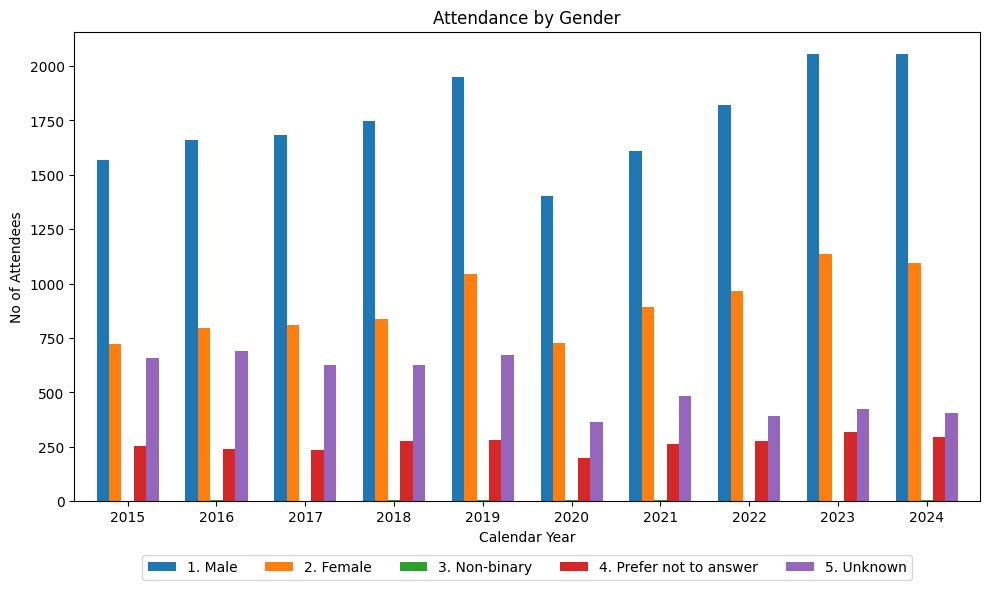

In [296]:
temp = primary_secondary.groupby(['year', 'gender_1'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Gender')
plt.xlabel('Calendar Year')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [297]:
%%markdown
#### Annual Meeting

#### Annual Meeting


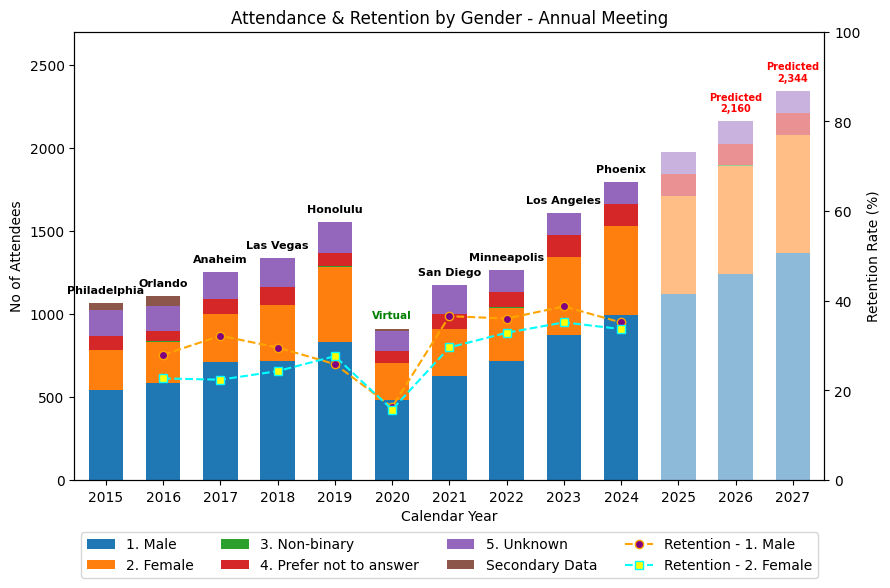

In [298]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'gender_1'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Annual_Meeting



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["1. Male"].values
y2 = df['2. Female'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"1. Male": future_preds_1.astype(int),
     '2. Female': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2024, "3. Non-binary"].mean()
avg_2 = temp.loc[2023:2024, "4. Prefer not to answer"].mean()
avg_3 = temp.loc[2023:2024, "5. Unknown"].mean()
temp.loc[2025:2027, "3. Non-binary"] = avg_1
temp.loc[2025:2027, "4. Prefer not to answer"] = avg_2
temp.loc[2025:2027, "5. Unknown"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'gender_1'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "1. Male": "orange",
    "2. Female": "cyan",
    "default": "blue"
}

markerface_colors ={
    "1. Male": "purple",
    "2. Female": "yellow",
    "default": "grey"
}

marker_style ={
    "1. Male": "o",
    "2. Female": "s",
    "default": "d"
}

skip_gender_groups = ["3. Non-binary", "4. Prefer not to answer", "5. Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_gender_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0), 
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0), 
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Gender - Annual Meeting')


ymax = 2700
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [299]:
print(temp)

      1. Male  2. Female  3. Non-binary  4. Prefer not to answer  5. Unknown  \
year                                                                           
2015      544        238            0.0                     85.0       157.0   
2016      584        250            2.0                     64.0       148.0   
2017      710        292            1.0                     85.0       166.0   
2018      715        340            2.0                    103.0       179.0   
2019      834        451            2.0                     83.0       185.0   
2020      484        223            1.0                     68.0       123.0   
2021      630        283            0.0                     87.0       172.0   
2022      715        324            1.0                     90.0       137.0   
2023      873        472            0.0                    130.0       134.0   
2024      996        532            1.0                    131.0       137.0   
2025     1119        592            0.5 

In [300]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


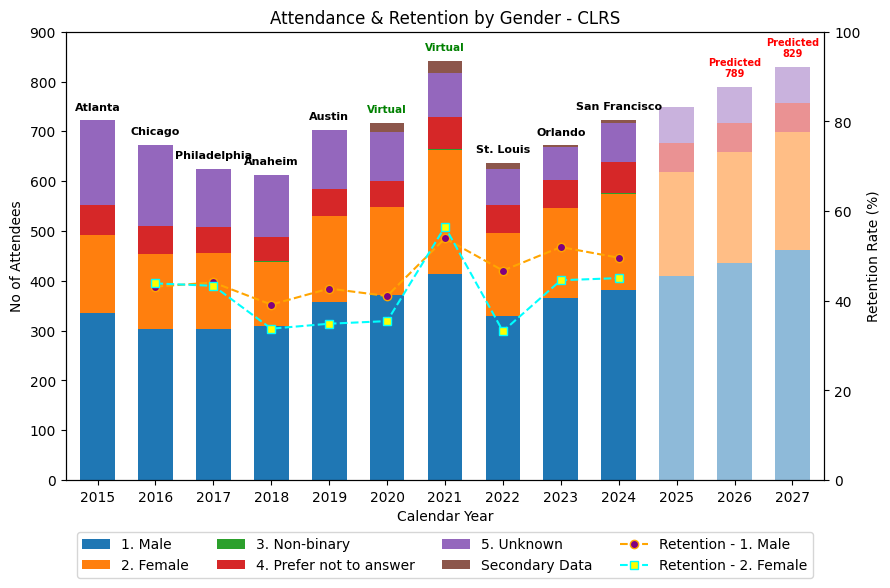

In [301]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'gender_1'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_CLRS



# regression 
df = temp[temp.index>=2022]
X = df.index.values.reshape(-1, 1)   
y1 = df["1. Male"].values
y2 = df['2. Female'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"1. Male": future_preds_1.astype(int),
     '2. Female': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2024, "3. Non-binary"].mean()
avg_2 = temp.loc[2022:2024, "4. Prefer not to answer"].mean()
avg_3 = temp.loc[2022:2024, "5. Unknown"].mean()
temp.loc[2025:2027, "3. Non-binary"] = avg_1
temp.loc[2025:2027, "4. Prefer not to answer"] = avg_2
temp.loc[2025:2027, "5. Unknown"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'gender_1'])['Customer_ID']
    .apply(set)
    .unstack() 
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "1. Male": "orange",
    "2. Female": "cyan",
    "default": "blue"
}

markerface_colors ={
    "1. Male": "purple",
    "2. Female": "yellow",
    "default": "grey"
}

marker_style ={
    "1. Male": "o",
    "2. Female": "s",
    "default": "d"
}

skip_gender_groups = ["3. Non-binary", "4. Prefer not to answer", "5. Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_gender_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0), 
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Gender - CLRS')


ymax = 900
ax.set_ylim(top=ymax)

#
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [302]:
print(temp)

      1. Male  2. Female  3. Non-binary  4. Prefer not to answer  5. Unknown  \
year                                                                           
2015      336        155       0.000000                61.000000  170.000000   
2016      304        150       0.000000                57.000000  162.000000   
2017      304        151       1.000000                52.000000  117.000000   
2018      309        129       1.000000                49.000000  124.000000   
2019      358        172       0.000000                55.000000  118.000000   
2020      371        177       1.000000                51.000000   98.000000   
2021      413        250       1.000000                64.000000   90.000000   
2022      329        166       0.000000                57.000000   73.000000   
2023      365        182       0.000000                56.000000   65.000000   
2024      381        194       1.000000                63.000000   77.000000   
2025      410        208       0.333333 

In [303]:
%%markdown
#### Spring Meeting

#### Spring Meeting


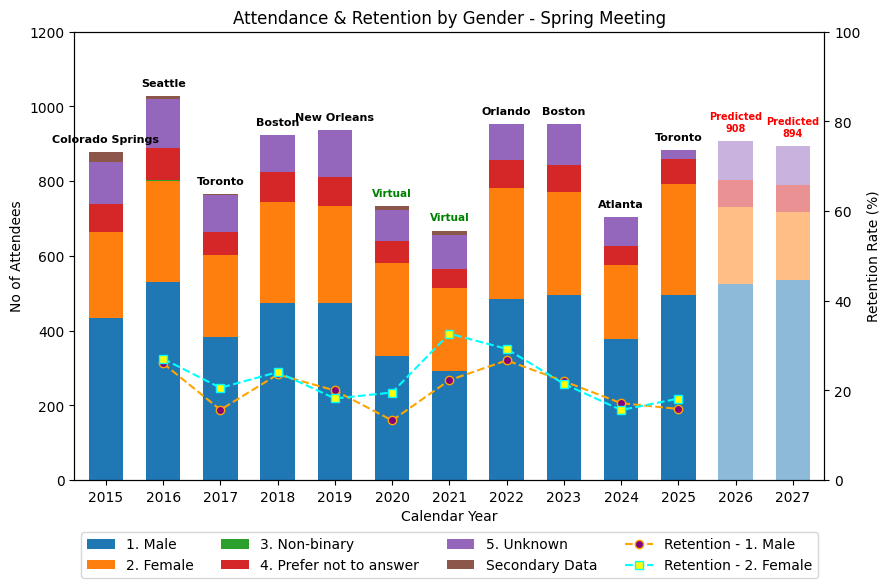

In [304]:
var = 'Spring Meeting'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'gender_1'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_Spring_Meeting



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2023)]
X = df.index.values.reshape(-1, 1)   
y1 = df["1. Male"].values
y2 = df['2. Female'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"1. Male": future_preds_1.astype(int),
     '2. Female': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2023, "3. Non-binary"].mean()
avg_2 = temp.loc[2022:2023, "4. Prefer not to answer"].mean()
avg_3 = temp.loc[2022:2023, "5. Unknown"].mean()
temp.loc[2026:2027, "3. Non-binary"] = avg_1
temp.loc[2026:2027, "4. Prefer not to answer"] = avg_2
temp.loc[2026:2027, "5. Unknown"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'gender_1'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "1. Male": "orange",
    "2. Female": "cyan",
    "default": "blue"
}

markerface_colors ={
    "1. Male": "purple",
    "2. Female": "yellow",
    "default": "grey"
}

marker_style ={
    "1. Male": "o",
    "2. Female": "s",
    "default": "d"
}

skip_gender_groups = ["3. Non-binary", "4. Prefer not to answer", "5. Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_gender_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Toronto"
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0), 
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Gender - Spring Meeting')


ymax = 1200
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [305]:
print(temp)

      1. Male  2. Female  3. Non-binary  4. Prefer not to answer  5. Unknown  \
year                                                                           
2015      434        229            0.0                     75.0       112.0   
2016      529        272            3.0                     84.0       132.0   
2017      382        220            0.0                     61.0       101.0   
2018      475        269            1.0                     80.0        99.0   
2019      473        261            0.0                     77.0       125.0   
2020      332        248            1.0                     58.0        83.0   
2021      292        222            1.0                     49.0        91.0   
2022      485        298            0.0                     73.0        96.0   
2023      495        275            0.0                     72.0       112.0   
2024      378        198            1.0                     50.0        78.0   
2025      495        298            0.0 

In [306]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


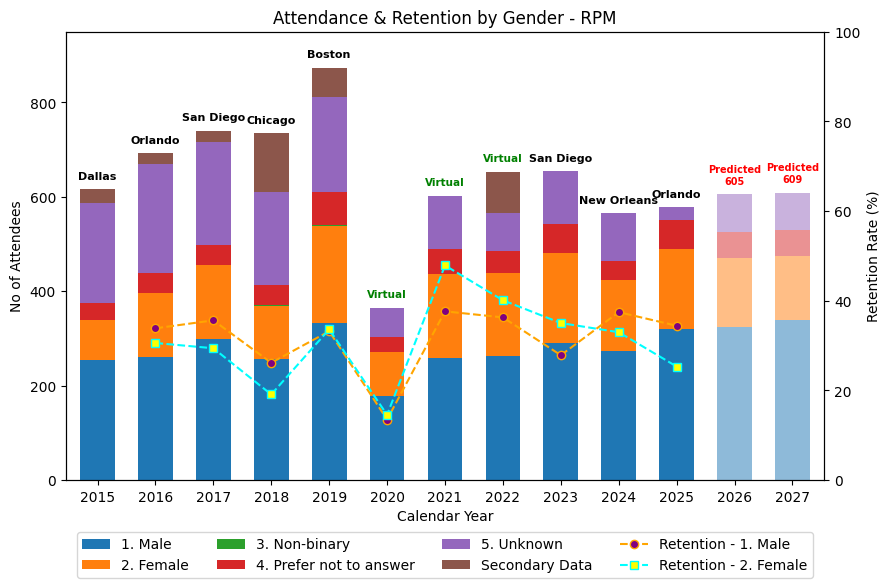

In [307]:
var = 'RPM'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'gender_1'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_RPM



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["1. Male"].values
y2 = df['2. Female'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"1. Male": future_preds_1.astype(int),
     '2. Female': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2025, "3. Non-binary"].mean()
avg_2 = temp.loc[2023:2025, "4. Prefer not to answer"].mean()
avg_3 = temp.loc[2023:2025, "5. Unknown"].mean()
avg_4 = temp.loc[2023:2025, "Secondary Data"].mean()
temp.loc[2026:2027, "3. Non-binary"] = avg_1
temp.loc[2026:2027, "4. Prefer not to answer"] = avg_2
temp.loc[2026:2027, "5. Unknown"] = avg_3
temp.loc[2026:2027, "Secondary Data"] = avg_4




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'gender_1'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "1. Male": "orange",
    "2. Female": "cyan",
    "default": "blue"
}

markerface_colors ={
    "1. Male": "purple",
    "2. Female": "yellow",
    "default": "grey"
}

marker_style ={
    "1. Male": "o",
    "2. Female": "s",
    "default": "d"
}

skip_gender_groups = ["3. Non-binary", "4. Prefer not to answer", "5. Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_gender_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Orlando"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Gender - RPM')


ymax = 950
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [308]:
print(temp)

      1. Male  2. Female  3. Non-binary  4. Prefer not to answer  5. Unknown  \
year                                                                           
2015      254         85       1.000000                36.000000  212.000000   
2016      261        136       0.000000                41.000000  231.000000   
2017      298        157       0.000000                43.000000  218.000000   
2018      256        113       1.000000                43.000000  198.000000   
2019      333        206       1.000000                70.000000  202.000000   
2020      178         94       0.000000                32.000000   61.000000   
2021      259        177       0.000000                53.000000  113.000000   
2022      262        177       0.000000                46.000000   80.000000   
2023      291        191       0.000000                60.000000  112.000000   
2024      273        150       1.000000                40.000000  101.000000   
2025      321        168       0.000000 

In [309]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


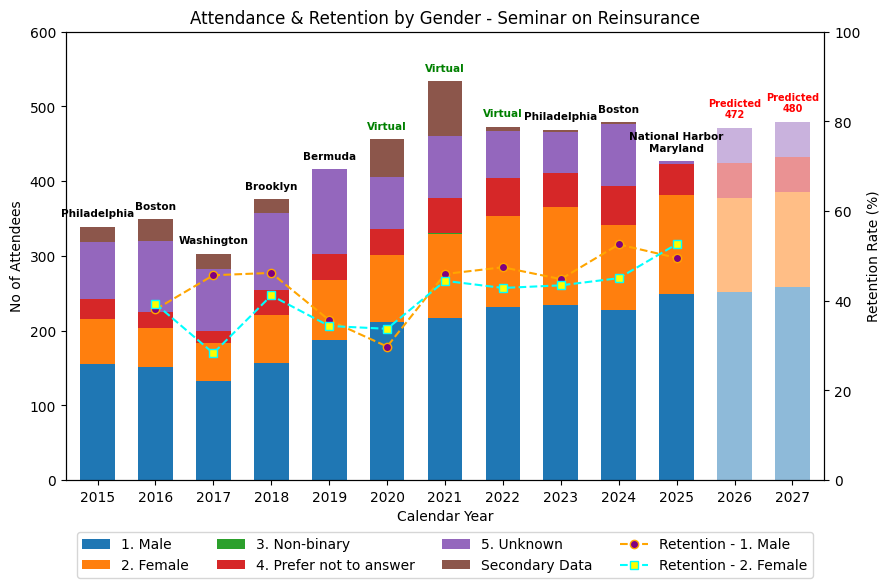

In [310]:
var = 'Reins Seminar'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'gender_1'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Reins_Seminar



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["1. Male"].values
y2 = df['2. Female'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"1. Male": future_preds_1.astype(int),
     '2. Female': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2025, "3. Non-binary"].mean()
avg_2 = temp.loc[2023:2025, "4. Prefer not to answer"].mean()
avg_3 = temp.loc[2023:2025, "5. Unknown"].mean()
temp.loc[2026:2027, "3. Non-binary"] = avg_1
temp.loc[2026:2027, "4. Prefer not to answer"] = avg_2
temp.loc[2026:2027, "5. Unknown"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'gender_1'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "1. Male": "orange",
    "2. Female": "cyan",
    "default": "blue"
}

markerface_colors ={
    "1. Male": "purple",
    "2. Female": "yellow",
    "default": "grey"
}

marker_style ={
    "1. Male": "o",
    "2. Female": "s",
    "default": "d"
}

skip_gender_groups = ["3. Non-binary", "4. Prefer not to answer", "5. Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_gender_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "National Harbor\nMaryland"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=7.5,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0),  
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Gender - Seminar on Reinsurance')


ymax = 600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [311]:
print(temp)

      1. Male  2. Female  3. Non-binary  4. Prefer not to answer  5. Unknown  \
year                                                                           
2015      155         61            0.0                27.000000   75.000000   
2016      151         53            0.0                21.000000   95.000000   
2017      132         51            0.0                17.000000   82.000000   
2018      157         64            0.0                33.000000  103.000000   
2019      188         80            0.0                35.000000  113.000000   
2020      211         90            0.0                35.000000   69.000000   
2021      217        112            1.0                47.000000   83.000000   
2022      232        122            0.0                50.000000   63.000000   
2023      234        131            0.0                46.000000   55.000000   
2024      228        114            0.0                51.000000   83.000000   
2025      249        132            0.0 

In [312]:
%%markdown
### Attendance by Age Group

### Attendance by Age Group


In [313]:
def get_age_group(age):
    if age <= 25:
        return '1. <=25'
    elif age <= 40:
        return '2. 26-40'
    elif age <= 55:
        return '3. 41-55'
    elif age <= 70:
        return '4. 56-70'
    elif age > 70:
        return '5. >70'     
    else:
        return 'Unknown'

#primary_secondary['Age'] = primary_secondary['year'] - primary_secondary['Birth_Year']
primary_secondary['Age_group'] = primary_secondary['Age'].map(get_age_group)
primary_secondary_1['Age_group'] = primary_secondary_1['Age'].map(get_age_group)

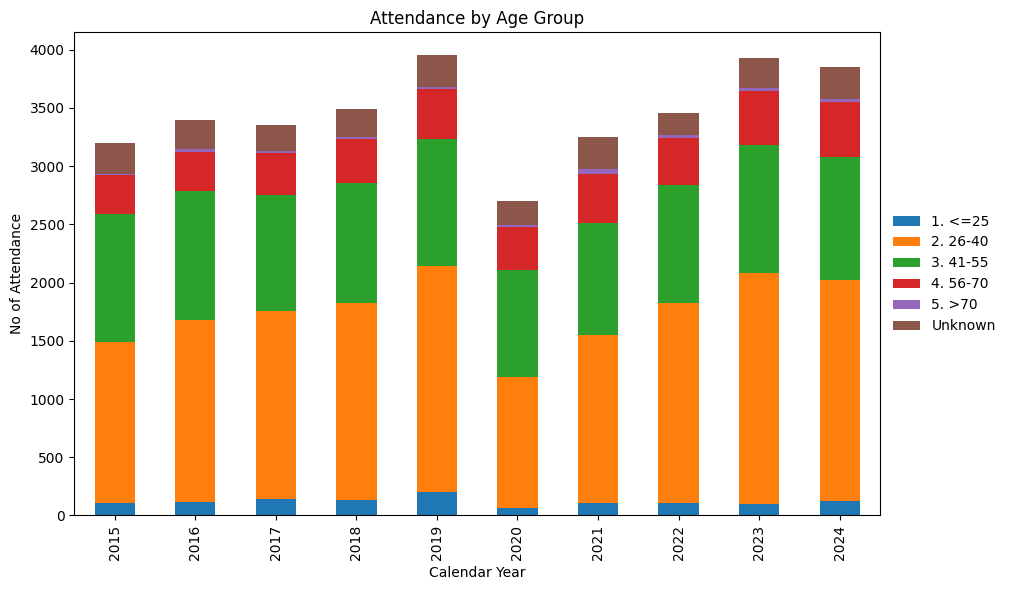

In [314]:
temp = primary_secondary.groupby(['year','Age_group'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Age Group')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

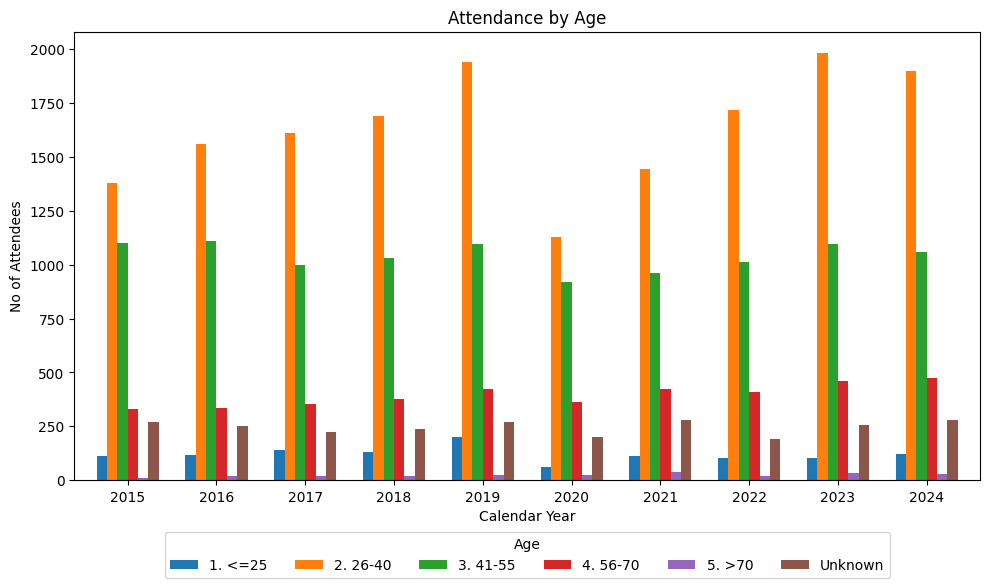

In [315]:
temp = primary_secondary.groupby(['year', 'Age_group'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Age')
plt.xlabel('Calendar Year')


plt.legend(title='Age', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=6)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [316]:
primary_secondary['Age_group'].isna().sum()

np.int64(0)

In [317]:
%%markdown
#### Annual Meeting

#### Annual Meeting


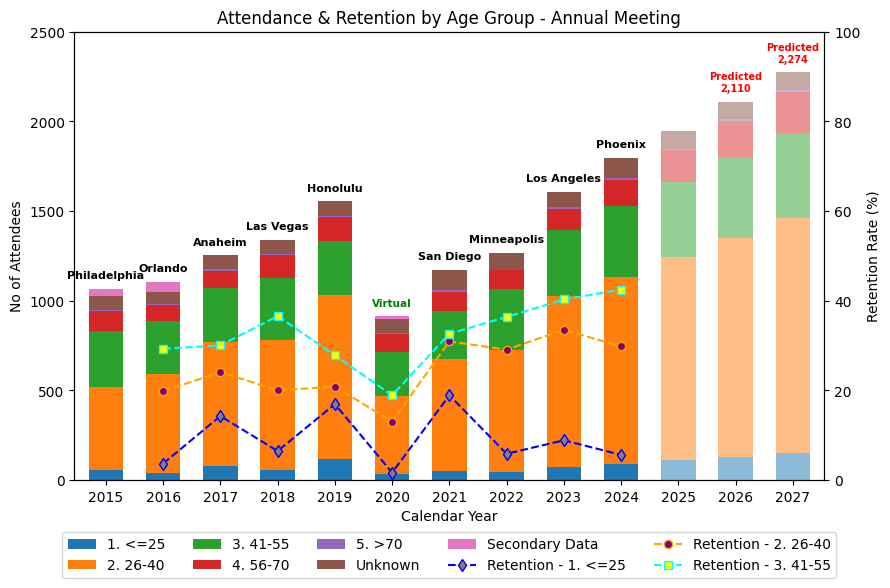

In [318]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Age_group'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_Annual_Meeting



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["2. 26-40"].values
y2 = df["3. 41-55"].values
y3 = df["4. 56-70"].values
y4 = df["1. <=25"].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model4 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)
model4.fit(X, y4)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)
future_preds_4 = model4.predict(future_years)

temp_future = pd.DataFrame(
    {"2. 26-40": future_preds_1.astype(int),
     "3. 41-55": future_preds_2.astype(int),
     "4. 56-70": future_preds_3.astype(int),
     "1. <=25": future_preds_4.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2024, "5. >70"].mean()
avg_2 = temp.loc[2023:2024, "Unknown"].mean()
avg_3 = temp.loc[2023:2024, "Secondary Data"].mean()
temp.loc[2025:2027, "5. >70"] = avg_1
temp.loc[2025:2027, "Unknown"] = avg_2
temp.loc[2025:2027, "Secondary Data"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Age_group'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "2. 26-40": "orange",
    "3. 41-55": "cyan",
    "default": "blue"
}

markerface_colors ={
    "2. 26-40": "purple",
    "3. 41-55": "yellow",
    "default": "grey"
}

marker_style ={
    "2. 26-40": "o",
    "3. 41-55": "s",
    "default": "d"
}

skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0), 
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Age Group - Annual Meeting')


ymax = 2500
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5
)

plt.tight_layout()
plt.show()


In [319]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


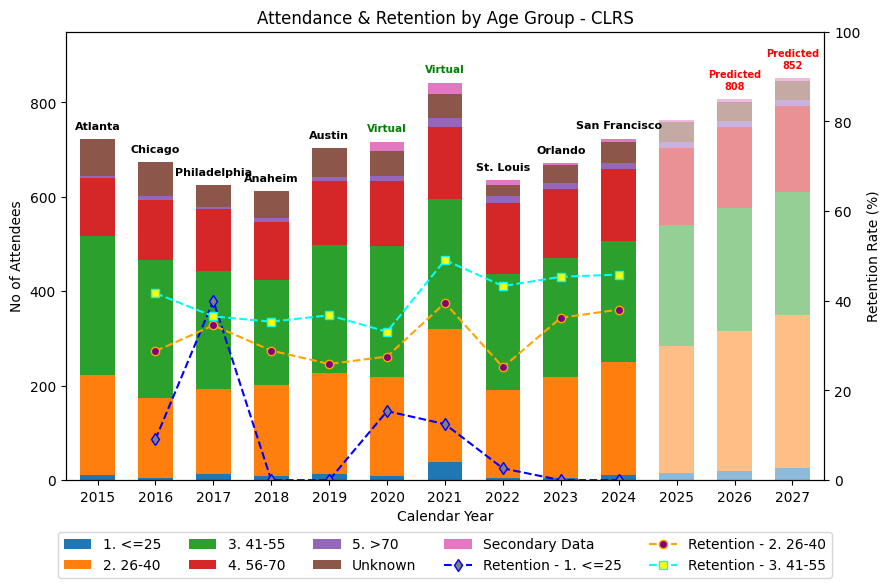

In [320]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Age_group'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_CLRS



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["2. 26-40"].values
y2 = df["3. 41-55"].values
y3 = df["4. 56-70"].values
y4 = df["1. <=25"].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model4 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)
model4.fit(X, y4)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)
future_preds_4 = model4.predict(future_years)

temp_future = pd.DataFrame(
    {"2. 26-40": future_preds_1.astype(int),
     "3. 41-55": future_preds_2.astype(int),
     "4. 56-70": future_preds_3.astype(int),
     "1. <=25": future_preds_4.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2024, "5. >70"].mean()
avg_2 = temp.loc[2023:2024, "Unknown"].mean()
avg_3 = temp.loc[2023:2024, "Secondary Data"].mean()
temp.loc[2025:2027, "5. >70"] = avg_1
temp.loc[2025:2027, "Unknown"] = avg_2
temp.loc[2025:2027, "Secondary Data"] = avg_3
#print(temp)



years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Age_group'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "2. 26-40": "orange",
    "3. 41-55": "cyan",
    "default": "blue"
}

markerface_colors ={
    "2. 26-40": "purple",
    "3. 41-55": "yellow",
    "default": "grey"
}

marker_style ={
    "2. 26-40": "o",
    "3. 41-55": "s",
    "default": "d"
}

skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0),  
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Age Group - CLRS')


ymax = 950
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5
)

plt.tight_layout()
plt.show()

In [321]:
print(temp)

      1. <=25  2. 26-40  3. 41-55  4. 56-70  5. >70  Unknown  Secondary Data
year                                                                        
2015       11       212       295       123     4.0     77.0             0.0
2016        5       168       293       127     9.0     71.0             0.0
2017       13       180       249       132     4.0     47.0             0.0
2018        8       193       223       123     8.0     57.0             0.0
2019       13       214       272       134     9.0     61.0             0.0
2020        8       210       279       136    11.0     54.0            19.0
2021       38       282       275       154    19.0     50.0            24.0
2022        5       185       247       150    14.0     24.0            11.0
2023        5       213       253       145    14.0     38.0             4.0
2024       10       241       255       154    11.0     45.0             7.0
2025       15       269       257       163    12.5     41.5             5.5

In [322]:
%%markdown
#### Spring Meeting

#### Spring Meeting


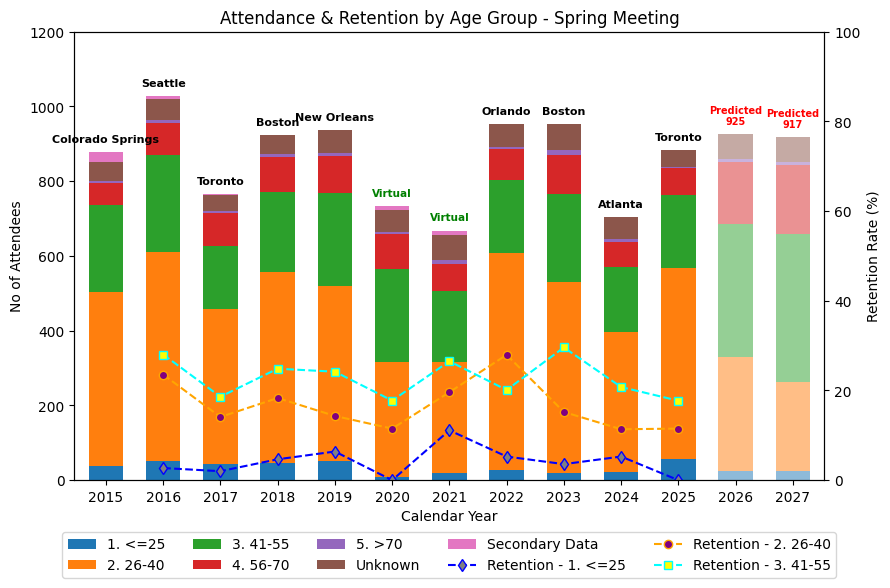

In [323]:
var = 'Spring Meeting'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Age_group'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Spring_Meeting



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2023)]
X = df.index.values.reshape(-1, 1)   
y1 = df["2. 26-40"].values
y2 = df["3. 41-55"].values
y3 = df["4. 56-70"].values
#y4 = df["1. <=25"].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
#model4 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)
#model4.fit(X, y4)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)
#future_preds_4 = model4.predict(future_years)

temp_future = pd.DataFrame(
    {"2. 26-40": future_preds_1.astype(int),
     "3. 41-55": future_preds_2.astype(int),
     "4. 56-70": future_preds_3.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2023, "5. >70"].mean()
avg_2 = temp.loc[2022:2023, "Unknown"].mean()
avg_3 = temp.loc[2022:2023, "Secondary Data"].mean()
avg_4 = temp.loc[2022:2023, "1. <=25"].mean()
temp.loc[2026:2027, "5. >70"] = avg_1
temp.loc[2026:2027, "Unknown"] = avg_2
temp.loc[2026:2027, "Secondary Data"] = avg_3
temp.loc[2026:2027, "1. <=25"] = avg_4




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Age_group'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "2. 26-40": "orange",
    "3. 41-55": "cyan",
    "default": "blue"
}

markerface_colors ={
    "2. 26-40": "purple",
    "3. 41-55": "yellow",
    "default": "grey"
}

marker_style ={
    "2. 26-40": "o",
    "3. 41-55": "s",
    "default": "d"
}

skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Toronto"
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0), 
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Age Group - Spring Meeting')


ymax = 1200
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5
)

plt.tight_layout()
plt.show()

In [324]:
print(temp)

      1. <=25  2. 26-40  3. 41-55  4. 56-70  5. >70  Unknown  Secondary Data
year                                                                        
2015     37.0       467       232        60     5.0     49.0            28.0
2016     50.0       561       258        88     7.0     56.0             8.0
2017     43.0       415       169        88     4.0     45.0             2.0
2018     47.0       510       215        94     7.0     51.0             0.0
2019     50.0       470       248       100     7.0     61.0             0.0
2020      9.0       306       249        95     5.0     58.0            12.0
2021     19.0       297       189        73    10.0     67.0            13.0
2022     28.0       579       196        84     5.0     60.0             0.0
2023     19.0       511       236       104    13.0     71.0             0.0
2024     22.0       374       175        65     9.0     60.0             0.0
2025     57.0       510       197        70     5.0     44.0             0.0

In [325]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


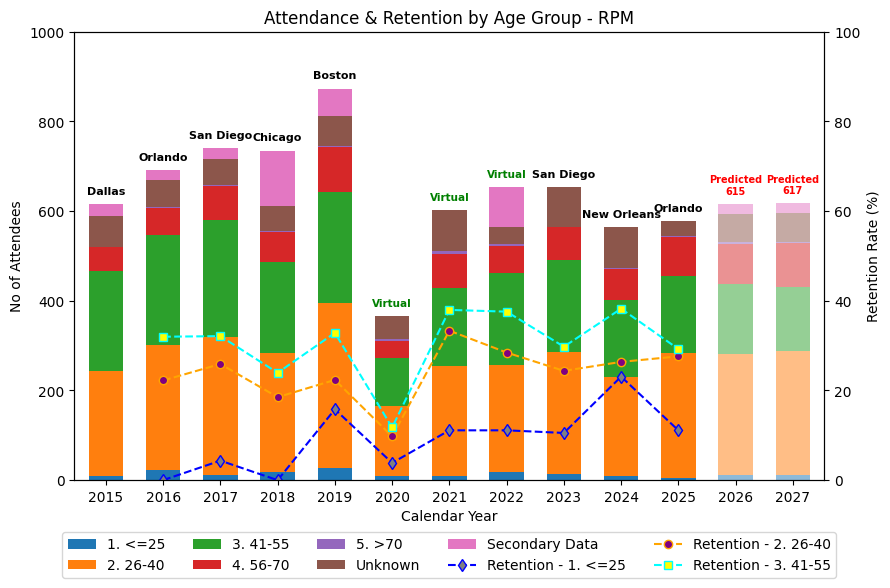

In [326]:
var = 'RPM'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Age_group'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_RPM



# regression 
df = temp[temp.index>=2022]
X = df.index.values.reshape(-1, 1)   
y1 = df["2. 26-40"].values
y2 = df["3. 41-55"].values
y3 = df["4. 56-70"].values
y4 = df["1. <=25"].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model4 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)
model4.fit(X, y4)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)
future_preds_4 = model4.predict(future_years)

temp_future = pd.DataFrame(
    {"2. 26-40": future_preds_1.astype(int),
     "3. 41-55": future_preds_2.astype(int),
     "4. 56-70": future_preds_3.astype(int)},
     #"1. <=25": future_preds_4.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2025, "5. >70"].mean()
avg_2 = temp.loc[2022:2025, "Unknown"].mean()
avg_3 = temp.loc[2022:2025, "Secondary Data"].mean()
avg_4 = temp.loc[2022:2025, "1. <=25"].mean()
temp.loc[2026:2027, "5. >70"] = avg_1
temp.loc[2026:2027, "Unknown"] = avg_2
temp.loc[2026:2027, "Secondary Data"] = avg_3
temp.loc[2026:2027, "1. <=25"] = avg_4




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Age_group'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "2. 26-40": "orange",
    "3. 41-55": "cyan",
    "default": "blue"
}

markerface_colors ={
    "2. 26-40": "purple",
    "3. 41-55": "yellow",
    "default": "grey"
}

marker_style ={
    "2. 26-40": "o",
    "3. 41-55": "s",
    "default": "d"
}

skip_age_groups = ["4. 56-70", "5. >70", "Unknown"] 

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Orlando"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0), 
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0), 
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Age Group - RPM')


ymax = 1000
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5
)

plt.tight_layout()
plt.show()

In [327]:
print(temp)

      1. <=25  2. 26-40  3. 41-55  4. 56-70  5. >70  Unknown  Secondary Data
year                                                                        
2015     10.0       234       222        53     1.0    68.00            28.0
2016     23.0       278       246        59     2.0    61.00            23.0
2017     12.0       308       259        76     4.0    57.00            24.0
2018     19.0       264       204        67     1.0    56.00           124.0
2019     26.0       369       247       101     3.0    66.00            61.0
2020      9.0       156       108        38     3.0    51.00             0.0
2021      9.0       246       173        77     6.0    91.00             0.0
2022     19.0       238       205        60     5.0    38.00            88.0
2023     13.0       273       204        74     1.0    89.00             0.0
2024      9.0       221       171        69     2.0    93.00             0.0
2025      5.0       278       173        87     2.0    33.00             0.0

In [328]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


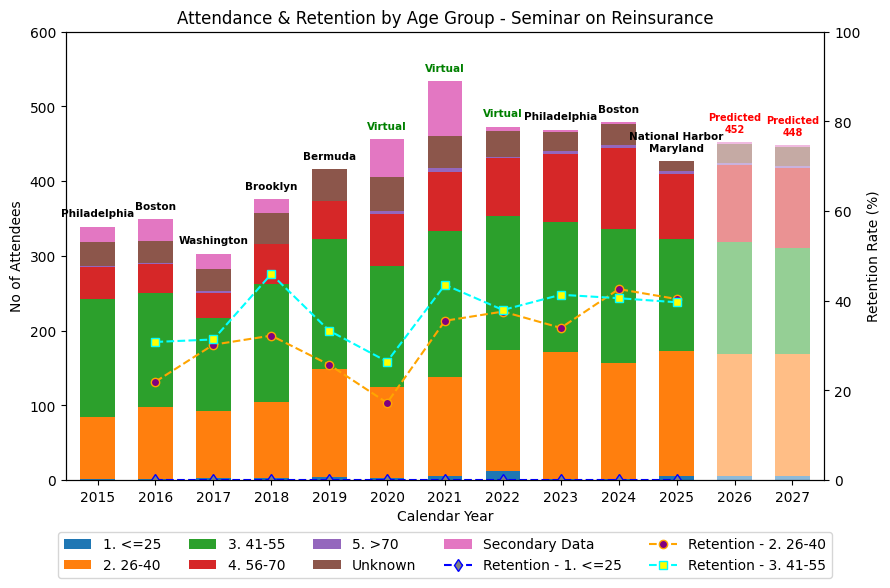

In [329]:
var = 'Reins Seminar'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Age_group'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Reins_Seminar



# regression 
df = temp[temp.index>=2022]
X = df.index.values.reshape(-1, 1)   
y1 = df["2. 26-40"].values
y2 = df["3. 41-55"].values
y3 = df["4. 56-70"].values
y4 = df["1. <=25"].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model4 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)
model4.fit(X, y4)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)
future_preds_4 = model4.predict(future_years)

temp_future = pd.DataFrame(
    {"2. 26-40": future_preds_1.astype(int),
     "3. 41-55": future_preds_2.astype(int),
     "4. 56-70": future_preds_3.astype(int)},
     #"1. <=25": future_preds_4.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2025, "5. >70"].mean()
avg_2 = temp.loc[2022:2025, "Unknown"].mean()
avg_3 = temp.loc[2022:2025, "Secondary Data"].mean()
avg_4 = temp.loc[2022:2025, "1. <=25"].mean()
temp.loc[2026:2027, "5. >70"] = avg_1
temp.loc[2026:2027, "Unknown"] = avg_2
temp.loc[2026:2027, "Secondary Data"] = avg_3
temp.loc[2026:2027, "1. <=25"] = avg_4




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Age_group'])['Customer_ID']
    .apply(set)
    .unstack() 
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "2. 26-40": "orange",
    "3. 41-55": "cyan",
    "default": "blue"
}

markerface_colors ={
    "2. 26-40": "purple",
    "3. 41-55": "yellow",
    "default": "grey"
}

marker_style ={
    "2. 26-40": "o",
    "3. 41-55": "s",
    "default": "d"
}

skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "National Harbor\nMaryland"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0), 
            city_label,
            ha='center',
            va='bottom',
            fontsize=7.5,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0),  
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Age Group - Seminar on Reinsurance')


ymax = 600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5
)

plt.tight_layout()
plt.show()

In [330]:
print(temp)

      1. <=25  2. 26-40  3. 41-55  4. 56-70  5. >70  Unknown  Secondary Data
year                                                                        
2015     2.00        82       159        42     1.0    32.00            21.0
2016     2.00        96       153        38     1.0    30.00            29.0
2017     3.00        90       124        34     2.0    29.00            21.0
2018     3.00       101       159        53     0.0    41.00            19.0
2019     4.00       145       174        50     1.0    42.00             0.0
2020     3.00       121       163        69     4.0    45.00            51.0
2021     5.00       133       195        79     6.0    42.00            74.0
2022    12.00       162       179        78     2.0    34.00             6.0
2023     2.00       169       175        91     3.0    26.00             3.0
2024     1.00       156       179       109     4.0    27.00             3.0
2025     6.00       167       150        87     3.0    14.00             0.0

In [331]:
%%markdown
### Attendance by Membership

### Attendance by Membership


In [332]:
primary_secondary['Membership'] = primary_secondary['Membership'].fillna('Unknown')
primary_secondary_1['Membership'] = primary_secondary_1['Membership'].fillna('Unknown')

In [333]:
#primary_secondary[(primary_secondary.year==2024)&(primary_secondary.Membership=='Unknown')&(primary_secondary.Age_group=='Unknown')].tail(3)

In [334]:
#primary_secondary[primary_secondary.Customer_ID=='000000290I']

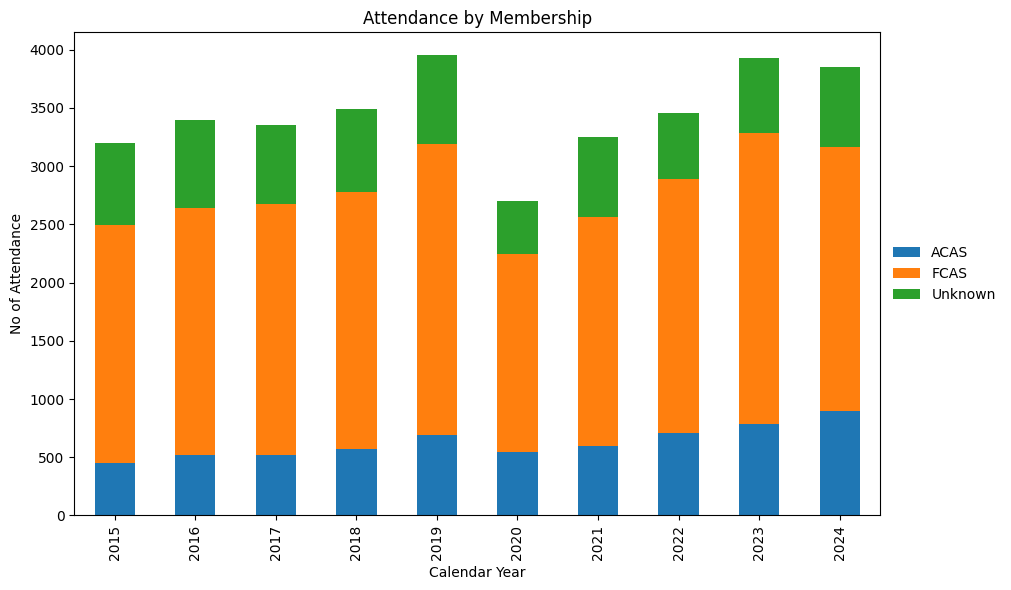

In [335]:
temp = primary_secondary.groupby(['year','Membership'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Membership')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

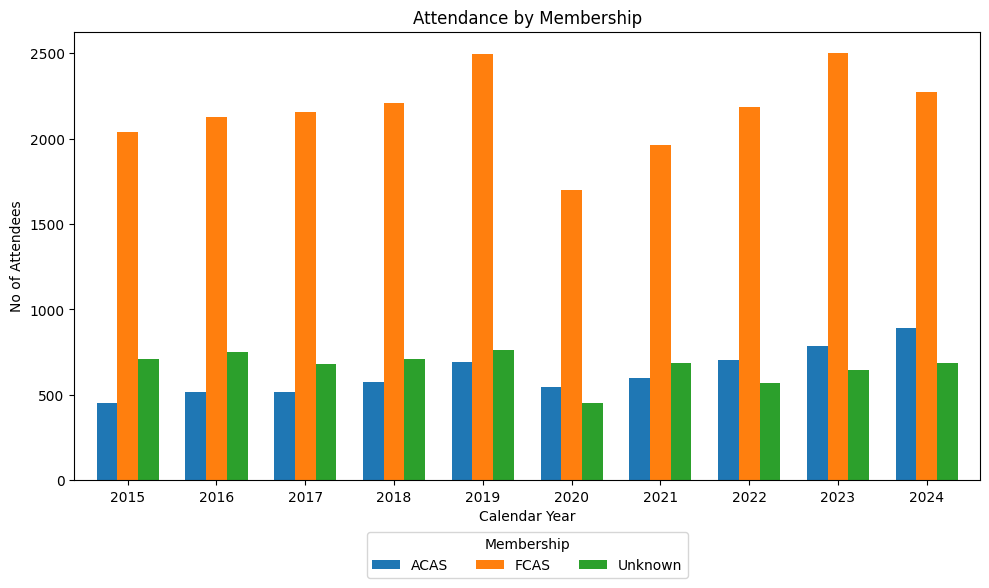

In [336]:
temp = primary_secondary.groupby(['year', 'Membership'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Membership')
plt.xlabel('Calendar Year')


plt.legend(title='Membership', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [337]:
%%markdown
#### Annual Meeting

#### Annual Meeting


In [338]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Membership'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0) 
)

In [339]:
 #primary_secondary[primary_secondary.Event_desc == var].tail(3)

In [340]:
#print(temp)

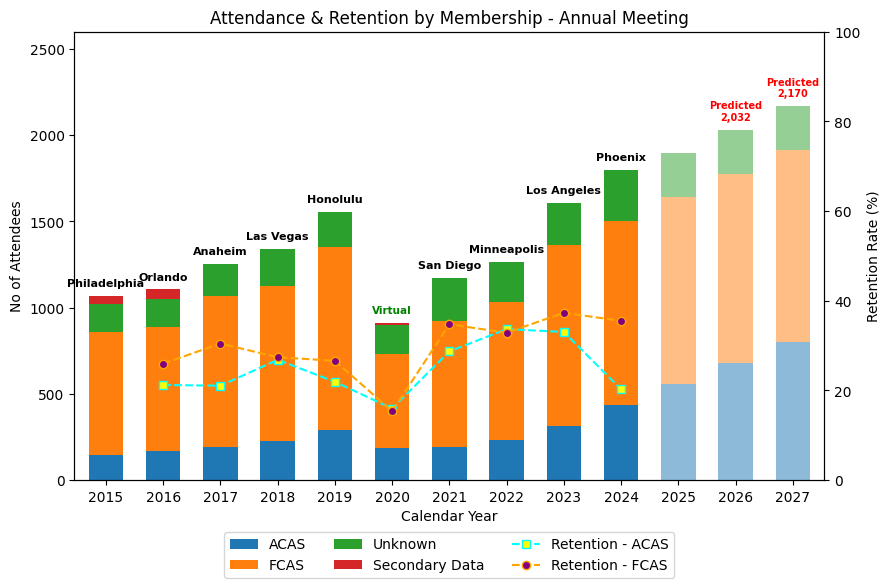

In [341]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Membership'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Annual_Meeting



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["ACAS"].values
y2 = df['FCAS'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"ACAS": future_preds_1.astype(int),
     'FCAS': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2021:2024, "Unknown"].mean()
temp.loc[2025:2027, "Unknown"] = avg_1




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Membership'])['Customer_ID']
    .apply(set)
    .unstack() 
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "FCAS": "orange",
    "ACAS": "cyan",
    "default": "blue"
}

markerface_colors ={
    "FCAS": "purple",
    "ACAS": "yellow",
    "default": "grey"
}

marker_style ={
    "FCAS": "o",
    "ACAS": "s",
    "default": "d"
}

#skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Membership - Annual Meeting')


ymax = 2600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [342]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


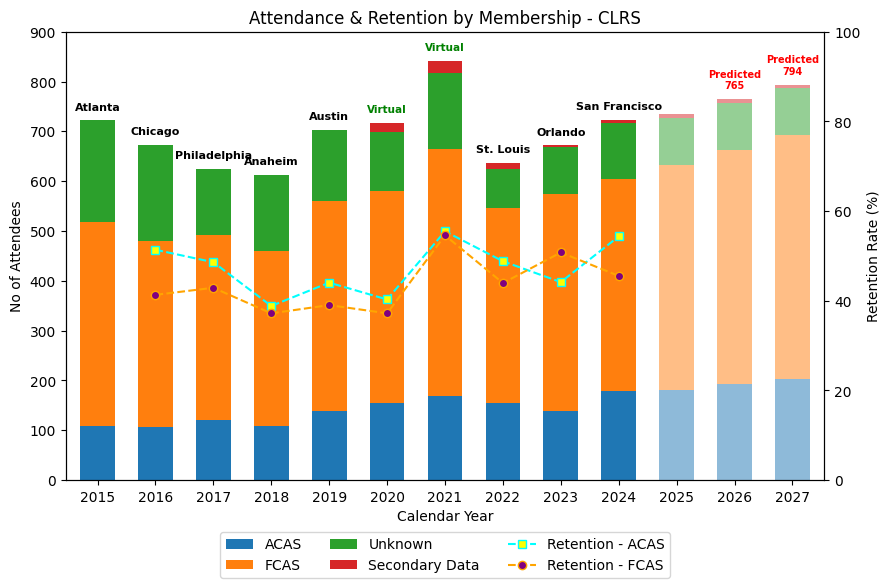

In [343]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Membership'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_CLRS



# regression 
df = temp[temp.index>=2022]
X = df.index.values.reshape(-1, 1)   
y1 = df["ACAS"].values
y2 = df['FCAS'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"ACAS": future_preds_1.astype(int),
     'FCAS': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2024, "Unknown"].mean()
avg_2 = temp.loc[2022:2024, 'Secondary Data'].mean()
temp.loc[2025:2027, "Unknown"] = avg_1
temp.loc[2025:2027, 'Secondary Data'] = avg_2



years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Membership'])['Customer_ID']
    .apply(set)
    .unstack() 
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "FCAS": "orange",
    "ACAS": "cyan",
    "default": "blue"
}

markerface_colors ={
    "FCAS": "purple",
    "ACAS": "yellow",
    "default": "grey"
}

marker_style ={
    "FCAS": "o",
    "ACAS": "s",
    "default": "d"
}

#skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0),  
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Membership - CLRS')


ymax = 900
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [344]:
%%markdown
#### Spring Meeting

#### Spring Meeting


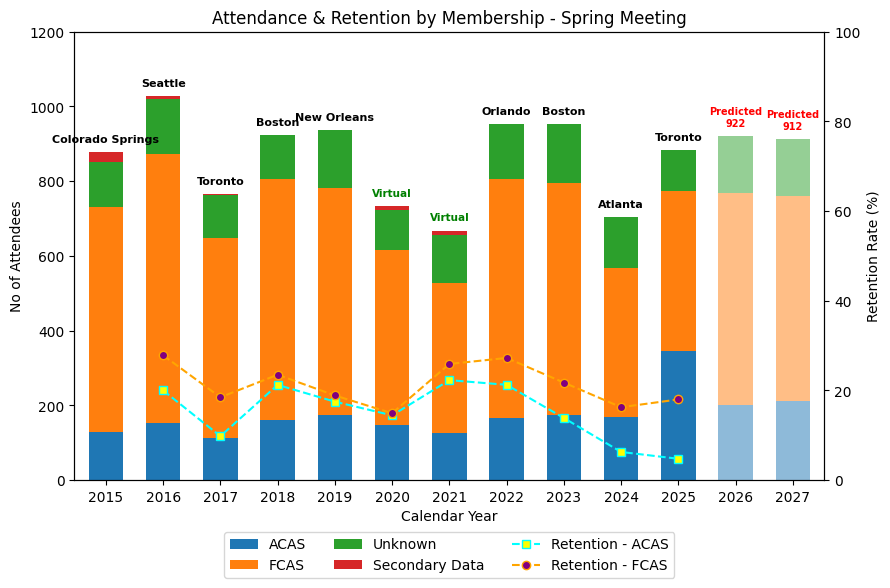

In [345]:
var = 'Spring Meeting'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Membership'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_Spring_Meeting



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2023)]
X = df.index.values.reshape(-1, 1)   
y1 = df["ACAS"].values
y2 = df['FCAS'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"ACAS": future_preds_1.astype(int),
     'FCAS': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2023, "Unknown"].mean()
temp.loc[2026:2027, "Unknown"] = avg_1




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()


x_pos = np.arange(len(years))




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Membership'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None

retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "FCAS": "orange",
    "ACAS": "cyan",
    "default": "blue"
}

markerface_colors ={
    "FCAS": "purple",
    "ACAS": "yellow",
    "default": "grey"
}

marker_style ={
    "FCAS": "o",
    "ACAS": "s",
    "default": "d"
}

#skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Toronto"
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Membership - Spring Meeting')


ymax = 1200
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [346]:
print(temp)

      ACAS  FCAS  Unknown  Secondary Data
year                                     
2015   130   600    120.0            28.0
2016   153   720    147.0             8.0
2017   113   536    115.0             2.0
2018   160   646    118.0             0.0
2019   173   610    153.0             0.0
2020   148   467    107.0            12.0
2021   127   400    128.0            13.0
2022   166   639    147.0             0.0
2023   175   621    158.0             0.0
2024   168   400    137.0             0.0
2025   346   428    109.0             0.0
2026   202   567    152.5             NaN
2027   211   549    152.5             NaN


In [347]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


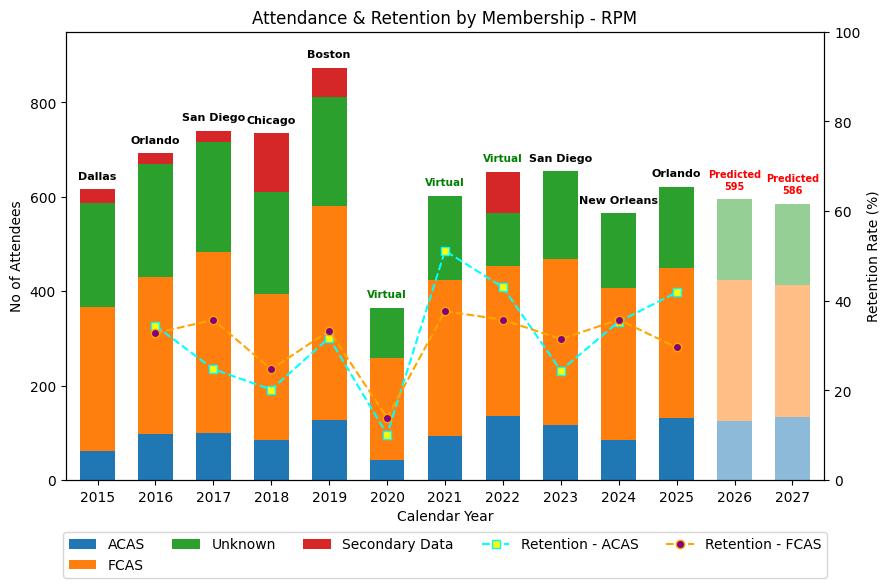

In [348]:
var = 'RPM'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Membership'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_RPM



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["ACAS"].values
y2 = df['FCAS'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"ACAS": future_preds_1.astype(int),
     'FCAS': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2024, "Unknown"].mean()
temp.loc[2025:2027, "Unknown"] = avg_1




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Membership'])['Customer_ID']
    .apply(set)
    .unstack() 
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "FCAS": "orange",
    "ACAS": "cyan",
    "default": "blue"
}

markerface_colors ={
    "FCAS": "purple",
    "ACAS": "yellow",
    "default": "grey"
}

marker_style ={
    "FCAS": "o",
    "ACAS": "s",
    "default": "d"
}

#skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Orlando"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Membership - RPM')


ymax = 950
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5
)

plt.tight_layout()
plt.show()

In [349]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


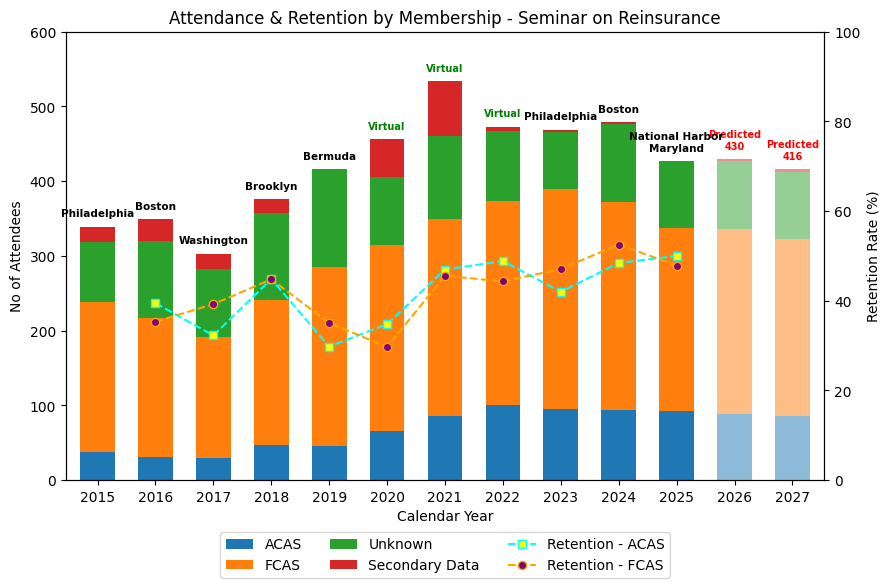

In [350]:
var = 'Reins Seminar'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Membership'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Reins_Seminar



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2025)]
X = df.index.values.reshape(-1, 1)   
y1 = df["ACAS"].values
y2 = df['FCAS'].values

model1 = LinearRegression()
model2 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)


temp_future = pd.DataFrame(
    {"ACAS": future_preds_1.astype(int),
     'FCAS': future_preds_2.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2025, "Unknown"].mean()
avg_2 = temp.loc[2022:2025, "Secondary Data"].mean()
temp.loc[2026:2027, "Unknown"] = avg_1
temp.loc[2026:2027, "Secondary Data"] = avg_2



years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Membership'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "FCAS": "orange",
    "ACAS": "cyan",
    "default": "blue"
}

markerface_colors ={
    "FCAS": "purple",
    "ACAS": "yellow",
    "default": "grey"
}

marker_style ={
    "FCAS": "o",
    "ACAS": "s",
    "default": "d"
}

#skip_age_groups = ["4. 56-70", "5. >70", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_age_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "National Harbor\nMaryland"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
            city_label,
            ha='center',
            va='bottom',
            fontsize=7.5,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
        city_label,
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Membership - Seminar on Reinsurance')


ymax = 600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [351]:
print(temp)

      ACAS  FCAS  Unknown  Secondary Data
year                                     
2015    38   201    79.00            21.0
2016    31   186   103.00            29.0
2017    29   163    90.00            21.0
2018    47   194   116.00            19.0
2019    46   239   131.00             0.0
2020    66   248    91.00            51.0
2021    86   264   110.00            74.0
2022   100   274    93.00             6.0
2023    95   295    76.00             3.0
2024    94   278   104.00             3.0
2025    92   245    90.00             0.0
2026    89   247    90.75             3.0
2027    86   236    90.75             3.0


In [352]:
%%markdown
### Attendance by Career Stage

### Attendance by Career Stage


In [353]:
primary_secondary['Seniority'] = primary_secondary['Seniority'].fillna('Unknown')
primary_secondary_1['Seniority'] = primary_secondary_1['Seniority'].fillna('Unknown')

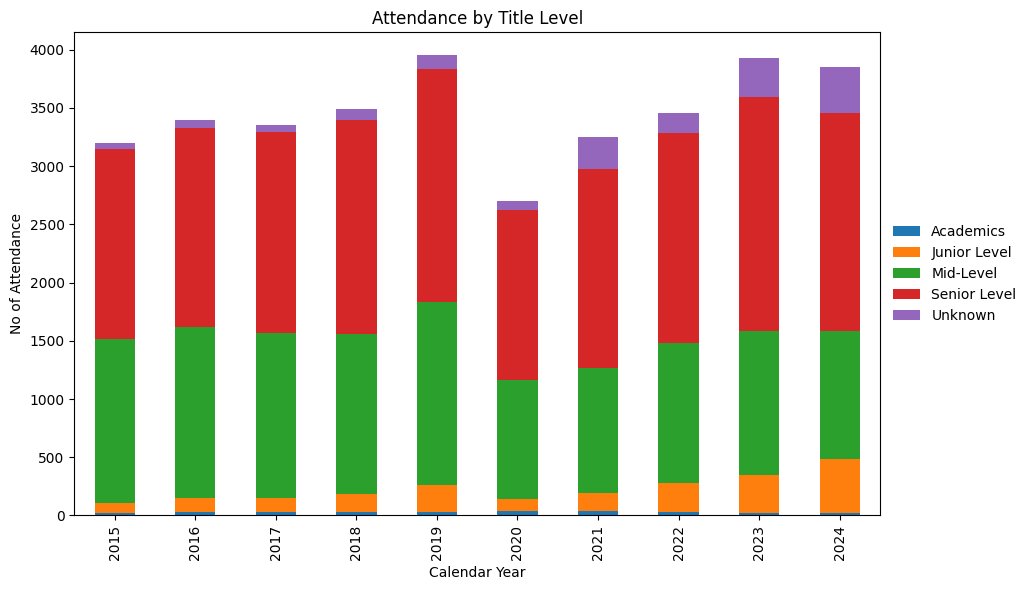

In [354]:
temp = primary_secondary.groupby(['year','Seniority'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Title Level')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

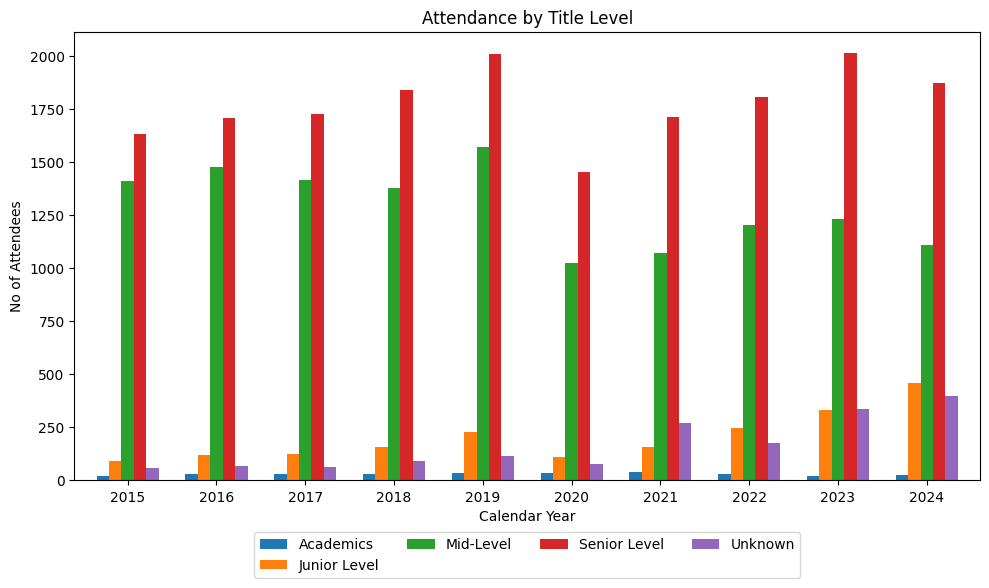

In [355]:
temp = primary_secondary.groupby(['year', 'Seniority'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Title Level')
plt.xlabel('Calendar Year')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [356]:
%%markdown
#### Annual Meeting

#### Annual Meeting


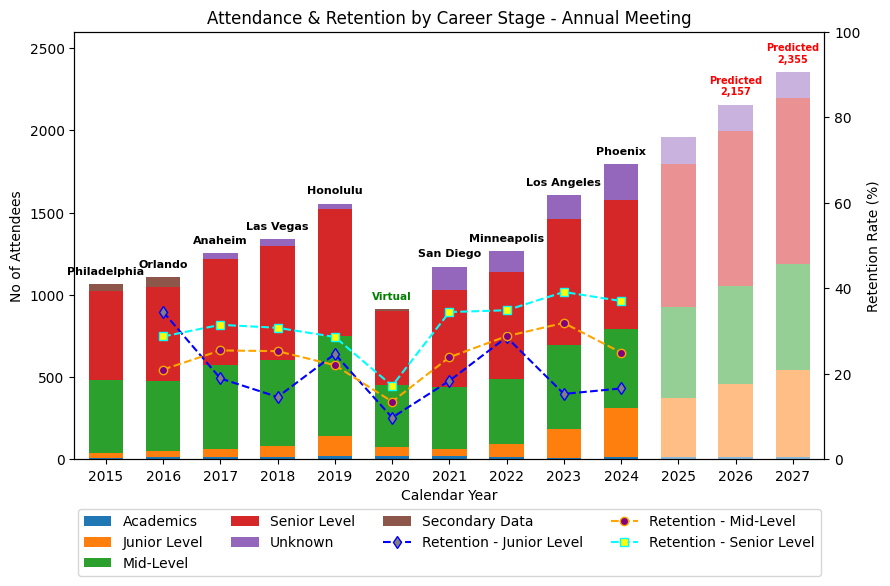

In [357]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Seniority'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Annual_Meeting



# regression 
df = temp[temp.index>=2021]
X = df.index.values.reshape(-1, 1)   
y1 = df["Junior Level"].values
y2 = df['Mid-Level'].values
y3 = df['Senior Level'].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)


temp_future = pd.DataFrame(
    {"Junior Level": future_preds_1.astype(int),
     'Mid-Level': future_preds_2.astype(int),  
     'Senior Level': future_preds_3.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2021:2024, "Academics"].mean()
avg_2 = temp.loc[2021:2024, "Unknown"].mean()
avg_3 = temp.loc[2021:2024, "Secondary Data"].mean()
temp.loc[2025:2027, "Academics"] = avg_1
temp.loc[2025:2027, "Unknown"] = avg_2
temp.loc[2025:2027, "Secondary Data"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Seniority'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Mid-Level": "orange",
    "Senior Level": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Mid-Level": "purple",
    "Senior Level": "yellow",
    "default": "grey"
}

marker_style ={
    "Mid-Level": "o",
    "Senior Level": "s",
    "default": "d"
}

skip_level_groups = ["Academics", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_level_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Career Stage - Annual Meeting')


ymax = 2600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [358]:
print(temp)

      Academics  Junior Level  Mid-Level  Senior Level  Unknown  \
year                                                              
2015       8.00            29        443           543     1.00   
2016      14.00            37        428           569     0.00   
2017      12.00            48        514           647    33.00   
2018      14.00            69        518           699    39.00   
2019      20.00           123        608           774    30.00   
2020      23.00            49        377           450     0.00   
2021      22.00            42        375           588   145.00   
2022      11.00            85        395           649   127.00   
2023       8.00           175        513           767   146.00   
2024      14.00           296        483           781   223.00   
2025      13.75           362        552           870   160.25   
2026      13.75           447        596           940   160.25   
2027      13.75           532        640          1009   160.2

In [359]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


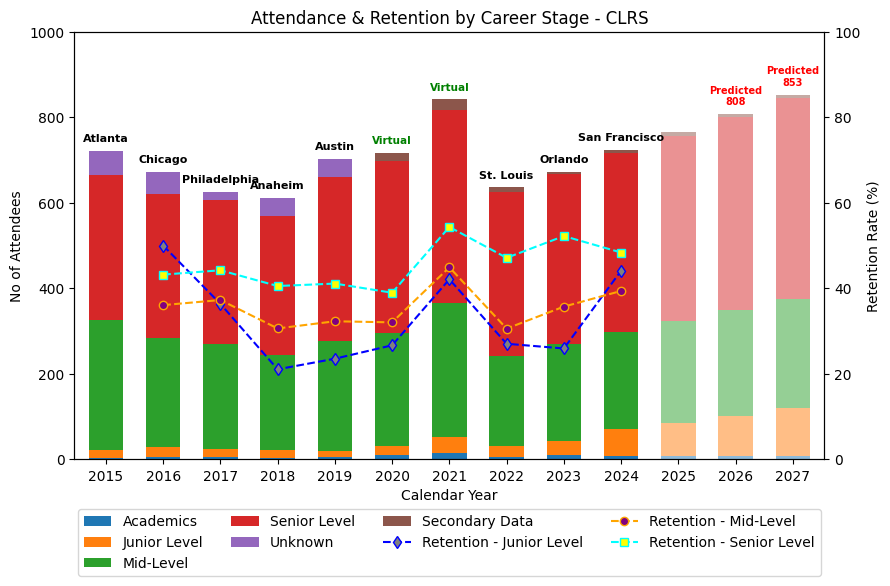

In [360]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Seniority'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index() 
)
temp['Secondary Data'] = fix_CLRS



# regression 
df = temp[temp.index>=2022]
X = df.index.values.reshape(-1, 1)   
y1 = df["Junior Level"].values
y2 = df['Mid-Level'].values
y3 = df['Senior Level'].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)

future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)


temp_future = pd.DataFrame(
    {"Junior Level": future_preds_1.astype(int),
     'Mid-Level': future_preds_2.astype(int),  
     'Senior Level': future_preds_3.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2024, "Academics"].mean()
avg_2 = temp.loc[2022:2024, "Unknown"].mean()
avg_3 = temp.loc[2022:2024, "Secondary Data"].mean()
temp.loc[2025:2027, "Academics"] = avg_1
temp.loc[2025:2027, "Unknown"] = avg_2
temp.loc[2025:2027, "Secondary Data"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2025, 2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )





x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Seniority'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Mid-Level": "orange",
    "Senior Level": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Mid-Level": "purple",
    "Senior Level": "yellow",
    "default": "grey"
}

marker_style ={
    "Mid-Level": "o",
    "Senior Level": "s",
    "default": "d"
}

skip_level_groups = ["Academics", "Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_level_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0), 
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0),  
        city_label,
        ha='center',
        va='bottom',
        fontsize=7.5,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Career Stage - CLRS')


ymax = 1000
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [361]:
print(temp)

      Academics  Junior Level  Mid-Level  Senior Level  Unknown  \
year                                                              
2015   2.000000            20        305           338     57.0   
2016   6.000000            22        255           337     53.0   
2017   5.000000            19        245           338     18.0   
2018   4.000000            17        223           326     42.0   
2019   5.000000            15        256           385     42.0   
2020  11.000000            19        265           403      0.0   
2021  14.000000            37        314           452      1.0   
2022   5.000000            27        210           383      0.0   
2023   9.000000            34        226           399      0.0   
2024   8.000000            63        227           418      0.0   
2025   7.333333            77        238           435      0.0   
2026   7.333333            95        246           452      0.0   
2027   7.333333           113        255           470      0.

In [362]:
%%markdown
#### Spring Meeting

#### Spring Meeting


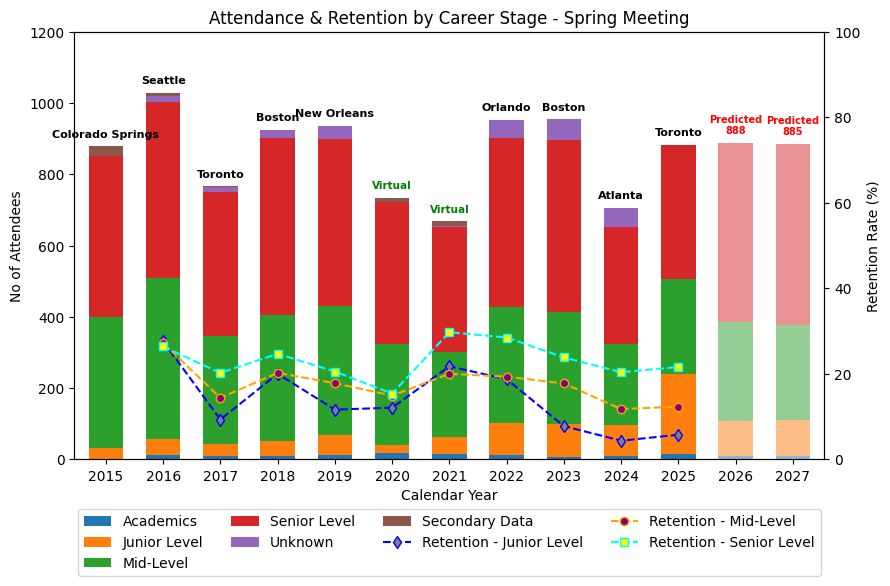

In [363]:
var = 'Spring Meeting'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Seniority'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Spring_Meeting



# regression 
df = temp[(temp.index>=2022)&(temp.index<=2023)]
X = df.index.values.reshape(-1, 1)   
y1 = df["Junior Level"].values
y2 = df['Mid-Level'].values
y3 = df['Senior Level'].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)


temp_future = pd.DataFrame(
    {"Junior Level": future_preds_1.astype(int),
     'Mid-Level': future_preds_2.astype(int),  
     'Senior Level': future_preds_3.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2022:2023, "Academics"].mean()
#avg_2 = temp.loc[2022:2023, "Unknown"].mean()
avg_3 = temp.loc[2022:2023, "Secondary Data"].mean()
temp.loc[2026:2027, "Academics"] = avg_1
#temp.loc[2026:2027, "Unknown"] = avg_2
temp.loc[2026:2027, "Secondary Data"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()


x_pos = np.arange(len(years))




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Seniority'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Mid-Level": "orange",
    "Senior Level": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Mid-Level": "purple",
    "Senior Level": "yellow",
    "default": "grey"
}

marker_style ={
    "Mid-Level": "o",
    "Senior Level": "s",
    "default": "d"
}

skip_level_groups = ["Academics", "Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_level_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Toronto"
city_per_year.loc[2020:2021] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Career Stage - Spring Meeting')


ymax = 1200
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [364]:
print(temp)

      Academics  Junior Level  Mid-Level  Senior Level  Unknown  \
year                                                              
2015        2.0            29        368           451      0.0   
2016       13.0            43        452           495     17.0   
2017        8.0            35        302           405     14.0   
2018        9.0            43        354           497     21.0   
2019       11.0            58        362           468     37.0   
2020       17.0            23        285           397      0.0   
2021       16.0            48        238           351      2.0   
2022       11.0            90        327           474     50.0   
2023        7.0            92        315           481     59.0   
2024        9.0            87        227           329     53.0   
2025       14.0           225        266           378      0.0   
2026        9.0            98        279           502      NaN   
2027        9.0           100        267           509      Na

In [365]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


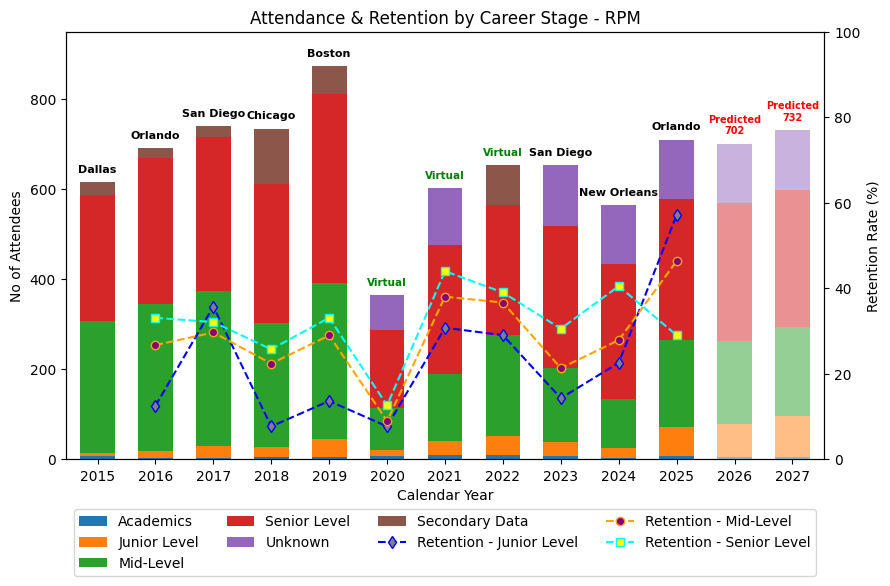

In [366]:
var = 'RPM'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Seniority'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_RPM



# regression 
df = temp[temp.index>=2023]
X = df.index.values.reshape(-1, 1)   
y1 = df["Junior Level"].values
y2 = df['Mid-Level'].values
y3 = df['Senior Level'].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)


temp_future = pd.DataFrame(
    {"Junior Level": future_preds_1.astype(int),
     'Mid-Level': future_preds_2.astype(int),  
     'Senior Level': future_preds_3.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2023:2025, "Academics"].mean()
avg_2 = temp.loc[2023:2024, "Unknown"].mean()
avg_3 = temp.loc[2023:2025, "Secondary Data"].mean()
#avg_4 = temp.loc[2023:2025, "Mid-Level"].mean()
temp.loc[2026:2027, "Academics"] = avg_1
temp.loc[2025:2027, "Unknown"] = avg_2
temp.loc[2026:2027, "Secondary Data"] = avg_3
#temp.loc[2026:2027, "Mid-Level"] = avg_4



years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Seniority'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Mid-Level": "orange",
    "Senior Level": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Mid-Level": "purple",
    "Senior Level": "yellow",
    "default": "grey"
}

marker_style ={
    "Mid-Level": "o",
    "Senior Level": "s",
    "default": "d"
}

skip_level_groups = ["Academics", "Unknown"]   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_level_groups:
        continue  
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "Orlando"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
            city_label,
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
    	ax.text(
    	i,
    	total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
    	city_label,
    	ha='center',
    	va='bottom',
    	fontsize=7.5,
    	fontweight='bold',
    	color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Career Stage - RPM')


ymax = 950
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [367]:
print(temp)

      Academics  Junior Level  Mid-Level  Senior Level  Unknown  \
year                                                              
2015        7.0             8        292           281      0.0   
2016        4.0            14        327           324      0.0   
2017        4.0            26        344           342      0.0   
2018        5.0            22        276           308      0.0   
2019        6.0            39        346           420      1.0   
2020        8.0            13         92           175     77.0   
2021        9.0            31        150           287    125.0   
2022        9.0            42        225           288      1.0   
2023        7.0            31        165           316    135.0   
2024        4.0            21        110           300    130.0   
2025        7.0            65        193           313    132.5   
2026        6.0            73        184           306    132.5   
2027        6.0            90        198           305    132.

In [368]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


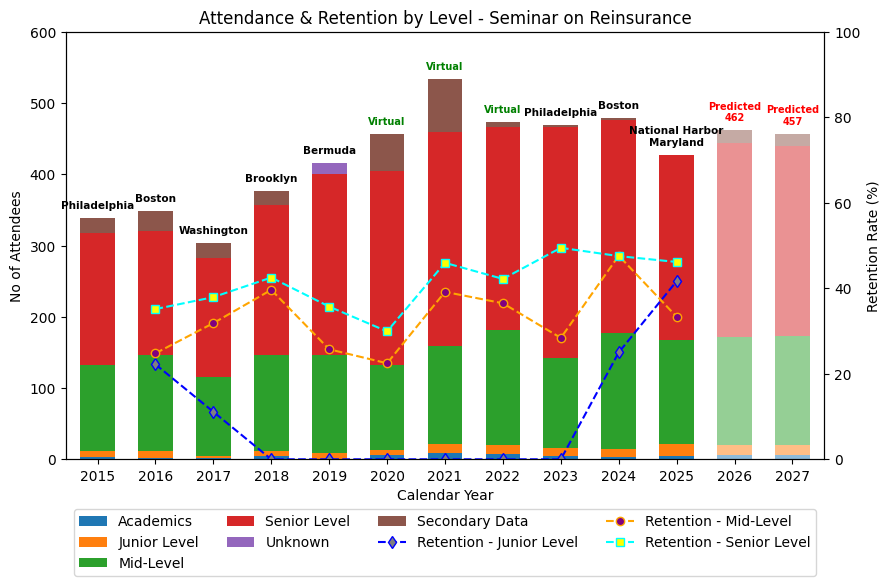

In [369]:
var = 'Reins Seminar'


temp = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Seniority'], dropna=False)['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)
temp['Secondary Data'] = fix_Reins_Seminar



# regression 
df = temp[temp.index>=2021]
X = df.index.values.reshape(-1, 1)   
y1 = df["Junior Level"].values
y2 = df['Mid-Level'].values
y3 = df['Senior Level'].values

model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model1.fit(X, y1)
model2.fit(X, y2)
model3.fit(X, y3)

future_years = np.array([2026, 2027]).reshape(-1, 1)
future_preds_1 = model1.predict(future_years)
future_preds_2 = model2.predict(future_years)
future_preds_3 = model3.predict(future_years)


temp_future = pd.DataFrame(
    {"Junior Level": future_preds_1.astype(int),
     'Mid-Level': future_preds_2.astype(int),  
     'Senior Level': future_preds_3.astype(int)},  
    index=future_years.flatten()
)
temp_future.index.name = "year"
temp = pd.concat([temp, temp_future])

# use average
avg_1 = temp.loc[2021:2025, "Academics"].mean()
#avg_2 = temp.loc[2023:2024, "Unknown"].mean()
avg_3 = temp.loc[2021:2025, "Secondary Data"].mean()
temp.loc[2026:2027, "Academics"] = avg_1
#temp.loc[2025:2027, "Unknown"] = avg_2
temp.loc[2026:2027, "Secondary Data"] = avg_3




years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()




for container in ax.containers:
    for rect, bar_year in zip(container, temp.index):
        if bar_year in [2026, 2027]:
            rect.set_alpha(0.5)


for i, year in enumerate(temp.index):
    if year in [2026, 2027]:
        total = attendees[i]
        ax.text(
            i,                                    
            total + 0.02 * max(attendees),        
            f"Predicted\n{total:,.0f}",           
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            color='red'
        )




x_pos = np.arange(len(years))


cust_by_year_delivery = (
    primary_secondary_1[primary_secondary_1.Event_desc == var]
    .groupby(['year', 'Seniority'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Mid-Level": "orange",
    "Senior Level": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Mid-Level": "purple",
    "Senior Level": "yellow",
    "default": "grey"
}

marker_style ={
    "Mid-Level": "o",
    "Senior Level": "s",
    "default": "d"
}

skip_level_groups = ["Academics", "Unknown"]  

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_level_groups:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)
city_per_year.loc[2025] = "National Harbor\nMaryland"
city_per_year.loc[2020:2022] = "Virtual"


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    if year not in [2020, 2021, 2022]:
        ax.text(
            i,
            total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
            city_label,
            ha='center',
            va='bottom',
            fontsize=7.5,
            fontweight='bold'
        )
    elif year in [2020, 2021, 2022]:
        ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0),  # slightly above the bar
        city_label,
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold',
        color = 'green'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Level - Seminar on Reinsurance')


ymax = 600
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4
)

plt.tight_layout()
plt.show()

In [370]:
print(temp)

      Academics  Junior Level  Mid-Level  Senior Level  Unknown  \
year                                                              
2015        3.0             9        121           185      0.0   
2016        2.0             9        135           174      0.0   
2017        2.0             2        111           167      0.0   
2018        4.0             7        136           210      0.0   
2019        1.0             8        138           254     15.0   
2020        6.0             7        120           272      0.0   
2021        9.0            13        137           301      0.0   
2022        7.0            13        162           285      0.0   
2023        4.0            12        126           324      0.0   
2024        3.0            12        162           299      0.0   
2025        5.0            16        146           260      0.0   
2026        5.6            14        152           273      NaN   
2027        5.6            15        153           266      Na

In [371]:
%%markdown
### Attendance by Distance (not used)

### Attendance by Distance (not used)


In [372]:
from math import radians, sin, cos, sqrt, atan2

# U.S. state centroid coordinates lat and long
us_state_coords = {
    'AL': (32.806671, -86.791130), 'AK': (61.370716, -152.404419), 'AZ': (33.729759, -111.431221),
    'AR': (34.969704, -92.373123), 'CA': (36.116203, -119.681564), 'CO': (39.059811, -105.311104),
    'CT': (41.597782, -72.755371), 'DE': (39.318523, -75.507141), 'FL': (27.766279, -81.686783),
    'GA': (33.040619, -83.643074), 'HI': (21.094318, -157.498337), 'ID': (44.240459, -114.478828),
    'IL': (40.349457, -88.986137), 'IN': (39.849426, -86.258278), 'IA': (42.011539, -93.210526),
    'KS': (38.526600, -96.726486), 'KY': (37.668140, -84.670067), 'LA': (31.169546, -91.867805),
    'ME': (44.693947, -69.381927), 'MD': (39.063946, -76.802101), 'MA': (42.230171, -71.530106),
    'MI': (43.326618, -84.536095), 'MN': (45.694454, -93.900192), 'MS': (32.741646, -89.678696),
    'MO': (38.456085, -92.288368), 'MT': (46.921925, -110.454353), 'NE': (41.125370, -98.268082),
    'NV': (38.313515, -117.055374), 'NH': (43.452492, -71.563896), 'NJ': (40.298904, -74.521011),
    'NM': (34.840515, -106.248482), 'NY': (42.165726, -74.948051), 'NC': (35.630066, -79.806419),
    'ND': (47.528912, -99.784012), 'OH': (40.388783, -82.764915), 'OK': (35.565342, -96.928917),
    'OR': (44.572021, -122.070938), 'PA': (40.590752, -77.209755), 'RI': (41.680893, -71.511780),
    'SC': (33.856892, -80.945007), 'SD': (44.299782, -99.438828), 'TN': (35.747845, -86.692345),
    'TX': (31.054487, -97.563461), 'UT': (40.150032, -111.862434), 'VT': (44.045876, -72.710686),
    'VA': (37.769337, -78.169968), 'WA': (47.400902, -121.490494), 'WV': (38.491226, -80.954570),
    'WI': (44.268543, -89.616508), 'WY': (42.755966, -107.302490)
}

# define Haversine formula
def haversine(coord1, coord2):
    R = 3958.8  # Earth radius in miles
    lat1, lon1 = map(radians, coord1)
    lat2, lon2 = map(radians, coord2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [373]:
# calculate distance
def compute_distance(row):
    s1, s2 = row['Location_State'], row['Origin_State']
    if s1 in us_state_coords and s2 in us_state_coords:
        return round(haversine(us_state_coords[s1], us_state_coords[s2]), 1)
    return 99999

primary_secondary['Distance'] = primary_secondary.apply(compute_distance, axis=1)


In [374]:
#primary_secondary[['Location_State','Origin_State','Distance']].to_csv('distance.csv', index=False)

In [375]:
def distance_group(distance):
    if distance <= 1000:
        return '1. <=1000 miles'
    elif distance <= 2000:
        return '2. 1000-2000 miles'
    else:
        return '3. Other'

primary_secondary['Distance_group'] = primary_secondary['Distance'].map(distance_group)

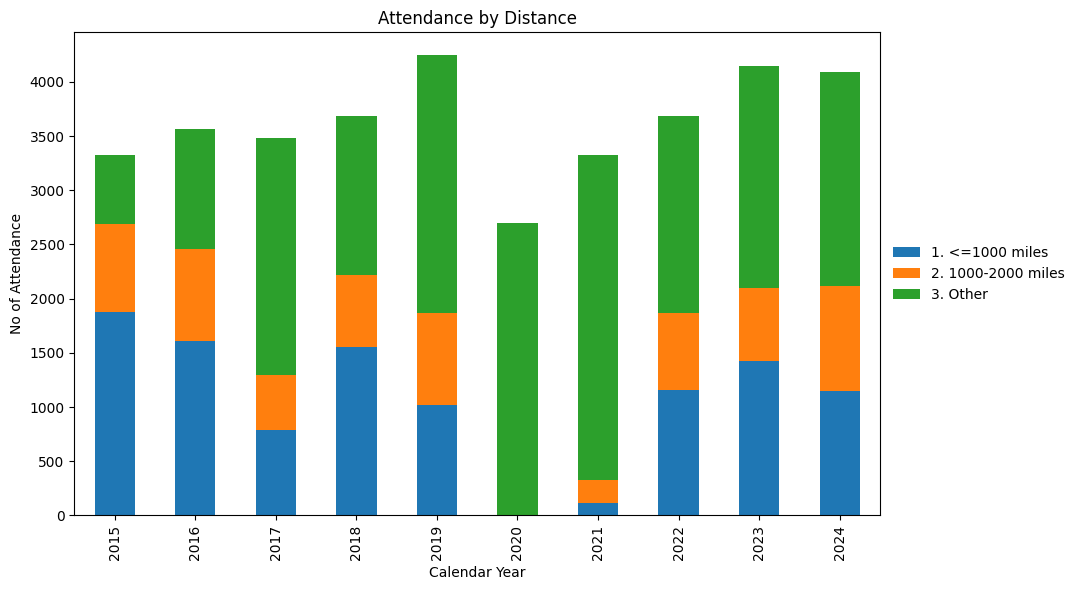

In [376]:
temp = primary_secondary.groupby(['year','Distance_group'])['Customer_ID'].nunique().unstack()

ax = temp.plot(kind='bar', stacked=True, legend=False, figsize=(9, 6))

plt.ylabel('No of Attendance')
plt.xlabel('Calendar Year')
plt.title('Attendance by Distance')
plt.tight_layout()

plt.legend(title='', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.show()

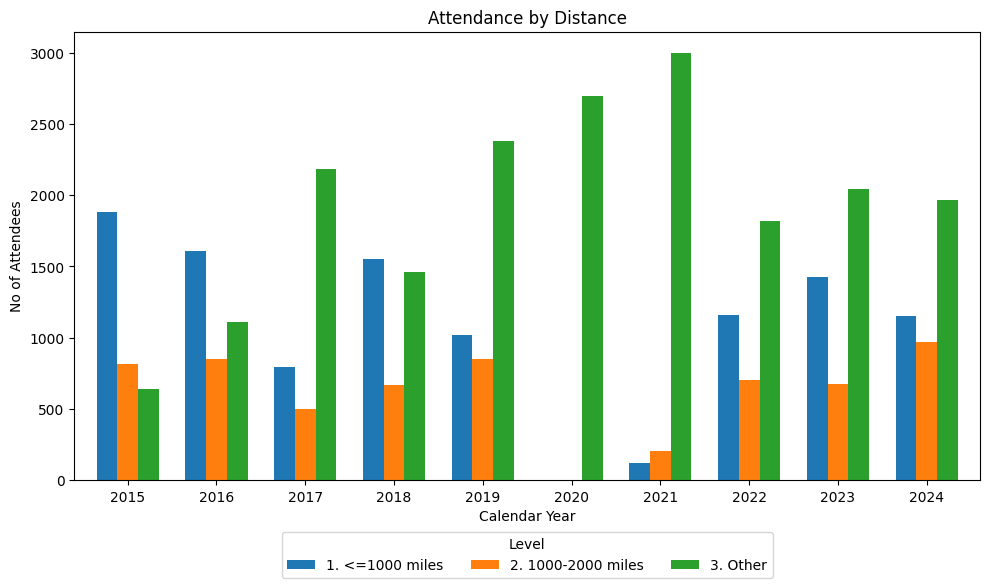

In [377]:
temp = primary_secondary.groupby(['year', 'Distance_group'])['Customer_ID'].nunique().unstack()


ax = temp.plot(kind='bar', figsize=(10, 6), width=0.7)  


plt.ylabel('No of Attendees')
plt.title('Attendance by Distance')
plt.xlabel('Calendar Year')


plt.legend(title='Level', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)


plt.xticks(rotation=0)
plt.tight_layout()


plt.show()

In [378]:
%%markdown
### Attendance by City

### Attendance by City


In [379]:
%%markdown
#### Annual Meeting

#### Annual Meeting


In [380]:
#primary_secondary.tail(2)

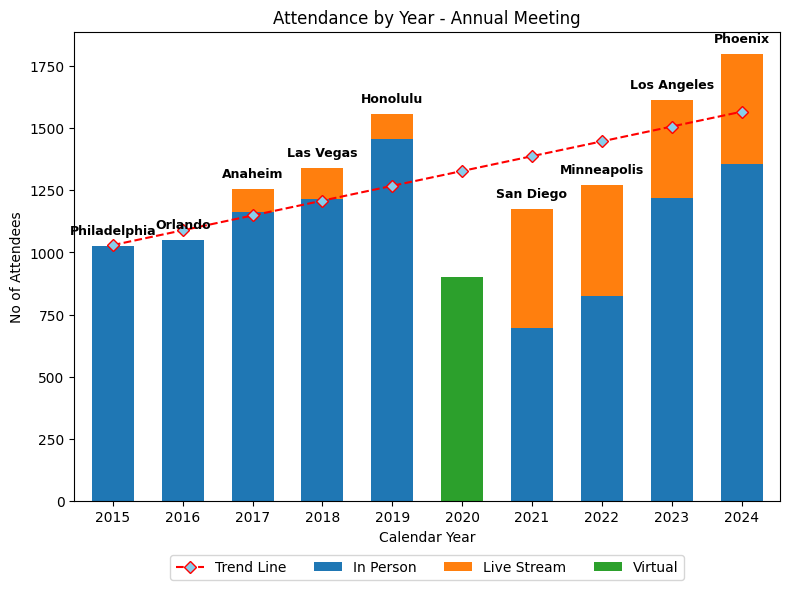

In [381]:
var = 'Annual Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Delivery_desc'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
)


years = temp.index.values
attendees = temp.sum(axis=1).values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    width=0.6
)


x_pos = np.arange(len(years))


ax.plot(
    x_pos,
    trendline(years),
    color='red',
    linestyle='--',
    marker='D',
    markerfacecolor='skyblue',
    markeredgecolor='red',
    label='Trend Line'
)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    ax.text(
        i,
        total + (0.02 * max(attendees)), 
        city_label,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by Year - Annual Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

In [382]:
%%markdown
#### Casualty Loss Reserve Seminar

#### Casualty Loss Reserve Seminar


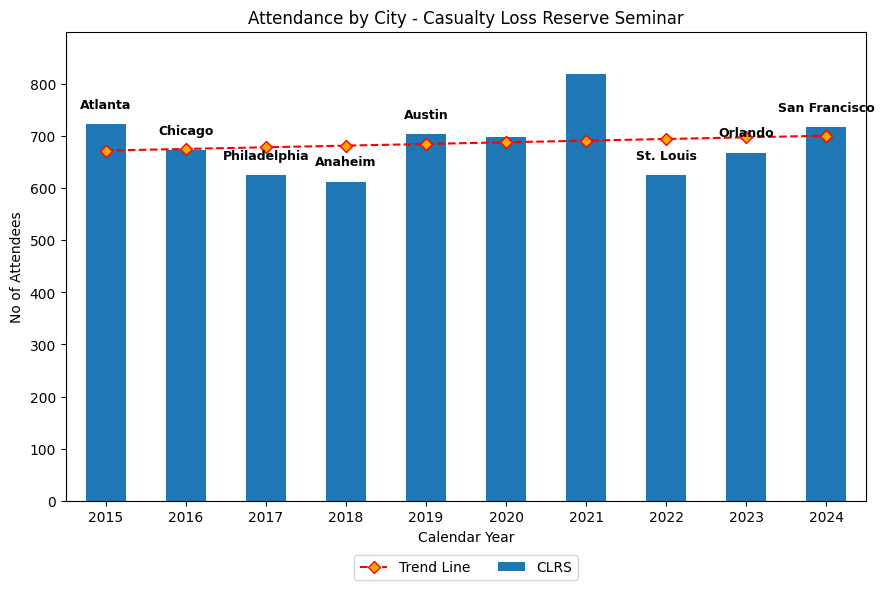

In [383]:
var = 'CLRS'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Event_desc'])['Customer_ID']
    .nunique()
    .unstack()
)


years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .first()
)


ax = temp.plot(kind='bar', figsize=(9, 6), width=0.5, legend=False)


x_pos = np.arange(len(years))


ax.plot(
    x_pos, trendline(years), 
    color='red', linestyle='--', marker='D', 
    label='Trend Line', markerfacecolor='orange', markeredgecolor='red'
)


for i, year in enumerate(years):
    ax.text(
        i, attendees[i] + 25,  
        city_per_year[year],
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='black'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


ymax = attendees.max() * 1.1
ax.set_ylim(top=ymax)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by City - Casualty Loss Reserve Seminar')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()


In [384]:
%%markdown
#### Spring Meeting

#### Spring Meeting


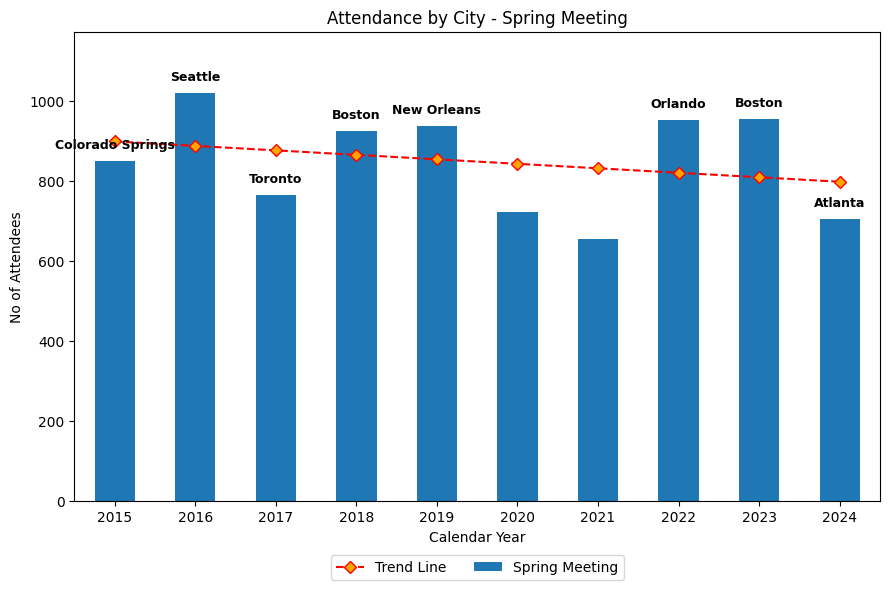

In [385]:
var = 'Spring Meeting'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Event_desc'])['Customer_ID']
    .nunique()
    .unstack()
)


years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .first()
)


ax = temp.plot(kind='bar', figsize=(9, 6), width=0.5, legend=False)


x_pos = np.arange(len(years))


ax.plot(
    x_pos, trendline(years), 
    color='red', linestyle='--', marker='D', 
    label='Trend Line', markerfacecolor='orange', markeredgecolor='red'
)


for i, year in enumerate(years):
    ax.text(
        i, attendees[i] + 25,  
        city_per_year[year],
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='black'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


ymax = attendees.max() * 1.15
ax.set_ylim(top=ymax)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by City - Spring Meeting')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [386]:
%%markdown
#### Ratemaking and Product Management

#### Ratemaking and Product Management


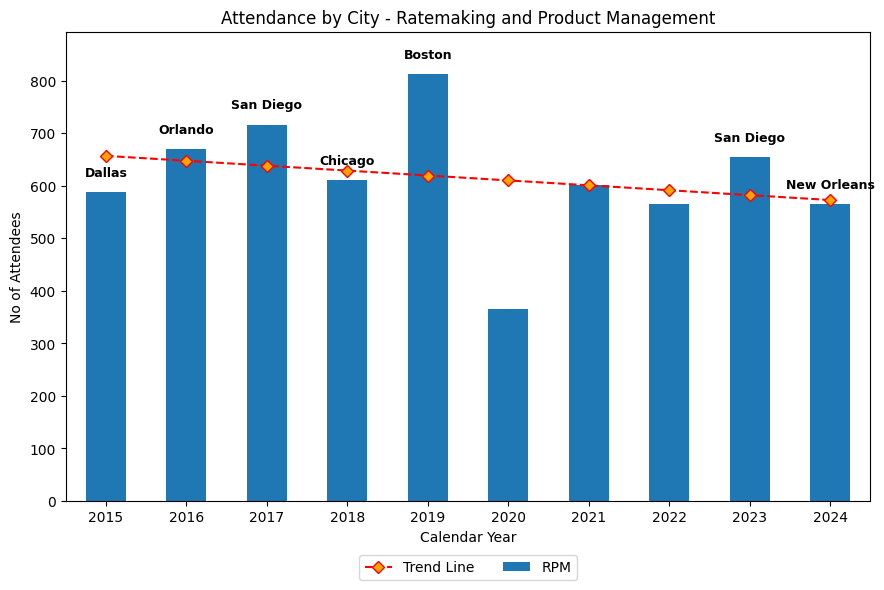

In [387]:
var = 'RPM'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Event_desc'])['Customer_ID']
    .nunique()
    .unstack()
)


years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .first()
)


ax = temp.plot(kind='bar', figsize=(9, 6), width=0.5, legend=False)


x_pos = np.arange(len(years))


ax.plot(
    x_pos, trendline(years), 
    color='red', linestyle='--', marker='D', 
    label='Trend Line', markerfacecolor='orange', markeredgecolor='red'
)


for i, year in enumerate(years):
    ax.text(
        i, attendees[i] + 25, 
        city_per_year[year],
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='black'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


ymax = attendees.max() * 1.1
ax.set_ylim(top=ymax)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by City - Ratemaking and Product Management')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [388]:
%%markdown
#### Reinsurance Seminar

#### Reinsurance Seminar


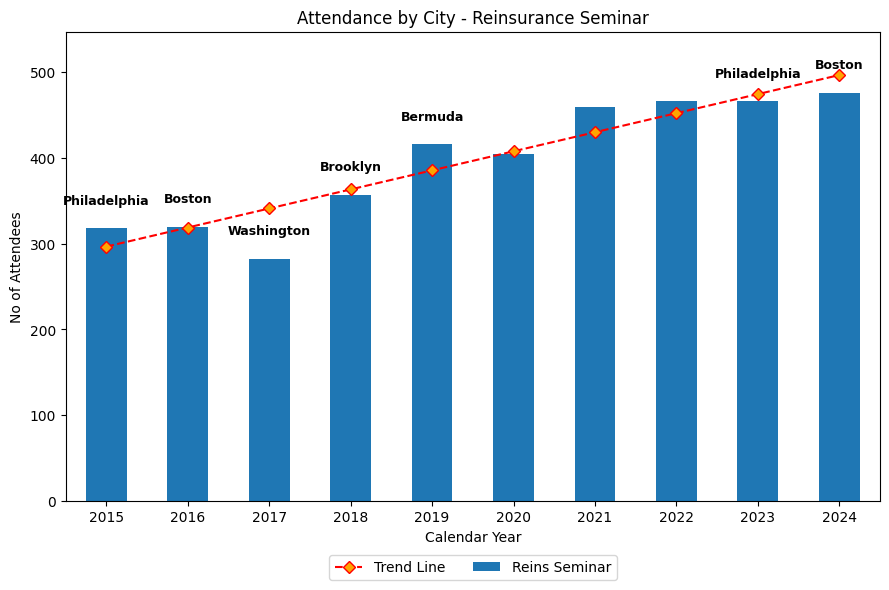

In [389]:
var = 'Reins Seminar'


temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Event_desc'])['Customer_ID']
    .nunique()
    .unstack()
)


years = temp.index.values
attendees = temp[var].values


coeffs = np.polyfit(years, attendees, 1)
trendline = np.poly1d(coeffs)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .first()
)


ax = temp.plot(kind='bar', figsize=(9, 6), width=0.5, legend=False)


x_pos = np.arange(len(years))


ax.plot(
    x_pos, trendline(years), 
    color='red', linestyle='--', marker='D', 
    label='Trend Line', markerfacecolor='orange', markeredgecolor='red'
)


for i, year in enumerate(years):
    ax.text(
        i, attendees[i] + 25,  
        city_per_year[year],
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='black'
    )


ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)


ymax = attendees.max() * 1.15
ax.set_ylim(top=ymax)


plt.ylabel('No of Attendees')
plt.xlabel('Calendar Year')
plt.title('Attendance by City - Reinsurance Seminar')


plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)


plt.tight_layout()
plt.show()

In [390]:
%%markdown
### Attendance by Registration

### Attendance by Registration


In [391]:
%%markdown
#### Annual Meeting

#### Annual Meeting


In [392]:
#primary_secondary[primary_secondary.Customer_ID=='000184067I']

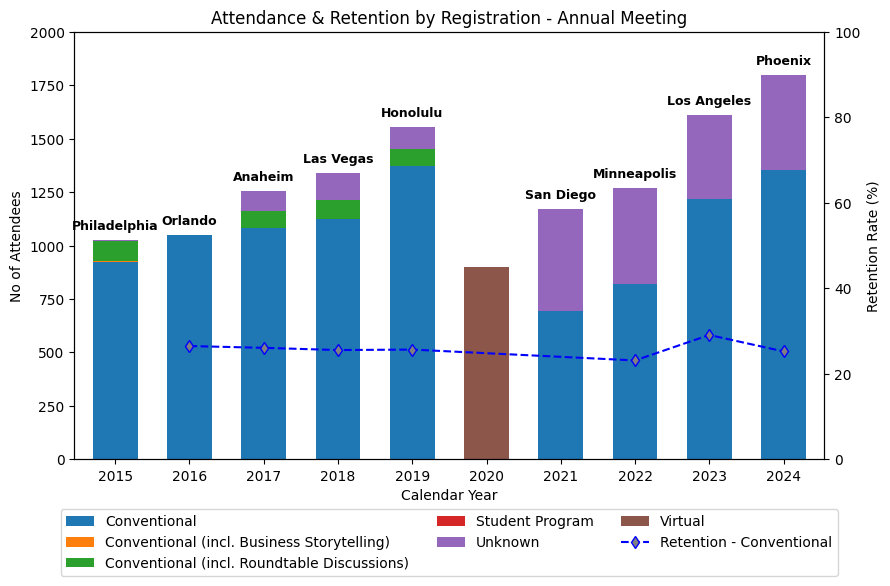

In [393]:
var = 'Annual Meeting'

temp = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Event_details'])['Customer_ID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()  
)


years = temp.index.values
attendees = temp.sum(axis=1).values


ax = temp.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    width=0.6
)
ax.legend_.remove()


x_pos = np.arange(len(years))

 
cust_by_year_delivery = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby(['year', 'Event_details'])['Customer_ID']
    .apply(set)
    .unstack()  
)


year_set = set(years)
year_prev_map = {}
for yr in years:
    if yr == years[0]:
        year_prev_map[yr] = None
    else:
        year_prev_map[yr] = yr - 1 if (yr - 1) in year_set else None


retention_rates = {}
for col in cust_by_year_delivery.columns:
    rates = []
    for yr in years:
        prev_yr = year_prev_map[yr]
        if prev_yr is None:
            rates.append(np.nan)
            continue

        cur_set = cust_by_year_delivery.loc[yr, col] if (yr in cust_by_year_delivery.index) else np.nan
        prev_set = cust_by_year_delivery.loc[prev_yr, col] if (prev_yr in cust_by_year_delivery.index) else np.nan

        if not isinstance(cur_set, set) or not isinstance(prev_set, set) or len(prev_set) == 0:
            rates.append(np.nan)
        else:
            retained = len(cur_set.intersection(prev_set)) / len(prev_set) * 100.0
            rates.append(retained)
    retention_rates[col] = rates

retention_df = pd.DataFrame(retention_rates, index=years)


retention_colors = {
    "Mid-Level": "orange",
    "Senior Level": "cyan",
    "default": "blue"
}

markerface_colors ={
    "Mid-Level": "purple",
    "Senior Level": "yellow",
    "default": "grey"
}

marker_style ={
    "Mid-Level": "o",
    "Senior Level": "s",
    "default": "d"
}

skip_registration_type = ["Conventional (incl. Roundtable Discussions)",'Unknown']   

ax2 = ax.twinx()
for col in retention_df.columns:
    if col in skip_registration_type:
        continue 
    
    y = retention_df[col].astype(float).values
    mask = np.isfinite(y)
    if mask.any():
        ax2.plot(
            x_pos[mask],
            y[mask],
            color=retention_colors.get(col, retention_colors["default"]),
            linestyle='--',
            marker=marker_style.get(col, marker_style["default"]),
            markerfacecolor=markerface_colors.get(col, markerface_colors["default"]),
            #markeredgecolor='white', 
            label=f"Retention - {col}"
        )

ax2.set_ylabel("Retention Rate (%)")
ax2.set_ylim(0, 100)


city_per_year = (
    primary_secondary[primary_secondary.Event_desc == var]
    .groupby('year')['Location_City']
    .apply(lambda x: ', '.join(str(v) for v in x.dropna().unique()))
)


for i, year in enumerate(years):
    total = attendees[i]
    city_label = city_per_year.loc[year] if year in city_per_year.index else ""
    ax.text(
        i,
        total + (0.02 * max(attendees) if len(attendees) else 0), 
        city_label,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# axis
ax.set_xticks(x_pos)
ax.set_xticklabels(years, rotation=0)
ax.set_ylabel('No of Attendees')
ax.set_xlabel('Calendar Year')
plt.title('Attendance & Retention by Registration - Annual Meeting')


ymax = 2000
ax.set_ylim(top=ymax)


lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2, labels + labels2,
    title='',
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3
)

plt.tight_layout()
plt.show()

In [394]:
print(temp)

Event_details  Conventional  Conventional (incl. Business Storytelling)  \
year                                                                      
2015                    921                                           7   
2016                   1047                                           0   
2017                   1084                                           0   
2018                   1126                                           0   
2019                   1374                                           0   
2020                      0                                           0   
2021                    692                                           0   
2022                    822                                           0   
2023                   1220                                           0   
2024                   1355                                           0   

Event_details  Conventional (incl. Roundtable Discussions)  Student Program  \
year                

In [395]:
%%markdown
### Extract Processed Data

### Extract Processed Data


In [396]:
#primary_secondary.tail(2)

In [397]:
primary_secondary.to_csv('processed_data.csv',index=False)